# Class 11: Linear Algebra and Spectral Methods for Network Science


We have already used adjacency matrices, random walks, community structure, and diffusion at several points in the course...

...dut I will give you \$5 if anyone can, off the top of your head, compute the Laplacian of a matrix


This chapter slows down and pulls those ideas into one coherent language: graph matrices as linear operators on signals attached to nodes.

1. Come in. Sit down. Open Teams.
2. Find your notebook in your /Class_11/ folder.

_____________

## How this chapter fits together

This class is an eat-your-vegetiables classs.

The main arc is built around one recurring thing: we'll put a value on each node, let a matrix act on that vector, and ask what the resulting pattern means. Throughout, it helps to keep four viewpoints in play at once:

1. a graph as a combinatorial object,
2. a matrix as a linear operator,
3. an eigenvector as a structural or dynamical mode,
4. code as a way to test whether the interpretation is actually true.

Then there's a ton of appendices, showing how the same spectral language reappears in ranking, electrical-network ideas, sparse community detection, spanning-tree counts, and geometric embeddings.

## Learning goals

By the end of the core path, you should be able to do all of the following.

- Turn a graph into adjacency, degree, random-walk, and Laplacian matrices, and explain what each one is designed to emphasize.
- Interpret matrix-vector multiplication on a graph as aggregation, propagation, or differencing of a node signal.
- Explain why symmetry is such a gift for undirected networks: real eigenvalues, orthogonal eigenvectors, and stable numerical methods.
- Use eigenvalues and eigenvectors to reason about long walks, centrality, connected components, bottlenecks, diffusion, spectral gap, and clustering.
- Compute and visualize the Fiedler vector, conductance-style sweep cuts, diffusion on a graph, and a basic spectral clustering pipeline.
- Recognize the practical issues that matter in real network work: node ordering, normalization choices, localization, disconnected graphs, solver choice, and degree effects.

The appendices add optional depth on incidence matrices, PageRank, effective resistance, non-backtracking operators, spanning trees, modularity, and related spectral ideas.

## Notation and conventions

Unless we say otherwise, we work with simple, undirected graphs $G=(V,E)$ with $n=|V|$ nodes and $m=|E|$ edges. When weights appear, we assume they are nonnegative unless noted explicitly. When direction matters, we will say so plainly rather than sneaking directed facts into the undirected story.

A few conventions stay fixed throughout the notebook.

- $A \in \mathbb{R}^{n \times n}$ is the adjacency matrix.
- $d_i = \sum_j A_{ij}$ is the degree of node $i$, and $D = \mathrm{diag}(d_1,\dots,d_n)$ is the degree matrix.
    - (I'M SORRY, THESE LINEAR ALGEBRA PEOPLE LOVE $d$ instead of $k$)
- $L = D - A$ is the combinatorial Laplacian.
- $A_{\mathrm{norm}} = D^{-1/2} A D^{-1/2}$ is the symmetric normalized adjacency.
- $L_{\mathrm{sym}} = I - D^{-1/2} A D^{-1/2}$ is the symmetric normalized Laplacian.
- $P = D^{-1} A$ is the row-stochastic random-walk matrix, so distributions evolve as $p_{t+1} = p_t P$ in our main text and code cells.
- For symmetric matrices, eigenvalues are ordered increasingly unless stated otherwise.

One practical convention: whenever we turn a graph into a matrix, we keep a fixed `nodelist`. That is the only reliable way to know which row and column correspond to which node.

One directed-graph warning is worth stating up front. If $A$ is not symmetric, then left and right eigenvectors are different objects, complex eigenvalues can appear, and "importance flowing into a node" is not the same as "importance flowing out of a node." We return to that carefully in Appendix B.

## Table of contents

1. Why linear algebra matters for networks
2. A gentle linear-algebra refresher in network language
3. Canonical graph matrices
4. Laplacian structure, smoothness, and graph Fourier intuition
5. Adjacency spectra, long walks, and centrality
6. Algebraic connectivity, Fiedler vectors, and cuts
7. Random walks, diffusion, and spectral gap
8. Spectral clustering in practice
9. Pitfalls and numerical habits
10. Summary

- Appendix A. Incidence matrices and the factorization of the Laplacian
- Appendix B. Katz centrality and PageRank as linear algebra problems
- Appendix C. Effective resistance and the Laplacian pseudoinverse
- Appendix D. The non-backtracking matrix and sparse graph structure
- Appendix E. Kirchhoff's matrix-tree theorem and spanning trees
- Appendix F. Spectral embeddings, diffusion maps, and where this goes next
- Appendix G. Modularity as another spectral route to communities
- Appendix H. Why normalized cuts lead to a generalized eigenproblem
- References

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import sklearn

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from IPython.display import display

rng = np.random.default_rng(5052)
np.set_printoptions(precision=4, suppress=True)

We only define two structural helpers immediately: a stable node ordering and a dense adjacency conversion. A second tiny helper cell only handles display so later matrices and graph drawings stay readable.

The linear-algebra helpers that matter for the mathematics will be built locally, right before the section that uses them. That keeps the notebook closer to the way one would actually develop the material live in class.

In [3]:
def stable_nodelist(G, nodelist=None):
    """Return a reproducible node ordering."""
    if nodelist is not None:
        return list(nodelist)
    try:
        return sorted(G.nodes())
    except TypeError:
        return list(G.nodes())

def adjacency_dense(G, nodelist=None, weight=None, dtype=float):
    """Dense adjacency matrix with a fixed node ordering."""
    nodes = stable_nodelist(G, nodelist)
    A = nx.to_numpy_array(G, nodelist=nodes, weight=weight, dtype=dtype)
    return A, nodes

A_two, nodes_two = adjacency_dense(nx.path_graph(2))

The next helpers are only for display. They keep the matrices and graph drawings compact and readable, but they are not part of the mathematical story.

In [14]:
def show_matrix_df(A, name=None, index=None, columns=None, digits=3):
    """Display a small matrix as a labeled pandas DataFrame."""
    Ad = A.toarray() if sp.issparse(A) else np.asarray(A)
    m, n = Ad.shape
    if index is None:
        index = list(range(m))
    if columns is None:
        columns = list(range(n))
    df = pd.DataFrame(np.round(Ad, digits), index=index, columns=columns)
    if name:
        print(name)
    display(df)

def plot_matrix_heatmap(A, ax, title="", ticklabels=None, annotate=False):
    """Heatmap for a small matrix with optional entry annotations."""
    Ad = A.toarray() if sp.issparse(A) else np.asarray(A)
    im = ax.imshow(Ad, aspect="equal")
    ax.set_title(title)
    ax.set_xlabel("column index")
    ax.set_ylabel("row index")
    if ticklabels is not None:
        ax.set_xticks(np.arange(len(ticklabels)))
        ax.set_yticks(np.arange(len(ticklabels)))
        ax.set_xticklabels(ticklabels)
        ax.set_yticklabels(ticklabels)
    if annotate and Ad.shape[0] <= 8 and Ad.shape[1] <= 8:
        for i in range(Ad.shape[0]):
            for j in range(Ad.shape[1]):
                ax.text(j, i, f"{Ad[i, j]:.0f}", ha="center", va="center")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def draw_graph(G, ax, pos=None, values=None, title="", with_labels=True, node_size=250, cmap="viridis"):
    """Draw a graph, optionally colored by a node signal."""
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
#         pos = nx.spring_layout(G, seed=5052)

    if values is None:
        nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size,
                                       node_color='.9', edgecolors='.1')
    else:
        values = np.asarray(values)
        nodes = nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_color=values,
            cmap=cmap,
            node_size=node_size,
        )
        ax.figure.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.6)
    if with_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)

    ax.set_title(title)
    ax.set_axis_off()
    return pos

## 1. Why linear algebra matters for networks

Before we run down eigenvector rabbit holes, we need to get comfortable with the basic move that makes spectral network science possible: a graph becomes a matrix once we choose an ordering of the nodes.

Often times, super simple operations are possible on matrices that aren't immediately obvious over graphs. They lets us replace phrases like "sum over neighbors," "compare the endpoints of an edge," or "follow one step of a walk" by precise linear-algebra operations. Once that translation is in place, familiar graph questions can be asked in a new language.

We will reuse a small collection of toy graphs over and over: a path, a cycle, a star, a clique, and a disconnected graph. They are not meant to be realistic. They are meant to be inspectable. Spectral phenomena are much easier to trust after we have first seen them on graphs small enough to understand by eye and, when needed, by hand.

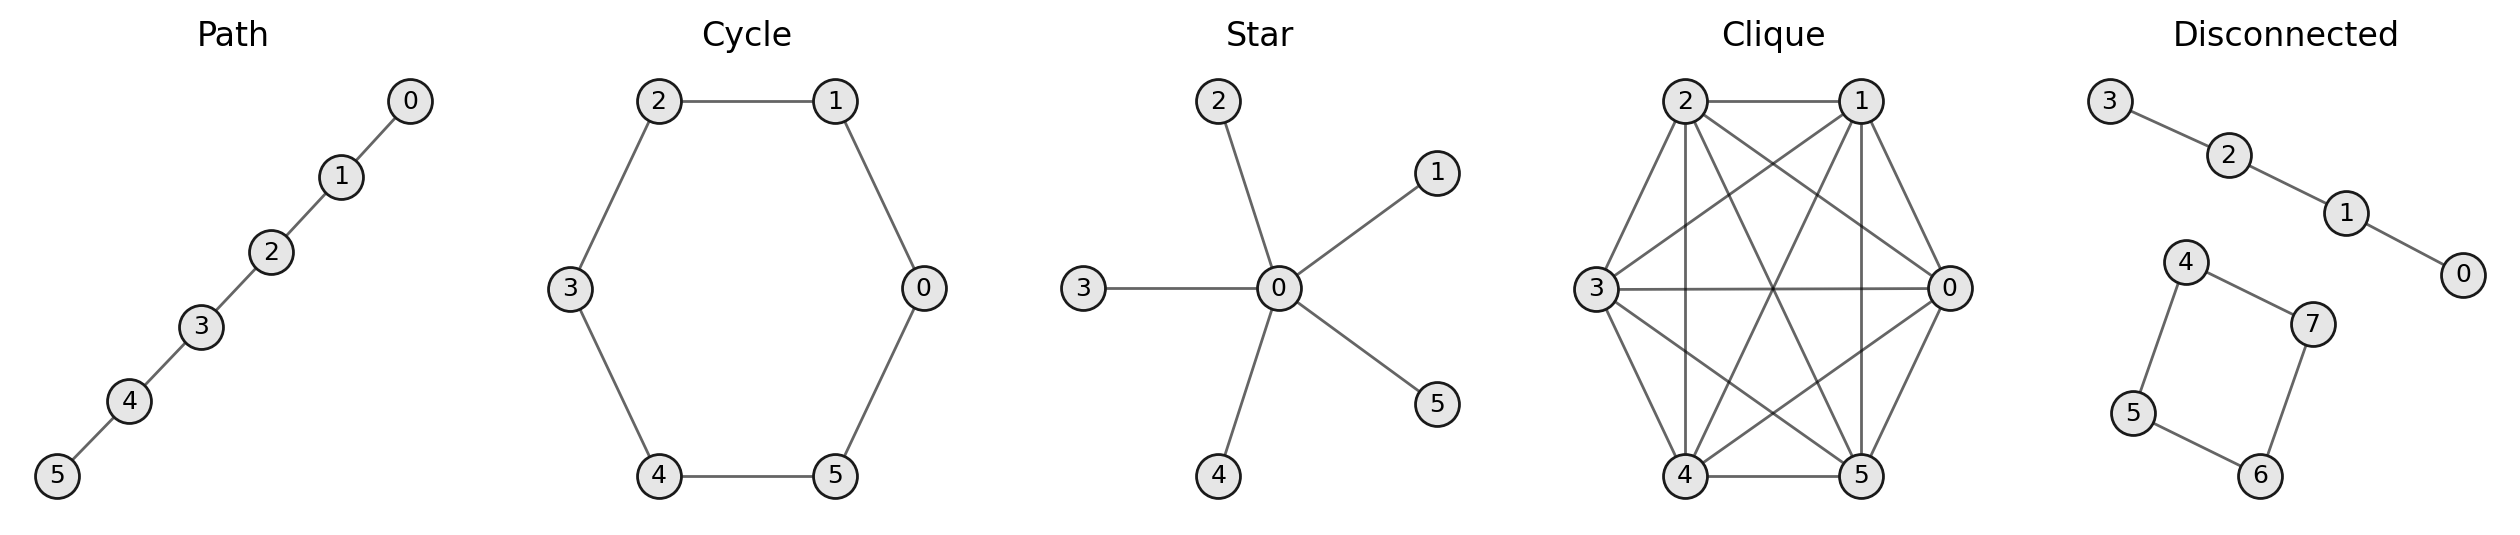

In [16]:
G_path6 = nx.path_graph(6)
G_cycle6 = nx.cycle_graph(6)
G_star6 = nx.star_graph(5)          # node 0 is the hub
G_clique6 = nx.complete_graph(6)
G_disc = nx.disjoint_union(nx.path_graph(4), nx.cycle_graph(4))

fig, axes = plt.subplots(1, 5, figsize=(16, 3), dpi=200)

draw_graph(G_path6, axes[0], title="Path")
draw_graph(G_cycle6, axes[1], title="Cycle")
draw_graph(G_star6, axes[2], title="Star")
draw_graph(G_clique6, axes[3], title="Clique")
draw_graph(G_disc, axes[4], title="Disconnected")

plt.show()

### 1.1 The adjacency matrix (I know, I know......)

For an unweighted graph with nodes ordered as $1,\dots,n$, the adjacency matrix $A \in \mathbb{R}^{n \times n}$ is defined by

$$
A_{ij} =
\begin{cases}
1 & \text{if nodes } i \text{ and } j \text{ are adjacent}, \\
0 & \text{otherwise.}
\end{cases}
$$

Here $A_{ij}$ means the entry in row $i$, column $j$. In an undirected graph, $A$ is symmetric because adjacency has no direction. In a weighted graph, the entry is the edge weight instead of just $0$ or $1$.

Some notes: 

First, the graph is not the matrix. The graph is the abstract combinatorial object; the matrix is one coordinate representation of it, tied to a particular node ordering.

Second, once the matrix exists, linear algebra becomes meaningful. We can multiply by vectors, square the matrix, compute eigenvalues, and ask what those operations mean in network language.

For directed graphs, we will use the convention that $A_{ij}=1$ when there is an edge $i \to j$. That looks innocent, but it changes the algebra: left and right multiplication no longer mean the same thing, and left and right eigenvectors split apart. We will keep the core path undirected first so that those issues stay visible instead of hidden.

Adjacency matrix of the 6-node path


,0,1,2,3,4,5
0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,1.0
5,0.0,0.0,0.0,0.0,1.0,0.0


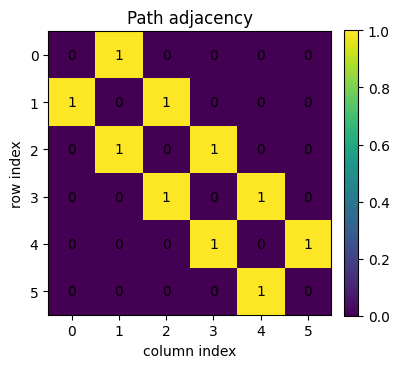

In [23]:
A_path6, nodes_path6 = adjacency_dense(G_path6)
show_matrix_df(A_path6, name="Adjacency matrix of the 6-node path", index=nodes_path6, columns=nodes_path6)

fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=100)
plot_matrix_heatmap(A_path6, ax, title="Path adjacency",
                    ticklabels=nodes_path6, annotate=True)
plt.show()

Adjacency matrix of the 6-node star


,0,1,2,3,4,5
0,0.0,1.0,1.0,1.0,1.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0


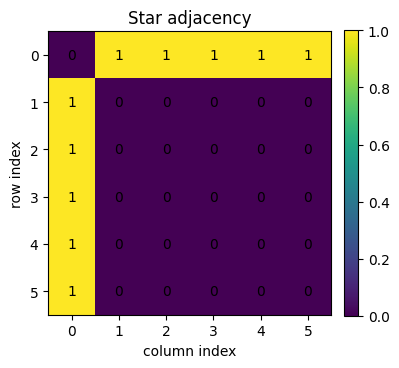

In [24]:
A_star6, nodes_star6 = adjacency_dense(G_star6)
show_matrix_df(A_star6, name="Adjacency matrix of the 6-node star", index=nodes_star6, columns=nodes_star6)

fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=100)
plot_matrix_heatmap(A_star6, ax, title="Star adjacency",
                    ticklabels=nodes_star6, annotate=True)
plt.show()

### 1.2 Node ordering and permutation matrices

Suppose the same graph is stored with a different node order. The picture of the graph has not changed, but the matrix coordinates have.

If $A$ is the adjacency matrix in one ordering and $A'$ is the adjacency matrix after a reordering, then

$$
A' = P A P^\top,
$$

where $P$ is a permutation matrix. The symbols mean the following.

- $P$ is a square matrix with exactly one $1$ in each row and column and zeros elsewhere.
- $P^\top$ is its transpose.
- The product $P A P^\top$ reindexes rows and columns consistently.

Why do we care? Because it tells us which features are structural and which are just artifacts of indexing. Eigenvalues are unchanged by this similarity transformation. Walk counts are unchanged. Only the coordinate labels move.


In [25]:
G_perm = G_path6
A_old, old_nodes = adjacency_dense(G_perm)

new_nodes = [3, 2, 1, 0, 4, 5]
A_new, _ = adjacency_dense(G_perm, nodelist=new_nodes)

In [29]:
old_index = {u: i for i, u in enumerate(old_nodes)}
P = np.zeros_like(A_old)
for i_new, u in enumerate(new_nodes):
    P[i_new, old_index[u]] = 1.0

In [30]:
A_from_perm = P @ A_old @ P.T

In [27]:
evals_old = np.linalg.eigvalsh(A_old)
evals_new = np.linalg.eigvalsh(A_new)

In [28]:
print("Old node order:", old_nodes)
print("New node order:", new_nodes)
print("Permutation check:", np.allclose(A_new, A_from_perm))
print("Eigenvalues unchanged:", np.allclose(np.sort(evals_old), np.sort(evals_new)))

show_matrix_df(P, name="Permutation matrix P", index=new_nodes, columns=old_nodes)

Old node order: [0, 1, 2, 3, 4, 5]
New node order: [3, 2, 1, 0, 4, 5]
Permutation check: True
Eigenvalues unchanged: True
Permutation matrix P


,0,1,2,3,4,5
3,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.0


A useful way to read $A' = P A P^\top$ is row by row and column by column. Left multiplication by $P$ relabels the receiving-node axis, and right multiplication by $P^\top$ relabels the sending-node axis by the same permutation.

We need both operations. If we permuted only rows or only columns, the array would no longer describe the same graph in a consistent coordinate system. The picture below is intentionally redundant with the algebra: the graph has not changed, but the matrix pattern moves because the labels moved.

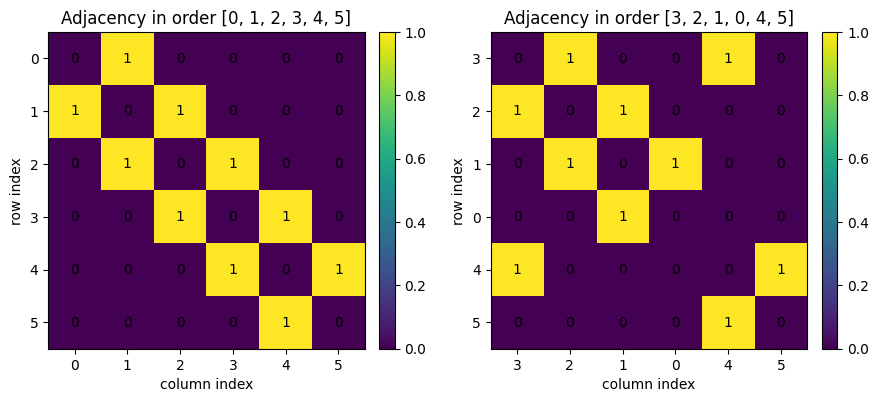

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=100)

plot_matrix_heatmap(
    A_old,
    axes[0],
    title=f"Adjacency in order {old_nodes}",
    ticklabels=old_nodes,
    annotate=True,
)
plot_matrix_heatmap(
    A_new,
    axes[1],
    title=f"Adjacency in order {new_nodes}",
    ticklabels=new_nodes,
    annotate=True,
)

plt.tight_layout()
plt.show()

___________

### Interlude: wtf even is eigenvalues and eigenvectors?

Before we use $Ax$ heavily on graphs, it helps to know why some vectors are more important than others.

![](images/hp.gif)

A matrix $M$ takes an input vector $x$ and returns a new vector $Mx$. For a generic input, the output changes both size and direction. An eigenvector is a nonzero vector $v$ for which the matrix acts in the simplest possible way:
$$
Mv = \lambda v.
$$


This says that the output stays on the same line through the origin. The matrix is allowed to stretch, shrink, flip, or even collapse the vector, but it does not send that direction to a genuinely new direction.

The scalar $\lambda$ tells us what kind of action occurred.

- If $\lambda > 1$, the vector is stretched.
- If $0 < \lambda < 1$, the vector is shrunk.
- If $\lambda < 0$, the direction is flipped as well as rescaled.
- If $\lambda = 0$, the vector is sent to the zero vector.
- If $\lambda = 1$, the vector is unchanged exactly.

For networks, this becomes especially useful because a vector is just a node signal: one number on each node. An eigenvector of a graph matrix is therefore a signal pattern whose overall shape is preserved when the matrix acts on it.

The next section will make $Ax$ concrete as neighborhood aggregation. Once that picture is in place, the eigenvector equation will read as: after one round of aggregation, this signal keeps the same shape and only changes by a factor of $\lambda$.

In [65]:
def unit(u):
    """Return a unit vector in the direction of u."""
    u = np.asarray(u, dtype=float)
    return u / np.linalg.norm(u)

def cosine_similarity(a, b):
    """Cosine of the angle between two nonzero vectors."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        raise ValueError("cosine similarity is undefined for the zero vector")
    return float((a @ b) / denom)

M_eig_demo = np.array([[2.0, 1.0],
                       [1.0, 2.0]], dtype=float)

candidate_vectors = {
    "generic direction": np.array([1.0, 0.35]),
    "same-sign direction $(1,1)$": np.array([1.0, 1.0]),
    "opposite-sign direction $(1,-1)$": np.array([1.0, -1.0]),
}

In [71]:
rows = []
for name, raw in candidate_vectors.items():
    u = unit(raw)
    Mu = M_eig_demo @ u
    cos = cosine_similarity(u, Mu)
    rows.append({
        r"candidate": name,
        r"input $u$": np.round(u, 3).tolist(),
        r"output $Mu$": np.round(Mu, 3).tolist(),
        r"cosine $(u, Mu)$": np.round(cos, 3),
        r"same line?": np.isclose(abs(cos), 1.0, atol=1e-10),
    })

display(pd.DataFrame(rows).set_index("candidate"))

,input $u$,output $Mu$,"cosine $(u, Mu)$",same line?
candidate,,,,
generic direction,"[0.944, 0.33]","[2.218, 1.605]",0.958,False
"same-sign direction $(1,1)$","[0.707, 0.707]","[2.121, 2.121]",1.000,True
"opposite-sign direction $(1,-1)$","[0.707, -0.707]","[0.707, -0.707]",1.000,True


In [72]:
evals_demo, evecs_demo = np.linalg.eigh(M_eig_demo)
print("eigenvalues of M =", np.round(evals_demo, 6))
display(pd.DataFrame(
    np.round(evecs_demo, 3),
    index=["entry 0", "entry 1"],
    columns=[r"eigenvector for $\lambda_{\min}$", r"eigenvector for $\lambda_{\max}$"],
))

eigenvalues of M = [1. 3.]


,eigenvector for $\lambda_{\min}$,eigenvector for $\lambda_{\max}$
entry 0,-0.707,0.707
entry 1,0.707,0.707


### 1.3 Matrix-vector multiplication is neighborhood aggregation

Now attach a number $x_i$ to each node $i$. The full node signal is the vector

$$
x =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
\in \mathbb{R}^n.
$$

You can read $x_i$ as whatever node-level quantity the problem cares about: a temperature, an opinion, a population, a score, or simply a toy label.

When we multiply by the adjacency matrix, we get another node signal $y = Ax$ whose $i$th entry is

$$
y_i = \sum_{j=1}^n A_{ij} x_j.
$$

Every symbol now has a meaning.

- $x_j$ is the value carried by node $j$.
- $A_{ij}$ decides whether node $j$ contributes to node $i$.
- $y_i$ is the new value at node $i$ after summing contributions from its neighbors.

For an unweighted undirected graph, that formula collapses to "add up the values on my neighbors." This is the linear-algebra version of neighborhood aggregation, message passing, or one-step propagation.

In the code cell below, the mapping from symbols to variables is explicit:

- $A$ corresponds to `A_path`
- $x$ corresponds to `x`
- $y = Ax$ corresponds to `y`

In [34]:
A_path, nodes_path = adjacency_dense(G_path6)
x = np.array([3, 1, 0, 2, 1, 4], dtype=float)
y = A_path @ x

manual = np.array([
    x[1],
    x[0] + x[2],
    x[1] + x[3],
    x[2] + x[4],
    x[3] + x[5],
    x[4],
], dtype=float)

In [35]:
df = pd.DataFrame({"x": x, "y = A x": y, "manual neighbor sum": manual}, index=nodes_path)
display(df)


,x,y = A x,manual neighbor sum
0,3.0,1.0,1.0
1,1.0,3.0,3.0
2,0.0,3.0,3.0
3,2.0,1.0,1.0
4,1.0,6.0,6.0
5,4.0,1.0,1.0


The table is precise, but a picture helps. On the left we color each node by the input signal $x$. On the right we color by $y = A x$ after one round of neighbor aggregation.

Endpoints on a path only listen to one neighbor, while interior nodes listen to two. That is why adjacency multiplication is a local averaging-or-summing mechanism rather than a property of each node in isolation.

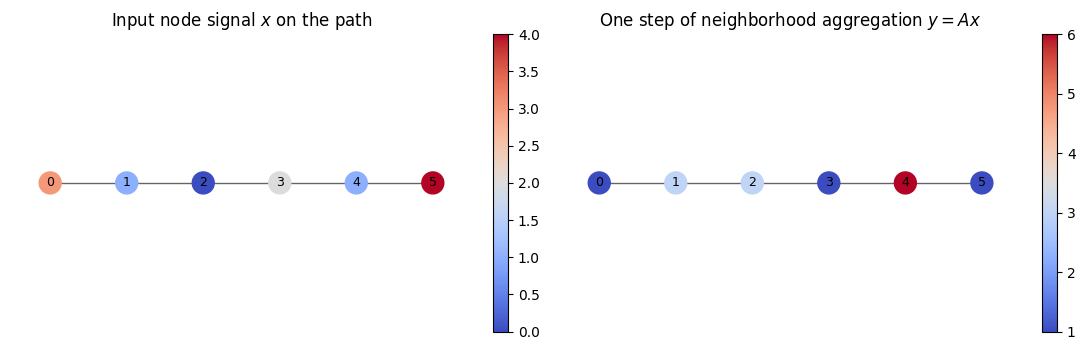

In [36]:
pos_path_line = {u: (u, 0.0) for u in nodes_path}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), dpi=100)

draw_graph(
    G_path6,
    axes[0],
    pos=pos_path_line,
    values=x,
    title="Input node signal $x$ on the path",
    with_labels=True,
    cmap="coolwarm",
)
draw_graph(
    G_path6,
    axes[1],
    pos=pos_path_line,
    values=y,
    title="One step of neighborhood aggregation $y = A x$",
    with_labels=True,
    cmap="coolwarm",
)

plt.tight_layout()
plt.show()

_______

### 1.4 Degree matrix and Laplacian

The degree of node $i$ is

$$
d_i = \sum_{j=1}^n A_{ij}.
$$

The diagonal degree matrix is

$$
D = \mathrm{diag}(d_1,\dots,d_n).
$$


Because $D$ is diagonal, multiplying by it is simple: $(Dx)_i = d_i x_i$. The degree matrix rescales each node value by the node's degree.

The combinatorial Laplacian is then defined by

$$
L = D - A.
$$


So when $L$ acts on a node signal $x$, the $i$th entry becomes

$$
(Lx)_i = d_i x_i - \sum_{j=1}^n A_{ij} x_j.
$$

A second algebraic form is worth memorizing:

$$
(Lx)_i = \sum_{j=1}^n A_{ij}(x_i - x_j).
$$

This version is the local intuition in one line. Each neighbor contributes a difference term. If node $i$ agrees with its neighbors, those terms are small and the Laplacian response is small. If node $i$ is out of sync with its neighborhood, the response is large. That is why the Laplacian is the natural matrix for smoothness, diffusion, consensus, and cut-based questions.

Before we can talk about degrees, Laplacians, and walk counts, we need a few tiny algebra helpers for diagonal matrices and degree bookkeeping.

In [37]:
def diag_sparse(x):
    """Sparse diagonal matrix from a 1D array."""
    return sp.diags(np.asarray(x, dtype=float), offsets=0, format="csr")

def degree_vector_from_adjacency(A):
    """Degree vector from a dense or sparse adjacency matrix."""
    return np.asarray(A.sum(axis=1)).ravel()

def degree_matrix_from_adjacency(A):
    """Degree matrix D from an adjacency matrix A."""
    d = degree_vector_from_adjacency(A)
    if sp.issparse(A):
        return diag_sparse(d)
    return np.diag(d)

def laplacian_from_adjacency(A):
    """Combinatorial Laplacian L = D - A."""
    D = degree_matrix_from_adjacency(A)
    return D - A

def count_walks_by_enumeration(G, start, length):
    """Brute-force walk counting for tiny graphs."""
    counts = {start: 1}
    for _ in range(length):
        new_counts = {u: 0 for u in G.nodes()}
        for u, c in counts.items():
            for v in G.neighbors(u):
                new_counts[v] += c
        counts = new_counts
    return counts

A_check = np.array([[0.0, 1.0], [1.0, 0.0]])

In [38]:
A_small, nodes_small = adjacency_dense(G_path6)
d_small = degree_vector_from_adjacency(A_small)
D_small = degree_matrix_from_adjacency(A_small)
L_small = laplacian_from_adjacency(A_small)

ones = np.ones(len(nodes_small))

In [42]:
show_matrix_df(D_small, name="Degree matrix D", index=nodes_small, columns=nodes_small)

Degree matrix D


,0,1,2,3,4,5
0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,2.0,0.0,0.0,0.0,0.0
2,0.0,0.0,2.0,0.0,0.0,0.0
3,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,2.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.0


In [43]:
show_matrix_df(L_small, name="Laplacian L = D - A", index=nodes_small, columns=nodes_small)


Laplacian L = D - A


,0,1,2,3,4,5
0,1.0,-1.0,0.0,0.0,0.0,0.0
1,-1.0,2.0,-1.0,0.0,0.0,0.0
2,0.0,-1.0,2.0,-1.0,0.0,0.0
3,0.0,0.0,-1.0,2.0,-1.0,0.0
4,0.0,0.0,0.0,-1.0,2.0,-1.0
5,0.0,0.0,0.0,0.0,-1.0,1.0


In [44]:
x = np.array([3, 1, 0, 2, 1, 4], dtype=float)
Lx = L_small @ x
manual_Lx = d_small * x - (A_small @ x)

In [45]:
display(pd.DataFrame({"x": x, "Lx": Lx, "d_i x_i - sum_j A_ij x_j": manual_Lx}, index=nodes_small))

,x,Lx,d_i x_i - sum_j A_ij x_j
0,3.0,2.0,2.0
1,1.0,-1.0,-1.0
2,0.0,-3.0,-3.0
3,2.0,3.0,3.0
4,1.0,-4.0,-4.0
5,4.0,3.0,3.0


### Wait... what even is the laplacian?

The adjacency matrix tells us which nodes are connected. The Laplacian tells us how a node compares with its neighborhood. $A$ is a propagation operator: multiplying by $A$ collects information from neighbors. $L = D - A$ is a discrepancy operator: multiplying by $L$ compares each node's value to the values next door. In network science, that is why adjacency matrices are natural for walks and centrality, while Laplacians are natural for diffusion, smoothing, synchronization, cuts, and community structure.

Entry by entry, the combinatorial Laplacian has a very simple form:

$$
L_{ii} = d_i,\qquad
L_{ij} =
\begin{cases}
-1, & \text{if } i \neq j \text{ and } i \sim j,\\
0, & \text{otherwise.}
\end{cases}
$$

for an unweighted graph. The diagonal records how many neighbors a node has, and the off-diagonal entries subtract the influence of those neighbors. One immediate consequence is that every row sums to zero, so

$$
L\mathbf{1} = \mathbf{0}.
$$

A constant signal has no local variation, and the Laplacian correctly reports that nothing is changing across edges.

The formula

$$
(Lx)_i = \sum_{j=1}^n A_{ij}(x_i - x_j)
$$

is the most useful local interpretation to keep in mind. If $x_i$ is a temperature, then $(Lx)_i$ measures how different node $i$'s temperature is from the temperatures around it. If $x_i$ is an opinion, it measures local disagreement. If $x_i$ is a traffic load or concentration, it measures local imbalance. So the Laplacian is not mainly about the value at a node in isolation; it is about contrast across edges.

A tiny path-graph example makes this concrete. For the path $1 - 2 - 3$,

$$
L =
\begin{bmatrix}
1 & -1 & 0\\
-1 & 2 & -1\\
0 & -1 & 1
\end{bmatrix}.
$$

If we take the signal

$$
x =
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix},
$$

then

$$
Lx =
\begin{bmatrix}
-1\\
2\\
-1
\end{bmatrix}.
$$

The middle node gets a large positive response because it is high relative to both neighbors. The endpoints get negative responses because they are low relative to the center. So $Lx$ is telling us where the signal bends or changes sharply across the network.

This is why the Laplacian shows up in dynamics. In the differential equation

$$
\dot{x} = -Lx,
$$

the minus sign makes nodes move toward agreement with their neighbors. Large local differences get pushed down over time, while locally smooth patterns change slowly. Because $L\mathbf{1} = \mathbf{0}$, the constant mode is preserved: once every node agrees, diffusion stops. Later in the notebook, this same operator viewpoint will explain why small Laplacian eigenvalues correspond to broad, slowly varying structures on the graph.

There is one more identity worth remembering because it compresses the whole story into a single scalar:

$$
x^\top L x = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2.
$$

The right-hand side is a sum of squared edge differences. It is small when adjacent nodes have similar values and large when many neighboring pairs disagree. That is why the Laplacian is often described as a smoothness operator or roughness penalty on graphs.

### ...why does any of this even work?

The reason the Laplacian keeps appearing is that it is essentially the simplest linear operator on a graph that satisfies four very natural requirements. First, it should be **local**: node $i$ should only interact with its neighbors. Second, it should be **difference-based**: if a node has exactly the same value as all of its neighbors, nothing should happen. Third, it should be **conservative**: whatever flows out of one node should flow into another, so the total amount of mass, heat, probability, or opinion is preserved. Fourth, it should be **smoothing**: large edge-by-edge disagreements should get pushed downward over time rather than amplified.

If we write the most basic update rule with those properties, then node $i$ changes according to

$$
\dot{x}_i = \sum_{j=1}^n A_{ij}(x_j - x_i).
$$

This says that each neighbor $j$ pulls node $i$ toward its own value. Rearranging gives

$$
\dot{x}_i = -\sum_{j=1}^n A_{ij}(x_i - x_j) = -(Lx)_i,
$$

so in vector form,

$$
\dot{x} = -Lx.
$$


That is the key point: $L = D - A$ is not an arbitrary algebraic trick. It is what drops out when we translate the everyday idea that things flow along edges from local imbalance toward local agreement into linear algebra.

There is an equally important energy view:

$$
x^\top L x = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2.
$$

This quantity is the total edgewise disagreement in the signal $x$. It is small when neighboring nodes have similar values and large when the signal changes sharply across edges. So whenever we care about diffusion, consensus, smoothing, cuts, or slowly varying modes on a graph, the Laplacian appears because those problems are all, underneath, problems about edgewise differences.

### 1.5 Matrix powers count walks

One of the most useful identities in spectral graph theory is

$$
(A^\ell)_{ij} = \text{number of walks of length } \ell \text{ from node } i \text{ to node } j
$$

for an unweighted graph.

Here:

- $\ell$ is a positive integer,
- $A^\ell$ means multiply $A$ by itself $\ell$ times,
- $(A^\ell)_{ij}$ is the entry in row $i$, column $j$ of that product.


This identity is worth pausing on because it is the first clean bridge between combinatorics and linear algebra. A power of a matrix is not just a formal algebraic object; it is literally counting allowable step-by-step motions on the graph.

Two special cases are especially useful.

- Off-diagonal entries tell us how many length-$\ell$ walks connect two different nodes.
- Diagonal entries tell us how many length-$\ell$ closed walks start and end at the same node.

For weighted graphs, the same multiplication no longer counts plain walks; it accumulates weighted walk contributions instead. The combinatorial picture changes slightly, but the operator viewpoint stays the same.

In [47]:
A_path, nodes_path = adjacency_dense(G_path6, dtype=int)
A2 = np.linalg.matrix_power(A_path, 2)
show_matrix_df(A2, name="A^2 for the path graph", index=nodes_path, columns=nodes_path)

A^2 for the path graph


,0,1,2,3,4,5
0,1,0,1,0,0,0
1,0,2,0,1,0,0
2,1,0,2,0,1,0
3,0,1,0,2,0,1
4,0,0,1,0,2,0
5,0,0,0,1,0,1


In [48]:
A3 = np.linalg.matrix_power(A_path, 3)
show_matrix_df(A3, name="A^3 for the path graph", index=nodes_path, columns=nodes_path)

A^3 for the path graph


,0,1,2,3,4,5
0,0,2,0,1,0,0
1,2,0,3,0,1,0
2,0,3,0,3,0,1
3,1,0,3,0,3,0
4,0,1,0,3,0,2
5,0,0,1,0,2,0


In [49]:
i, j, ell = 0, 3, 3
counts = count_walks_by_enumeration(G_path6, start=i, length=ell)
print(f"(A^{ell})[{i}, {j}] =", A3[i, j])
print("Brute-force count of length-3 walks from node 0:", counts)
print("Count to node 3 from brute force:", counts[j])

(A^3)[0, 3] = 1
Brute-force count of length-3 walks from node 0: {0: 0, 1: 2, 2: 0, 3: 1, 4: 0, 5: 0}
Count to node 3 from brute force: 1


### Your turn!

On the same path graph, compute $A^4$ and interpret one entry in words. Pick indices $i$ and $j$, and explain what $(A^4)_{ij}$ is counting before you run the solution.

A good choice is to look at one diagonal entry and one off-diagonal entry. The diagonal entry counts closed walks of length four that start and end at the same node.


_________________________

In [50]:
A4 = np.linalg.matrix_power(A_path, 4)
show_matrix_df(A4, name="A^4 for the path graph", index=nodes_path, columns=nodes_path)

i, j = 2, 2
counts_len4 = count_walks_by_enumeration(G_path6, start=i, length=4)

print(f"(A^4)[{i}, {j}] =", A4[i, j])
print("Brute-force count to every endpoint after 4 steps from node 2:", counts_len4)
print(f"Interpretation: there are {A4[i, j]} length-4 closed walks that start and end at node {i}.")

A^4 for the path graph


,0,1,2,3,4,5
0,2,0,3,0,1,0
1,0,5,0,4,0,1
2,3,0,6,0,4,0
3,0,4,0,6,0,3
4,1,0,4,0,5,0
5,0,1,0,3,0,2


(A^4)[2, 2] = 6
Brute-force count to every endpoint after 4 steps from node 2: {0: 3, 1: 0, 2: 6, 3: 0, 4: 4, 5: 0}
Interpretation: there are 6 length-4 closed walks that start and end at node 2.


## 2. A gentle linear-algebra refresher in network language

If linear algebra has ever felt like a bag of disconnected facts (ior if you, like some... never technically "learned" this...), this is the place to reconnect the essentials to graph problems.

Our goal hereis to refresh exactly the pieces we will use: vector operations, symmetry, eigenvectors, repeated multiplication, and orthogonal mode decompositions. Each idea will be phrased as a statement about node signals and graph operators whenever possible.

### Lil NumPy warm-up

Before we lean on spectral ideas, it helps to make the array operations completely explicit.

In this notebook, a node signal is usually stored as a one-dimensional NumPy array. A graph matrix is a two-dimensional NumPy array or SciPy sparse matrix. The operator `@` means matrix-vector or vector-vector multiplication, depending on the shapes.

In [51]:
u = np.array([1.0, 2.0, 1.0], dtype=float)
M = np.array([[0.0, 1.0, 0.0],
              [1.0, 0.0, 1.0],
              [0.0, 1.0, 0.0]], dtype=float)

print("u.shape =", u.shape)
print("M.shape =", M.shape)
print("u =", u)
print("M @ u =", M @ u)
print("u @ u =", u @ u)

u.shape = (3,)
M.shape = (3, 3)
u = [1. 2. 1.]
M @ u = [2. 2. 2.]
u @ u = 6.0


NumPy uses one-dimensional arrays like `u` above for vectors, so we do not constantly write explicit column vectors in code even though that is how we often picture them mathematically. Second, when a matrix is symmetric, `np.linalg.eigh` is the right eigensolver to reach for: it is tailored to the symmetric case and returns real eigenvalues and orthonormal eigenvectors up to numerical roundoff.

In [52]:
d = np.array([1.0, 3.0, 2.0], dtype=float)
D = np.diag(d)
show_matrix_df(D, name="A diagonal matrix built with np.diag")

A diagonal matrix built with np.diag


,0,1,2
0,1.0,0.0,0.0
1,0.0,3.0,0.0
2,0.0,0.0,2.0


In [54]:
S = np.array([[2.0, 1.0],
              [1.0, 2.0]], dtype=float)
show_matrix_df(S, name="A tiny symmetric matrix")

A tiny symmetric matrix


,0,1
0,2.0,1.0
1,1.0,2.0


In [55]:
evals_S, evecs_S = np.linalg.eigh(S)
show_matrix_df(evecs_S, name="Eigenvectors returned by np.linalg.eigh", index=[0, 1], columns=["mode 1", "mode 2"])

Eigenvectors returned by np.linalg.eigh


,mode 1,mode 2
0,-0.707,0.707
1,0.707,0.707


In [56]:
print("eigenvalues of S =", evals_S)
print("check the second eigenpair:", S @ evecs_S[:, 1], "=", evals_S[1] * evecs_S[:, 1])

eigenvalues of S = [1. 3.]
check the second eigenpair: [2.1213 2.1213] = [2.1213 2.1213]


Two more NumPy habits appear constantly in spectral network work.

One is that `sum(axis=1)` computes row sums, which become degree sequences for adjacency matrices. The other is that `@` means matrix multiplication, while `*` means entrywise multiplication with NumPy broadcasting. Those two operators do very different jobs.

In [57]:
A_np = np.array([[0.0, 1.0, 1.0],
                 [1.0, 0.0, 1.0],
                 [1.0, 1.0, 0.0]], dtype=float)
show_matrix_df(A_np, name="A tiny adjacency-style matrix")

A tiny adjacency-style matrix


,0,1,2
0,0.0,1.0,1.0
1,1.0,0.0,1.0
2,1.0,1.0,0.0


In [58]:
x_np = np.array([1.0, 2.0, 4.0], dtype=float)

deg_np = A_np.sum(axis=1)
D_np = np.diag(deg_np)
show_matrix_df(D_np, name="Its diagonal degree matrix D = diag(A 1)")

Its diagonal degree matrix D = diag(A 1)


,0,1,2
0,2.0,0.0,0.0
1,0.0,2.0,0.0
2,0.0,0.0,2.0


In [59]:
print("row 0 of A_np =", A_np[0])
print("column 0 of A_np =", A_np[:, 0])
print("A_np.sum(axis=1) =", deg_np)
print("A_np @ x_np =", A_np @ x_np)
print("A_np * x_np =")
print(A_np * x_np)
print("A_np @ A_np =")
print(A_np @ A_np)

row 0 of A_np = [0. 1. 1.]
column 0 of A_np = [0. 1. 1.]
A_np.sum(axis=1) = [2. 2. 2.]
A_np @ x_np = [6. 5. 3.]
A_np * x_np =
[[0. 2. 4.]
 [1. 0. 4.]
 [1. 2. 0.]]
A_np @ A_np =
[[2. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]


The product `A_np @ x_np` is the neighborhood aggregation we want. The expression `A_np * x_np` does something completely different: it multiplies entries one-by-one after broadcasting the vector across rows. When a later calculation looks strange, checking `@` versus `*` is often the first debugging step worth taking.

### 2.1 Dot products and overlap between node signals

If $x, y \in \mathbb{R}^n$ are two node signals, their dot product is

$$
x^\top y = \sum_{i=1}^n x_i y_i.
$$

The symbols mean:

- $x_i$ is the value of signal $x$ on node $i$,
- $y_i$ is the value of signal $y$ on node $i$,
- the dot product adds up the entrywise overlap.

The dot product is positive when the two signals tend to point in the same direction, negative when they tend to disagree, and zero when they are orthogonal. In spectral graph theory, orthogonality matters constantly because symmetric graph matrices give orthogonal eigenvectors.


In [60]:
x = np.array([2, 1, 0, -1, -2, -1], dtype=float)
y = np.array([1, 0, 1, 0, -1, -1], dtype=float)

dot_xy = float(x @ y)
norm_x = float(np.linalg.norm(x))
norm_y = float(np.linalg.norm(y))

print("x · y =", dot_xy)
print("||x||_2 =", norm_x)
print("||y||_2 =", norm_y)

display(pd.DataFrame({"x": x, "y": y, "x_i y_i": x * y}, index=range(len(x))))

x · y = 5.0
||x||_2 = 3.3166247903554
||y||_2 = 2.0


,x,y,x_i y_i
0,2.0,1.0,2.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,-1.0,0.0,-0.0
4,-2.0,-1.0,2.0
5,-1.0,-1.0,1.0


### 2.2 Symmetry is what makes undirected graph spectra friendly

For an undirected graph, the adjacency matrix and the combinatorial Laplacian are symmetric:

$$
A = A^\top,
\qquad
L = L^\top.
$$

That one fact buys us a great deal:
- Every eigenvalue is real.
- Eigenvectors associated with different eigenvalues can be chosen orthogonal.
- There is an orthonormal eigenbasis, so every node signal can be expanded in graph modes.
- Numerically, symmetric eigensolvers are usually more stable and efficient than their fully nonsymmetric counterparts.

This is one reason the core path of spectral graph theory almost always begins with undirected graphs. The moment symmetry disappears, the geometry becomes less forgiving: eigenvalues can be complex, orthogonality is lost, and left and right eigenvectors stop coinciding.

The next helper block collects the small linear-algebra utilities we will reuse repeatedly: symmetry checks, symmetric eigendecompositions, a sign-normalization convention, and the Laplacian quadratic form.

In [74]:
def is_symmetric(M, tol=1e-12):
    """Check numerical symmetry for a dense or sparse matrix."""
    if M.shape[0] != M.shape[1]:
        return False
    if sp.issparse(M):
        diff = (M - M.T).tocoo()
        if diff.nnz == 0:
            return True
        return np.max(np.abs(diff.data)) < tol
    return np.allclose(M, M.T, atol=tol, rtol=0.0)

def eigh_sorted(M):
    """Eigenpairs of a symmetric dense matrix, sorted by increasing eigenvalue."""
    Md = M.toarray() if sp.issparse(M) else np.asarray(M)
    vals, vecs = np.linalg.eigh(Md)
    idx = np.argsort(vals)
    return vals[idx], vecs[:, idx]

def normalize_sign(v):
    """Flip an eigenvector sign so its largest-magnitude entry is positive."""
    v = np.asarray(v, dtype=float).copy()
    if v[np.argmax(np.abs(v))] < 0:
        v *= -1.0
    return v

def laplacian_quadratic_form(L, x):
    """Compute x^T L x."""
    x = np.asarray(x, dtype=float).ravel()
    if sp.issparse(L):
        return float(x @ (L @ x))
    return float(x @ (np.asarray(L) @ x))

S_check = np.array([[2.0, 1.0], [1.0, 2.0]])
vals_check, vecs_check = eigh_sorted(S_check)
assert is_symmetric(S_check)
assert np.allclose(S_check @ vecs_check[:, 1], vals_check[1] * vecs_check[:, 1])


In [75]:
A_cycle, nodes_cycle = adjacency_dense(G_cycle6)

vals_A, vecs_A = eigh_sorted(A_cycle)
reconstruction_error = np.linalg.norm(A_cycle - vecs_A @ np.diag(vals_A) @ vecs_A.T)

print("Is A symmetric?", is_symmetric(A_cycle))
print("Reconstruction error ||A - V diag(lambda) V^T|| =", reconstruction_error)
print("Orthogonality check ||V^T V - I|| =", np.linalg.norm(vecs_A.T @ vecs_A - np.eye(len(nodes_cycle))))


Is A symmetric? True
Reconstruction error ||A - V diag(lambda) V^T|| = 2.2562397986482602e-15
Orthogonality check ||V^T V - I|| = 1.0126031317311657e-15


A three-node directed cycle is the smallest warning label for the undirected story. Its adjacency matrix is not symmetric, so the spectrum is no longer forced to stay on the real line.

The complex eigenvalues below are not a numerical glitch. They are exactly what direction makes possible once we lose the symmetry that gives undirected spectral theory its clean geometry. That is one reason the main notebook builds the core ideas in the undirected setting first.

In [78]:
G_dir3 = nx.DiGraph([(0, 1), (1, 2), (2, 0)])
A_dir3 = nx.to_numpy_array(G_dir3, nodelist=[0, 1, 2], dtype=float)
eig_dir3 = np.linalg.eigvals(A_dir3)
print("Directed-cycle eigenvalues:", np.round(eig_dir3, 4))

Directed-cycle eigenvalues: [-0.5+0.866j -0.5-0.866j  1. +0.j   ]


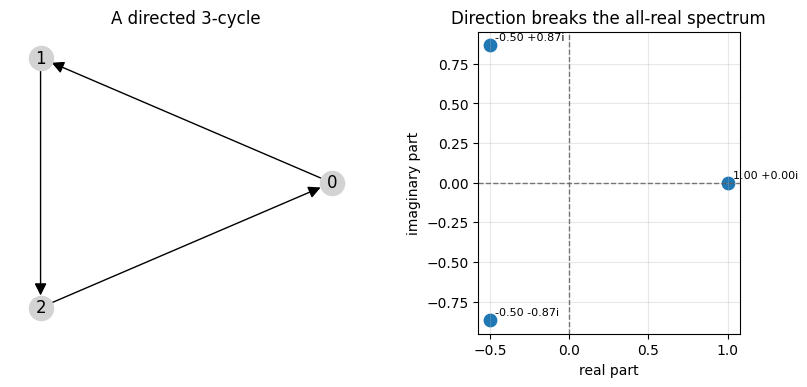

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

pos_dir3 = nx.circular_layout(G_dir3)
nx.draw_networkx(
    G_dir3,
    pos_dir3,
    ax=axes[0],
    with_labels=True,
    node_color="lightgray",
    arrows=True,
    arrowsize=18,
)
axes[0].set_title("A directed 3-cycle")
axes[0].set_axis_off()

axes[1].scatter(eig_dir3.real, eig_dir3.imag, s=80)
for lam in eig_dir3:
    axes[1].text(lam.real + 0.03, lam.imag + 0.03, f"{lam.real:.2f} {lam.imag:+.2f}i", fontsize=8)
axes[1].axhline(0, color="0.35", linestyle="--", linewidth=1, alpha=0.8)
axes[1].axvline(0, color="0.35", linestyle="--", linewidth=1, alpha=0.8)
axes[1].set_xlabel("real part")
axes[1].set_ylabel("imaginary part")
axes[1].set_title("Direction breaks the all-real spectrum")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.3)

plt.show()

### 2.3 Eigenvalues and eigenvectors: the special directions of a matrix

Before the formal definition, hold onto one picture.

A matrix is a machine that takes arrows in space and sends them to new arrows. Most arrows change in two ways at once: they get stretched or shrunk, and they also get turned. Eigenvectors are the exceptional directions that do not turn. They may get longer, shorter, flipped to the opposite direction, or even collapsed to zero, but they stay on the same line through the origin.

That picture is exactly what the algebra says. An eigenvector of a matrix $M$ is a nonzero vector $v$ satisfying

$$
Mv = \lambda v,
$$

where $M$ is the matrix, $v$ is the eigenvector, and $\lambda$ is the eigenvalue. The word "nonzero" matters because the zero vector would satisfy the equation trivially and would tell us nothing about a direction.

The eigenvalue tells us what the matrix does along that special direction. If $\lambda = 3$, the matrix triples the length. If $0 < \lambda < 1$, it shrinks the vector. If $\lambda < 0$, it also flips the direction. If $\lambda = 0$, the whole direction is sent to the zero vector.

A subtle but important point is that eigenvectors are really about directions, not individual arrows. If $v$ is an eigenvector, then any nonzero multiple $cv$ is also an eigenvector for the same eigenvalue. For symmetric problems, even the sign is arbitrary: $v$ and $-v$ represent the same eigendirection.

In network science, the same idea appears with a different kind of vector. A vector on a graph is just a list of values, one per node. An eigenvector is then a node-value pattern that a graph operator reproduces up to rescaling. For the adjacency matrix, neighborhood aggregation preserves the pattern's shape. For the Laplacian, the graph's disagreement operator responds in a self-consistent way to that pattern.

## Your turn!

Take the next 10-15 minutes to go on a short rabbit hole.

Your goal is to find the **best explanation you can** of one or more of the following:
- What is an **eigenvalue**?
- What is an **eigenvector**?
- What do people mean by the **spectral properties** of a graph?
- Why do eigenvalues and eigenvectors show up so often in network science?

### What to bring back

Be ready to share:

1. One definition or description that you think is especially good.
2. Why you think it is good.
3. Anything else interesting that you find.



In [80]:
def cosine_similarity(a, b):
    """Cosine similarity between two nonzero vectors."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        raise ValueError("cosine similarity is undefined for the zero vector")
    return float((a @ b) / denom)

M_demo = np.array([[2.0, 1.0],
                   [1.0, 2.0]], dtype=float)
evals_demo, evecs_demo = np.linalg.eigh(M_demo)

u_generic = np.array([1.0, 0.35], dtype=float)
u_generic = u_generic / np.linalg.norm(u_generic)

candidate_vectors = {
    "e1": np.array([1.0, 0.0]),
    "e2": np.array([0.0, 1.0]),
    "(1, 1)": np.array([1.0, 1.0]),
    "(1, -1)": np.array([1.0, -1.0]),
}

rows = []
for name, u in candidate_vectors.items():
    u = u / np.linalg.norm(u)
    Mu = M_demo @ u
    cos = cosine_similarity(u, Mu)
    rows.append({
        "direction": name,
        "cosine between u and M u": round(cos, 6),
        "same line through origin?": bool(np.isclose(abs(cos), 1.0, atol=1e-10)),
    })

assert np.allclose(M_demo @ evecs_demo[:, 0], evals_demo[0] * evecs_demo[:, 0])
assert np.allclose(M_demo @ evecs_demo[:, 1], evals_demo[1] * evecs_demo[:, 1])

display(pd.DataFrame(rows))
print("eigenvalues:", evals_demo)


,direction,cosine between u and M u,same line through origin?
0,e1,0.894427,False
1,e2,0.894427,False
2,"(1, 1)",1.000000,True
3,"(1, -1)",1.000000,True


eigenvalues: [1. 3.]


The table is worth pausing on. A direction is an eigenvector direction exactly when multiplying by the matrix sends it back to the same line through the origin.

The cosine test is a quick numerical way to see that idea. Cosine $+1$ means the output stays on the same ray, cosine $-1$ means it stays on the same line but flips direction, and anything strictly between $-1$ and $1$ means the matrix rotated the direction into a genuinely new one.

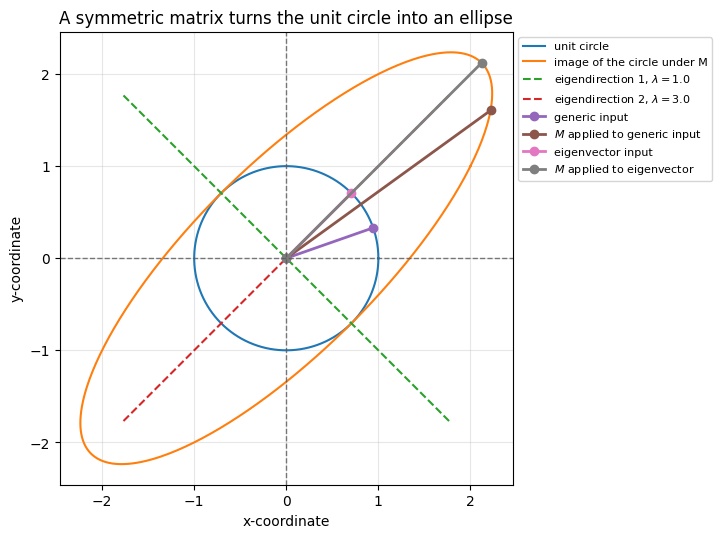

In [82]:
angles = np.linspace(0, 2 * np.pi, 400)
circle = np.column_stack([np.cos(angles), np.sin(angles)])
ellipse = circle @ M_demo.T

u_eig = normalize_sign(evecs_demo[:, 1])
Mu_generic = M_demo @ u_generic
Mu_eig = M_demo @ u_eig

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
ax.plot(circle[:, 0], circle[:, 1], color="tab:blue", label="unit circle")
ax.plot(ellipse[:, 0], ellipse[:, 1], color="tab:orange", label="image of the circle under M")

eig_colors = ["tab:green", "tab:red"]
for j in range(2):
    v = evecs_demo[:, j]
    lam = evals_demo[j]
    ax.plot(
        [-2.5 * v[0], 2.5 * v[0]],
        [-2.5 * v[1], 2.5 * v[1]],
        linestyle="--",
        linewidth=1.5,
        color=eig_colors[j],
        label=rf"eigendirection {j + 1}, $\lambda = {lam:.1f}$",
    )

ax.plot([0, u_generic[0]], [0, u_generic[1]], marker="o", linewidth=2, color="tab:purple", label="generic input")
ax.plot([0, Mu_generic[0]], [0, Mu_generic[1]], marker="o", linewidth=2, color="tab:brown", label=r"$M$ applied to generic input")

ax.plot([0, u_eig[0]], [0, u_eig[1]], marker="o", linewidth=2, color="tab:pink", label="eigenvector input")
ax.plot([0, Mu_eig[0]], [0, Mu_eig[1]], marker="o", linewidth=2, color="tab:gray", label=r"$M$ applied to eigenvector")

ax.axhline(0, color="0.35", linestyle="--", alpha=0.8, linewidth=1)
ax.axvline(0, color="0.35", linestyle="--", alpha=0.8, linewidth=1)
ax.set_xlabel("x-coordinate")
ax.set_ylabel("y-coordinate")
ax.set_title("A symmetric matrix turns the unit circle into an ellipse")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.3)
ax.legend(loc=0, bbox_to_anchor=[1.0,1.0], fontsize=8)
plt.show()


There are three ideas to keep from the figure.

First, most vectors are not eigenvectors. The generic input line is turned to a new direction. Second, an eigenvector does not have to keep its length. It only has to stay on the same line through the origin. Third, for a symmetric matrix the eigendirections are perpendicular, which is why they become such a useful coordinate system.

Students often mix up "eigenvector" with "fixed vector." Those are different. Only when $\lambda = 1$ does the vector itself stay unchanged. In general, the invariant object is the direction, or equivalently the one-dimensional subspace spanned by the vector.


In [83]:
def rescale_to_unit_max(x):
    """Rescale a vector so its largest absolute entry is one."""
    x = np.asarray(x, dtype=float)
    scale = np.max(np.abs(x))
    if scale == 0:
        return x.copy()
    return x / scale

The next figure translates the same eigenvector idea into graph language.

On a graph, a vector is just a signal living on the nodes. If that signal is an adjacency eigenvector, applying $A$ changes the scale but preserves the overall shape across the nodes. A generic signal does not have that property.

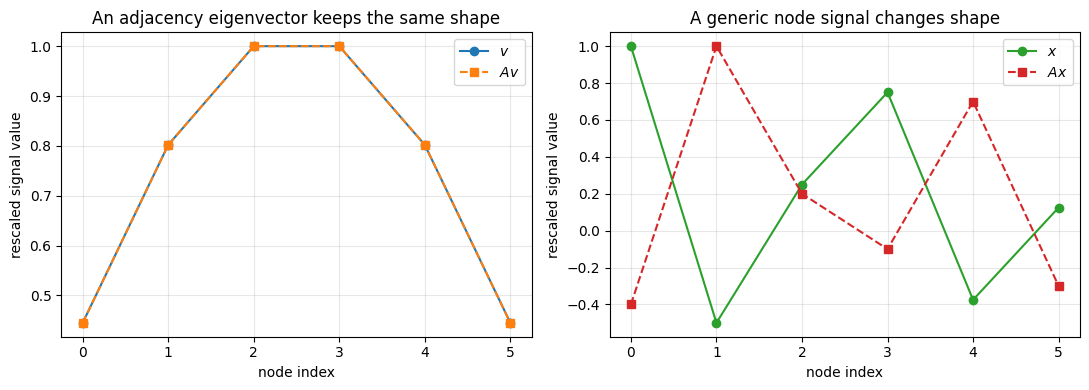

Largest adjacency eigenvalue on the path = 1.801938
Cosine similarity between v and A v = 1.0
Cosine similarity between x and A x = -0.642433


In [84]:
A_demo_graph, nodes_demo_graph = adjacency_dense(G_path6)
vals_demo_graph, vecs_demo_graph = eigh_sorted(A_demo_graph)

lam_demo_graph = vals_demo_graph[-1]
v_demo_graph = normalize_sign(vecs_demo_graph[:, -1])

x_generic = np.array([2.0, -1.0, 0.5, 1.5, -0.75, 0.25], dtype=float)
Av_demo_graph = A_demo_graph @ v_demo_graph
Ax_generic = A_demo_graph @ x_generic

eig_cos = cosine_similarity(v_demo_graph, Av_demo_graph)
generic_cos = cosine_similarity(x_generic, Ax_generic)

assert np.allclose(Av_demo_graph, lam_demo_graph * v_demo_graph)
assert np.isclose(abs(eig_cos), 1.0, atol=1e-10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

axes[0].plot(nodes_demo_graph, rescale_to_unit_max(v_demo_graph), marker="o", color="tab:blue", label=r"$v$")
axes[0].plot(nodes_demo_graph, rescale_to_unit_max(Av_demo_graph), marker="s", linestyle="--", color="tab:orange", label=r"$A v$")
axes[0].set_xlabel("node index")
axes[0].set_ylabel("rescaled signal value")
axes[0].set_title("An adjacency eigenvector keeps the same shape")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(nodes_demo_graph, rescale_to_unit_max(x_generic), marker="o", color="tab:green", label=r"$x$")
axes[1].plot(nodes_demo_graph, rescale_to_unit_max(Ax_generic), marker="s", linestyle="--", color="tab:red", label=r"$A x$")
axes[1].set_xlabel("node index")
axes[1].set_ylabel("rescaled signal value")
axes[1].set_title("A generic node signal changes shape")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Largest adjacency eigenvalue on the path =", round(lam_demo_graph, 6))
print("Cosine similarity between v and A v =", round(eig_cos, 6))
print("Cosine similarity between x and A x =", round(generic_cos, 6))


### 2.4 Why repeated multiplication picks out dominant directions

Suppose a matrix has one eigenvalue whose magnitude is strictly larger than the others. Repeated multiplication by the matrix tends to amplify the corresponding eigenvector direction.

That is the intuition behind power iteration, eigenvector centrality, and several random-walk convergence arguments. The cleanest way to think about it is to expand an initial vector in the eigenbasis. Every multiplication scales the $k$th mode by another factor of $\lambda_k$, so the mode with the largest magnitude eventually dominates the mixture.

There is one important caveat. If two eigenvalues tie in magnitude, the simple picture can fail or oscillate. That is why we demonstrate the idea on a connected, non-bipartite graph whose adjacency matrix has a unique dominant Perron eigenvalue.

Power iteration is simple enough that it is worth seeing as plain Python rather than as a black box. The next helper intentionally keeps the implementation short and transparent.

In [25]:
def power_iteration(M, n_iter=60, x0=None):
    """Basic power iteration for a dense matrix.

    This is intentionally simple and pedagogical rather than fully general.
    """
    Md = M.toarray() if sp.issparse(M) else np.asarray(M, dtype=float)
    n = Md.shape[0]
    if x0 is None:
        x = rng.normal(size=n)
    else:
        x = np.asarray(x0, dtype=float).copy()
    x = x / np.linalg.norm(x)

    history = []
    for _ in range(n_iter):
        y = Md @ x
        normy = np.linalg.norm(y)
        if normy == 0:
            break
        x = y / normy
        lam = float(x @ (Md @ x))
        history.append((lam, x.copy()))
    return history

hist_check = power_iteration(np.array([[2.0, 0.0], [0.0, 1.0]]), n_iter=5)
assert len(hist_check) >= 1


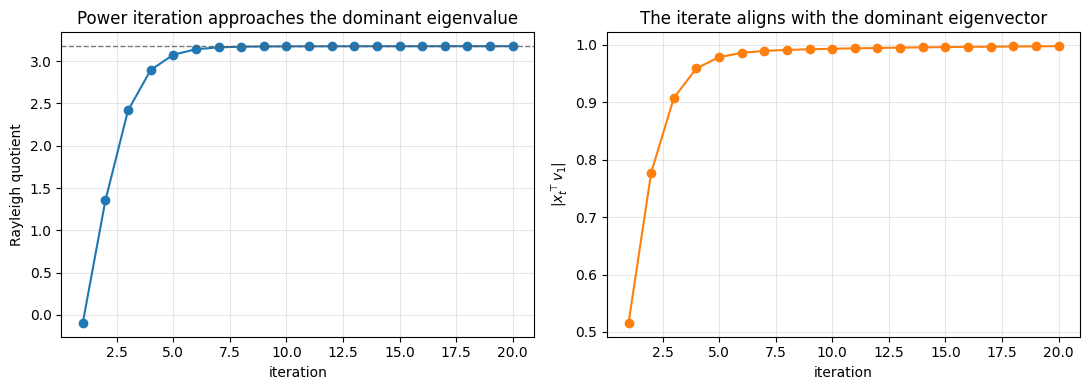

Largest adjacency eigenvalue: 3.1774096808992853


In [26]:
G_barbell_small = nx.barbell_graph(4, 1)
A_barbell, nodes_barbell = adjacency_dense(G_barbell_small)

vals_barbell, vecs_barbell = eigh_sorted(A_barbell)
lambda_max = vals_barbell[-1]
v_max = normalize_sign(vecs_barbell[:, -1])

history = power_iteration(A_barbell, n_iter=20)
rayleighs = [h[0] for h in history]
alignments = [abs(h[1] @ v_max) for h in history]

fig, ax = plt.subplots(1, 2, figsize=(11, 4), dpi=100)
ax[0].plot(np.arange(1, len(rayleighs) + 1), rayleighs, marker="o", color="tab:blue")
ax[0].axhline(lambda_max, linewidth=1, color="0.35", linestyle="--", alpha=0.8)
ax[0].set_xlabel("iteration")
ax[0].set_ylabel("Rayleigh quotient")
ax[0].set_title("Power iteration approaches the dominant eigenvalue")
ax[0].grid(alpha=0.3)

ax[1].plot(np.arange(1, len(alignments) + 1), alignments, marker="o", color="tab:orange")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel(r"$|x_t^\top v_1|$")
ax[1].set_title("The iterate aligns with the dominant eigenvector")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Largest adjacency eigenvalue:", lambda_max)


### 2.5 Change of basis and mode decomposition

Because symmetric graph matrices have orthonormal eigenvectors, every signal $x$ can be decomposed as

$$
x = \sum_{k=1}^n (v_k^\top x) v_k,
$$

where:

- $v_k$ is the $k$th eigenvector,
- $v_k^\top x$ is the coefficient of $x$ along that mode.

The coefficients tell us how much of each mode is present in the signal. This is not just a formal expansion. It is the basic bookkeeping device behind diffusion, filtering, and graph Fourier ideas. Later, when we say that a process damps high-frequency modes or preserves slow ones, this is the decomposition we will be using.

,adjacency eigenvalue,coefficient v_k^T x
0,-1.801938,-0.557958
1,-1.246980,0.103214
2,-0.445042,-0.867601
3,0.445042,-0.753042
4,1.246980,2.817082
5,1.801938,0.649827


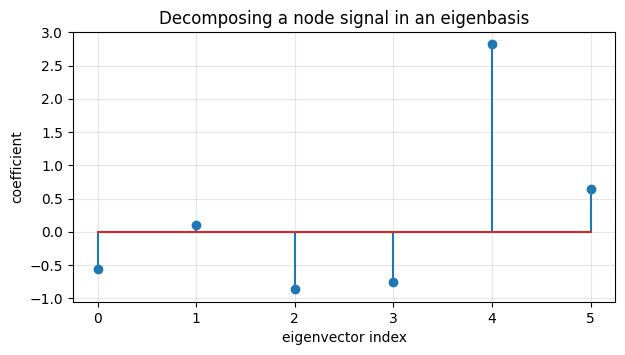

In [27]:
A_path_modes, nodes_path = adjacency_dense(G_path6)
vals_path_adj, vecs_path_adj = eigh_sorted(A_path_modes)

signal = np.array([2, 2, 0, 0, -1, -1], dtype=float)
coeffs = vecs_path_adj.T @ signal
reconstructed = vecs_path_adj @ coeffs

assert np.allclose(signal, reconstructed)

display(pd.DataFrame({
    "adjacency eigenvalue": vals_path_adj,
    "coefficient v_k^T x": coeffs
}))

fig, ax = plt.subplots(1, 1, figsize=(7, 3.5), dpi=100)
ax.stem(np.arange(len(coeffs)), coeffs)
ax.set_xlabel("eigenvector index")
ax.set_ylabel("coefficient")
ax.set_title("Decomposing a node signal in an eigenbasis")
ax.grid(alpha=0.3)
plt.show()


## 3. Canonical graph matrices

Once we are comfortable with the idea "matrix = operator on node signals," the next question is not "what is *the* graph matrix?" but rather "which graph matrix emphasizes the structure I care about?"

That choice is the beginning of spectral modeling.

- Adjacency emphasizes who talks to whom and how walks proliferate.
- The Laplacian emphasizes disagreement across edges.
- The random-walk matrix emphasizes probability flow.
- Normalized versions try to prevent high-degree nodes from dominating the story simply because they have more incident edges.

There is no single universally correct operator. There are better and worse operators for particular questions.

### 3.1 Definitions on one page

Let $A$ be the adjacency matrix and $D$ the degree matrix. Then the standard matrices we will use are

$$
L = D - A,
$$

$$
A_{\mathrm{norm}} = D^{-1/2} A D^{-1/2},
$$

$$
P = D^{-1} A,
$$

$$
L_{\mathrm{sym}} = I - D^{-1/2} A D^{-1/2},
$$

$$
L_{\mathrm{rw}} = I - D^{-1} A.
$$

A compact way to remember the family is this:

| operator | formula | read it as | typical uses |
|---|---|---|---|
| adjacency | $A$ | one-step neighbor aggregation | walk counts, eigenvector centrality |
| combinatorial Laplacian | $L=D-A$ | edge disagreement | smoothness, diffusion, cuts |
| random-walk matrix | $P=D^{-1}A$ | one-step transition operator | stationarity, mixing |
| normalized adjacency | $A_{\mathrm{norm}}$ | symmetric degree-corrected aggregation | normalized slow modes |
| symmetric normalized Laplacian | $L_{\mathrm{sym}}$ | symmetric normalized disagreement | spectral clustering, Cheeger-style theory |
| random-walk Laplacian | $L_{\mathrm{rw}}$ | disagreement in probability coordinates | random-walk and normalized-cut viewpoints |

Notice the design logic. $A$ and $A_{\mathrm{norm}}$ are aggregation operators. $L$, $L_{\mathrm{sym}}$, and $L_{\mathrm{rw}}$ are differencing operators. $P$ is stochastic rather than symmetric, so it is the natural object for dynamics of probability mass.

The next code cell computes all five objects on the same tiny graph so the algebra stays concrete.

From this point on, we also need sparse matrices and degree-normalized operators. These helpers are the sparse or normalized analogues of the tiny dense helpers above.

In [85]:
def adjacency_sparse(G, nodelist=None, weight=None, dtype=float):
    """Sparse CSR adjacency matrix with a fixed node ordering."""
    nodes = stable_nodelist(G, nodelist)
    if hasattr(nx, "to_scipy_sparse_array"):
        A = nx.to_scipy_sparse_array(G, nodelist=nodes, weight=weight, dtype=dtype, format="csr")
    else:
        A = nx.adjacency_matrix(G, nodelist=nodes, weight=weight).astype(dtype).tocsr()
    return A, nodes

def safe_inv(x):
    """Elementwise reciprocal with zeros preserved."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    mask = x != 0
    out[mask] = 1.0 / x[mask]
    return out

def safe_inv_sqrt(x):
    """Elementwise inverse square root with zeros preserved."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    mask = x > 0
    out[mask] = 1.0 / np.sqrt(x[mask])
    return out

def normalized_adjacency(A):
    """Symmetric normalized adjacency A_norm = D^{-1/2} A D^{-1/2}.

    If a node has degree zero, we use the safe convention that the corresponding
    inverse degree factor is zero.
    """
    d = degree_vector_from_adjacency(A)
    if sp.issparse(A):
        Dm12 = diag_sparse(safe_inv_sqrt(d))
        return Dm12 @ A @ Dm12
    Dm12 = np.diag(safe_inv_sqrt(d))
    return Dm12 @ A @ Dm12

def normalized_laplacian_sym(A):
    """Symmetric normalized Laplacian L_sym = I - D^{-1/2} A D^{-1/2}.

    With our safe isolate convention, isolated nodes get a 1 on the diagonal.
    """
    n = A.shape[0]
    if sp.issparse(A):
        return sp.eye(n, format="csr") - normalized_adjacency(A)
    return np.eye(n) - normalized_adjacency(A)

def random_walk_matrix(A):
    """Row-stochastic random-walk matrix P = D^{-1} A.

    For isolated nodes, we make the node absorbing so that each row still sums to 1.
    """
    d = degree_vector_from_adjacency(A)
    if sp.issparse(A):
        P = diag_sparse(safe_inv(d)) @ A
        iso = np.where(d == 0)[0]
        if len(iso) > 0:
            P = P.tolil()
            for i in iso:
                P[i, i] = 1.0
            P = P.tocsr()
        return P

    P = np.diag(safe_inv(d)) @ A
    iso = np.where(d == 0)[0]
    for i in iso:
        P[i, i] = 1.0
    return P

def normalized_laplacian_rw(A):
    """Random-walk normalized Laplacian L_rw = I - D^{-1} A."""
    n = A.shape[0]
    P = random_walk_matrix(A)
    if sp.issparse(A):
        return sp.eye(n, format="csr") - P
    return np.eye(n) - P

def eigsh_sorted(M, k=6, which="SM"):
    """A small number of eigenpairs for a symmetric matrix.

    For small matrices we switch to dense linear algebra because it is often more stable.
    """
    n = M.shape[0]
    if n <= max(40, 3 * k + 5):
        vals, vecs = eigh_sorted(M)
        if which in ["LA", "LM"]:
            idx = np.argsort(vals)[::-1][:k]
            idx = np.sort(idx)
            return vals[idx], vecs[:, idx]
        if which in ["SM", "SA"]:
            return vals[:k], vecs[:, :k]
        order = np.argsort(np.abs(vals))
        idx = order[:k]
        idx = np.sort(idx)
        return vals[idx], vecs[:, idx]

    vals, vecs = spla.eigsh(M, k=k, which=which)
    idx = np.argsort(vals)
    return vals[idx], vecs[:, idx]

A_sparse_check = sp.csr_matrix(np.array([[0.0, 1.0], [1.0, 0.0]]))
P_sparse_check = random_walk_matrix(A_sparse_check)
assert np.allclose(P_sparse_check.toarray().sum(axis=1), 1.0)


In [86]:
G_tiny = nx.path_graph(4)
A_tiny, nodes_tiny = adjacency_dense(G_tiny)
L_tiny = laplacian_from_adjacency(A_tiny)
A_norm_tiny = normalized_adjacency(A_tiny)
P_tiny = random_walk_matrix(A_tiny)
Lsym_tiny = normalized_laplacian_sym(A_tiny)
Lrw_tiny = normalized_laplacian_rw(A_tiny)

assert np.allclose(P_tiny.sum(axis=1), 1.0)

show_matrix_df(A_tiny, name="A", index=nodes_tiny, columns=nodes_tiny)
show_matrix_df(L_tiny, name="L = D - A", index=nodes_tiny, columns=nodes_tiny)
show_matrix_df(np.round(A_norm_tiny, 3), name="A_norm = D^{-1/2} A D^{-1/2}", index=nodes_tiny, columns=nodes_tiny)
show_matrix_df(np.round(P_tiny, 3), name="P = D^{-1} A", index=nodes_tiny, columns=nodes_tiny)
show_matrix_df(np.round(Lsym_tiny, 3), name="L_sym = I - D^{-1/2} A D^{-1/2}", index=nodes_tiny, columns=nodes_tiny)
show_matrix_df(np.round(Lrw_tiny, 3), name="L_rw = I - D^{-1} A", index=nodes_tiny, columns=nodes_tiny)


A


,0,1,2,3
0,0.0,1.0,0.0,0.0
1,1.0,0.0,1.0,0.0
2,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,0.0


L = D - A


,0,1,2,3
0,1.0,-1.0,0.0,0.0
1,-1.0,2.0,-1.0,0.0
2,0.0,-1.0,2.0,-1.0
3,0.0,0.0,-1.0,1.0


A_norm = D^{-1/2} A D^{-1/2}


...

,0,1,2,3
0,0.0,1.0,0.0,0.0
1,0.5,0.0,0.5,0.0
2,0.0,0.5,0.0,0.5
3,0.0,0.0,1.0,0.0


L_sym = I - D^{-1/2} A D^{-1/2}


,0,1,2,3
0,1.000,-0.707,0.000,0.000
1,-0.707,1.000,-0.500,0.000
2,0.000,-0.500,1.000,-0.707
3,0.000,0.000,-0.707,1.000


L_rw = I - D^{-1} A


,0,1,2,3
0,1.0,-1.0,0.0,0.0
1,-0.5,1.0,-0.5,0.0
2,0.0,-0.5,1.0,-0.5
3,0.0,0.0,-1.0,1.0


### 3.2 Isolated nodes and safe normalization

Normalization introduces a real practical issue: if a node has degree zero, then $D^{-1}$ and $D^{-1/2}$ are formally undefined on that node.

Many theoretical statements quietly assume graphs have no isolated nodes. Real data do not always cooperate, so code has to choose a convention. We will use the explicit convention implemented in the helper functions above:

- if $d_i = 0$, then the corresponding inverse degree factor is set to $0$;
- for the random-walk matrix, the isolated node becomes absorbing, so the row still sums to $1$;
- for $L_{\mathrm{sym}} = I - D^{-1/2} A D^{-1/2}$, the isolated node therefore gets a $1$ on the diagonal.

Some texts treat isolated nodes separately. The important thing is not which convention you memorize; it is that you state the convention and then use it consistently.

In [87]:
G_iso = nx.Graph()
G_iso.add_edge(0, 1)
G_iso.add_node(2)

A_iso, nodes_iso = adjacency_dense(G_iso)
P_iso = random_walk_matrix(A_iso)
Lsym_iso = normalized_laplacian_sym(A_iso)

print("Degrees:", degree_vector_from_adjacency(A_iso))
show_matrix_df(np.round(P_iso, 3), name="Random-walk matrix with an isolated node", index=nodes_iso, columns=nodes_iso)
show_matrix_df(np.round(Lsym_iso, 3), name="Normalized Laplacian with our isolate convention", index=nodes_iso, columns=nodes_iso)

assert np.allclose(P_iso.sum(axis=1), 1.0)


Degrees: [1. 1. 0.]
Random-walk matrix with an isolated node


,0,1,2
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0


Normalized Laplacian with our isolate convention


,0,1,2
0,1.0,-1.0,0.0
1,-1.0,1.0,0.0
2,0.0,0.0,1.0


### 3.3 The normalized Laplacian is $I - A_{\mathrm{norm}}$

For non-isolated nodes, the symmetric normalized Laplacian is

$$
L_{\mathrm{sym}} = I - A_{\mathrm{norm}}.
$$

This is more than a notation trick. It means that the spectra of $A_{\mathrm{norm}}$ and $L_{\mathrm{sym}}$ carry the same mode information on different numerical scales. If $A_{\mathrm{norm}} v = \mu v$, then

$$
L_{\mathrm{sym}} v = (1-\mu) v.
$$

So the same eigenvector can be read either as a normalized adjacency mode or as a normalized Laplacian mode. The only thing that changes is whether we find it more useful to talk in terms of $\mu$ near $1$ or $\lambda$ near $0$.

In [31]:
A_star, nodes_star = adjacency_dense(G_star6)
A_norm_star = normalized_adjacency(A_star)
Lsym_star = normalized_laplacian_sym(A_star)

vals_A_norm, vecs_A_norm = eigh_sorted(A_norm_star)
vals_Lsym, vecs_Lsym = eigh_sorted(Lsym_star)

print("Top eigenvalues of A_norm:", np.round(vals_A_norm[::-1], 4))
print("Small eigenvalues of L_sym:", np.round(vals_Lsym[:3], 4))
print("Check lambda(L_sym) = 1 - lambda(A_norm):", np.allclose(np.sort(vals_Lsym), np.sort(1 - vals_A_norm)))

assert np.allclose(np.sort(vals_Lsym), np.sort(1 - vals_A_norm))


Top eigenvalues of A_norm: [ 1.  0.  0.  0.  0. -1.]
Small eigenvalues of L_sym: [0. 1. 1.]
Check lambda(L_sym) = 1 - lambda(A_norm): True


### 3.4 The same normalized eigenproblem in three coordinate systems

On a graph with no isolated nodes, four operators are tightly connected:

$$
A_{\mathrm{norm}} = D^{-1/2} A D^{-1/2},
\qquad
P = D^{-1} A,
\qquad
L_{\mathrm{sym}} = I - A_{\mathrm{norm}},
\qquad
L_{\mathrm{rw}} = I - P.
$$

These are not unrelated definitions. They are the same slow-mode story written in different coordinates.

First, $P$ is similar to $A_{\mathrm{norm}}$:

$$
P = D^{-1/2} A_{\mathrm{norm}} D^{1/2}.
$$

Second, $L_{\mathrm{sym}}$ and $A_{\mathrm{norm}}$ share eigenvectors, and their eigenvalues differ by a shift of $1$:

$$
L_{\mathrm{sym}} u = (I - A_{\mathrm{norm}})u = (1-\mu)u
$$

whenever $A_{\mathrm{norm}}u = \mu u$.

Third, $L_{\mathrm{rw}}$ is similar to $L_{\mathrm{sym}}$:

$$
L_{\mathrm{rw}} = D^{-1/2} L_{\mathrm{sym}} D^{1/2}.
$$

So when people talk about a slow normalized mode of a graph, they may compute it using any of these matrices. The coordinates change, but the structural content does not.

In [32]:
A_path_norm, nodes_path_norm = adjacency_dense(G_path6)
d_path_norm = degree_vector_from_adjacency(A_path_norm)
Dph = np.diag(np.sqrt(d_path_norm))
Dm12 = np.diag(safe_inv_sqrt(d_path_norm))

A_norm_path = normalized_adjacency(A_path_norm)
P_path_norm = random_walk_matrix(A_path_norm)
Lsym_path = normalized_laplacian_sym(A_path_norm)
Lrw_path = normalized_laplacian_rw(A_path_norm)

assert np.allclose(P_path_norm, Dm12 @ A_norm_path @ Dph)
assert np.allclose(Lrw_path, Dm12 @ Lsym_path @ Dph)

mu_desc = np.sort(np.linalg.eigvalsh(A_norm_path))[::-1]
muP_desc = np.sort(np.real_if_close(np.linalg.eigvals(P_path_norm)))[::-1]
lam_shift = 1.0 - mu_desc
lam_Lsym = np.sort(np.linalg.eigvalsh(Lsym_path))
lam_Lrw = np.sort(np.real_if_close(np.linalg.eigvals(Lrw_path)))

assert np.allclose(mu_desc, muP_desc)
assert np.allclose(lam_shift, lam_Lsym)
assert np.allclose(lam_shift, lam_Lrw)

display(pd.DataFrame({
    r"$\mu$ from $A_{\mathrm{norm}}$": mu_desc,
    r"same $\mu$ from $P$": muP_desc,
    r"$1-\mu$": lam_shift,
    r"eigenvalue of $L_{\mathrm{sym}}$": lam_Lsym,
    r"eigenvalue of $L_{rw}$": lam_Lrw,
}).round(4))

,$\mu$ from $A_{\mathrm{norm}}$,same $\mu$ from $P$,$1-\mu$,eigenvalue of $L_{\mathrm{sym}}$,eigenvalue of $L_{rw}$
0,1.000,1.000,0.000,0.000,0.000
1,0.809,0.809,0.191,0.191,0.191
2,0.309,0.309,0.691,0.691,0.691
3,-0.309,-0.309,1.309,1.309,1.309
4,-0.809,-0.809,1.809,1.809,1.809
5,-1.000,-1.000,2.000,2.000,2.000


The eigenvalues agree exactly, but the vectors are not literally the same arrays in every coordinate system. Degree rescaling changes amplitudes even when the underlying slow mode is the same.

That point matters later. When we talk about normalized cuts, sweep cuts, or random-walk slow modes, we have to keep straight whether we are plotting the symmetric-coordinate vector $u_2$ or the degree-rescaled vector $D^{-1/2} u_2$.

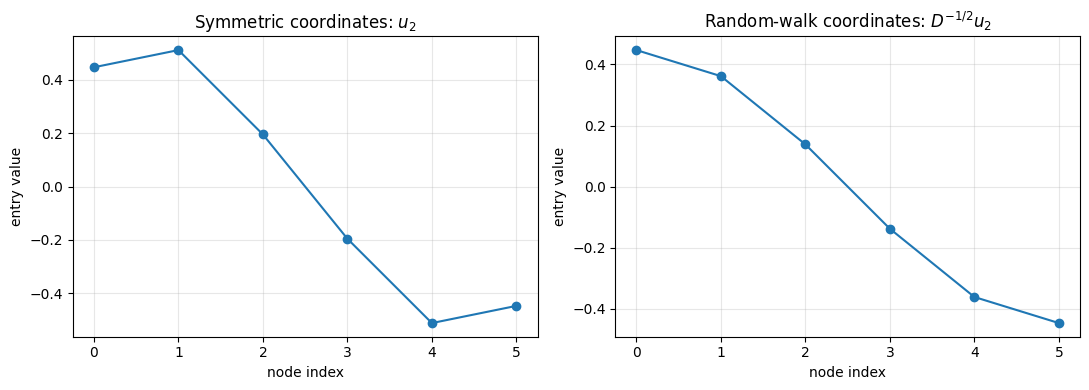

,degree,$u_2$,$D^{-1/2}u_2$
0,1.0,0.4472,0.4472
1,2.0,0.5117,0.3618
2,2.0,0.1954,0.1382
3,2.0,-0.1954,-0.1382
4,2.0,-0.5117,-0.3618
5,1.0,-0.4472,-0.4472


In [33]:
vals_Lsym_path_full, vecs_Lsym_path_full = eigh_sorted(Lsym_path)
u2_path = normalize_sign(vecs_Lsym_path_full[:, 1])

x2_rw_path = safe_inv_sqrt(d_path_norm) * u2_path
if x2_rw_path @ u2_path < 0:
    x2_rw_path *= -1.0

mu2_path = 1.0 - vals_Lsym_path_full[1]

assert np.allclose(P_path_norm @ x2_rw_path, mu2_path * x2_rw_path)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

axes[0].plot(nodes_path_norm, u2_path, marker="o")
axes[0].set_xlabel("node index")
axes[0].set_ylabel("entry value")
axes[0].set_title(r"Symmetric coordinates: $u_2$")
axes[0].grid(alpha=0.3)

axes[1].plot(nodes_path_norm, x2_rw_path, marker="o")
axes[1].set_xlabel("node index")
axes[1].set_ylabel("entry value")
axes[1].set_title(r"Random-walk coordinates: $D^{-1/2} u_2$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "degree": d_path_norm,
    r"$u_2$": u2_path,
    r"$D^{-1/2}u_2$": x2_rw_path,
}, index=nodes_path_norm).round(4))

The table is easy to underestimate. It says that a cut mode, a random-walk mixing mode, and a normalized-adjacency mode are often literally the same structural object viewed in different coordinates.

That is one of the central organizing ideas of the chapter. A lot of spectral network science feels less mysterious once we stop treating these operators as separate tricks and start reading them as different coordinate versions of the same low-dimensional geometry.

### 3.5 A quick bipartite example: why the eigenvalue $-1$ matters

For a connected graph with no isolated nodes, the symmetric normalized adjacency matrix has eigenvalue $-1$ exactly when the graph is bipartite. This is not a cosmetic fact. It explains why ordinary random walks on bipartite graphs can oscillate forever between the two sides instead of relaxing smoothly to equilibrium.

We check that claim on two tiny graphs: the 6-cycle, which is bipartite, and the triangle, which is not.

Eigenvalues of A_norm on C6: [-1.  -0.5 -0.5  0.5  0.5  1. ]
Eigenvalues of A_norm on K3: [-0.5 -0.5  1. ]


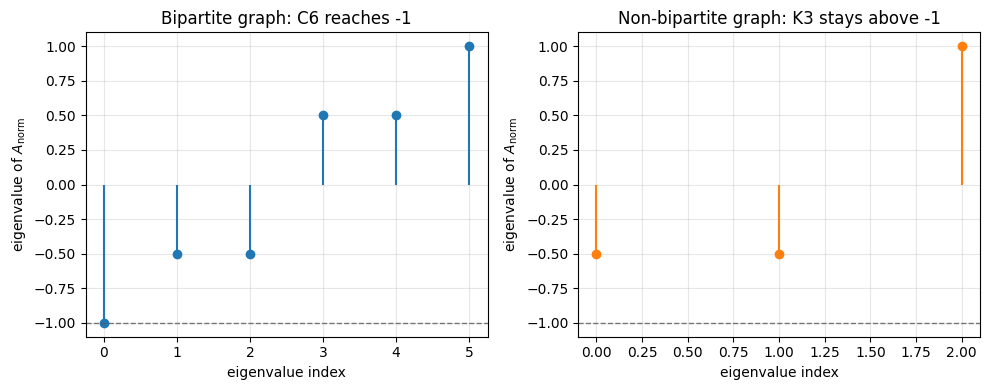

In [34]:
G_bip = nx.cycle_graph(6)
G_nonbip = nx.complete_graph(3)

A_bip, nodes_bip = adjacency_dense(G_bip)
A_nonbip, nodes_nonbip = adjacency_dense(G_nonbip)

evals_bip = np.linalg.eigvalsh(normalized_adjacency(A_bip))
evals_nonbip = np.linalg.eigvalsh(normalized_adjacency(A_nonbip))

print("Eigenvalues of A_norm on C6:", np.round(evals_bip, 4))
print("Eigenvalues of A_norm on K3:", np.round(evals_nonbip, 4))

assert np.isclose(np.min(evals_bip), -1.0)
assert np.min(evals_nonbip) > -1.0 + 1e-8

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

markerline0, stemlines0, baseline0 = axes[0].stem(np.arange(len(evals_bip)), np.sort(evals_bip), basefmt=" ")
plt.setp(markerline0, color="tab:blue")
plt.setp(stemlines0, color="tab:blue")
axes[0].axhline(-1.0, color="0.35", linestyle="--", linewidth=1, alpha=0.8)
axes[0].set_xlabel("eigenvalue index")
axes[0].set_ylabel(r"eigenvalue of $A_{\mathrm{norm}}$")
axes[0].set_title("Bipartite graph: C6 reaches -1")
axes[0].grid(alpha=0.3)

markerline1, stemlines1, baseline1 = axes[1].stem(np.arange(len(evals_nonbip)), np.sort(evals_nonbip), basefmt=" ")
plt.setp(markerline1, color="tab:orange")
plt.setp(stemlines1, color="tab:orange")
axes[1].axhline(-1.0, color="0.35", linestyle="--", linewidth=1, alpha=0.8)
axes[1].set_xlabel("eigenvalue index")
axes[1].set_ylabel(r"eigenvalue of $A_{\mathrm{norm}}$")
axes[1].set_title("Non-bipartite graph: K3 stays above -1")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


The 6-cycle reaches $-1$ because every step flips parity: from one side of the bipartition to the other and back again. The triangle has an odd cycle, so that perfect back-and-forth alternation is impossible and the spectrum stays strictly above $-1$.

## 4. Laplacian structure, smoothness, and graph Fourier intuition

The Laplacian is the graph matrix that most clearly turns local network structure into geometry. If adjacency says "aggregate over neighbors," the Laplacian says "measure disagreement across edges."

That is why the Laplacian appears in diffusion, consensus, clustering, graph signal processing, effective resistance, and many optimization problems. Once we understand what $L$ is measuring, a large fraction of spectral network science starts to line up.

### 4.1 The Laplacian quadratic form is a smoothness measure

For an undirected graph and a node signal $x \in \mathbb{R}^n$, the Laplacian quadratic form is

$$
x^\top L x.
$$

This quantity has a famous and extremely useful identity:

$$
x^\top L x
= \sum_{(u,v)\in E} (x_u - x_v)^2
$$

for an unweighted undirected graph.

Every symbol in this identity carries intuition.

- $(u,v)\in E$ means an edge joins nodes $u$ and $v$.
- $x_u - x_v$ is the disagreement across that edge.
- squaring prevents cancellation and punishes large disagreements.
- summing over all edges measures total roughness of the signal on the graph.

So small $x^\top L x$ means the signal is smooth across edges. Large $x^\top L x$ means the signal oscillates sharply from node to node.

For nonnegative weighted graphs, the same story survives with each squared difference weighted by the edge weight. That weighted version is one reason ordinary weighted Laplacians remain positive semidefinite. Signed networks are different, and we will treat them separately later in the course.

In [35]:
L_cycle, nodes_cycle = adjacency_dense(G_cycle6)
L_cycle = laplacian_from_adjacency(L_cycle)

x = np.array([1, 1, 1, -1, -1, -1], dtype=float)
q = laplacian_quadratic_form(L_cycle, x)

edge_sum = 0.0
for u, v in G_cycle6.edges():
    edge_sum += (x[u] - x[v]) ** 2

print("x^T L x =", q)
print("sum over edges (x_u - x_v)^2 =", edge_sum)

assert np.isclose(q, edge_sum)


x^T L x = 8.0
sum over edges (x_u - x_v)^2 = 8.0


The identity becomes easier to trust once we compare several signals on the same graph. A constant signal should cost zero because every edge sees no disagreement. A gentle ramp should cost something moderate. An alternating signal should cost much more because nearly every edge sees a large jump.

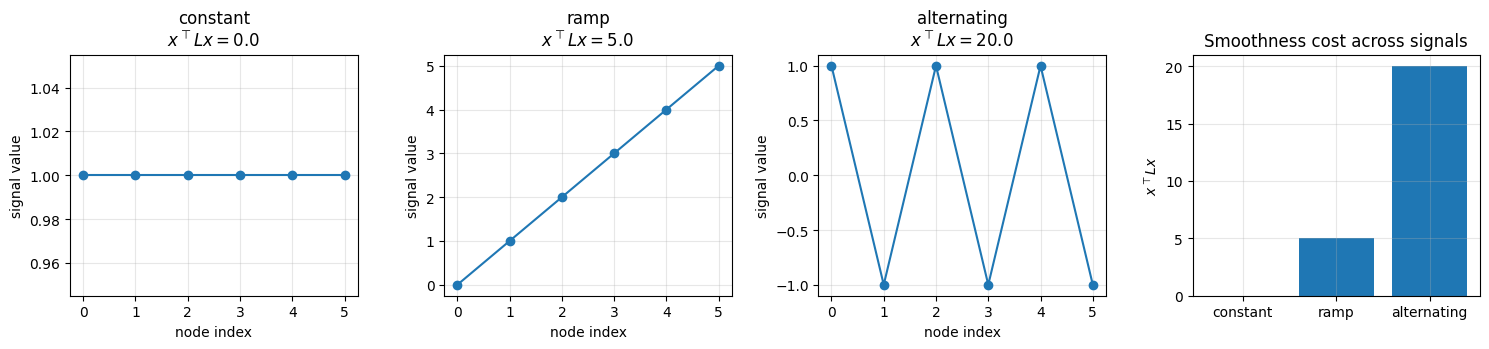

,signal,$x^\top L x$
0,constant,0.0
1,ramp,5.0
2,alternating,20.0


In [36]:
A_qdemo, nodes_qdemo = adjacency_dense(G_path6)
L_qdemo = laplacian_from_adjacency(A_qdemo)

signals_qdemo = {
    "constant": np.ones(len(nodes_qdemo), dtype=float),
    "ramp": np.arange(len(nodes_qdemo), dtype=float),
    "alternating": np.array([1, -1, 1, -1, 1, -1], dtype=float),
}

q_rows = []
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), dpi=100)

for ax, (name, sig) in zip(axes[:3], signals_qdemo.items()):
    qsig = laplacian_quadratic_form(L_qdemo, sig)
    q_rows.append({"signal": name, r"$x^\top L x$": qsig})
    ax.plot(nodes_qdemo, sig, marker="o")
    ax.set_xlabel("node index")
    ax.set_ylabel("signal value")
    ax.set_title(f"{name}\n$x^\\top L x = {qsig:.1f}$")
    ax.grid(alpha=0.3)

axes[3].bar([row["signal"] for row in q_rows], [row[r"$x^\top L x$"] for row in q_rows])
axes[3].set_ylabel(r"$x^\top L x$")
axes[3].set_title("Smoothness cost across signals")
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(pd.DataFrame(q_rows))

### 4.2 Connected components and the nullspace of the Laplacian

The vector of all ones, usually written $\mathbf{1}$, always satisfies

$$
L \mathbf{1} = 0.
$$

Why? Because every row of $L$ sums to zero.

More generally, the multiplicity of the eigenvalue $0$ equals the number of connected components of the graph. Equivalently, the nullspace of $L$ is spanned by the indicator vectors of the connected components. On each connected piece, a constant signal is invisible to the difference operator because there is no variation to detect inside that piece.

This is one of the first central payoffs of spectral graph theory: a graph-theoretic property is encoded exactly in the spectrum of a matrix. Chung (1997) and Mohar (1991) are standard references for this viewpoint.

In [37]:
A_disc, nodes_disc = adjacency_dense(G_disc)
L_disc = laplacian_from_adjacency(A_disc)
vals_disc, vecs_disc = eigh_sorted(L_disc)

zero_mult = np.sum(np.isclose(vals_disc, 0.0, atol=1e-10))
num_components = nx.number_connected_components(G_disc)

print("Smallest Laplacian eigenvalues:", np.round(vals_disc[:5], 6))
print("Multiplicity of 0:", zero_mult)
print("Number of connected components:", num_components)

assert zero_mult == num_components

component_vectors = []
for comp in nx.connected_components(G_disc):
    z = np.zeros(len(nodes_disc))
    for u in comp:
        z[nodes_disc.index(u)] = 1.0
    component_vectors.append(z)

for idx, z in enumerate(component_vectors, start=1):
    print(f"||L z_{idx}|| =", np.linalg.norm(L_disc @ z))


Smallest Laplacian eigenvalues: [-0.     -0.      0.5858  2.      2.    ]
Multiplicity of 0: 2
Number of connected components: 2
||L z_1|| = 0.0
||L z_2|| = 0.0


### 4.3 Comparing Laplacian spectra across graph families

Before we talk about sophisticated applications, it is worth calibrating our intuition on familiar graph families.

- A path has small Laplacian eigenvalues packed near zero because long-range variation can change slowly.
- A clique has much larger nonzero eigenvalues because every node is tightly coupled to every other node.
- A star has one very large eigenvalue associated with the hub and many repeated eigenvalues reflecting the symmetry of the leaves.
- A cycle behaves like a discrete periodic domain.

Seeing these families side by side makes later interpretations much easier. When a real network has a small second eigenvalue, repeated eigenvalues, or a sharp spectral spread, we want those patterns to feel familiar rather than mysterious.

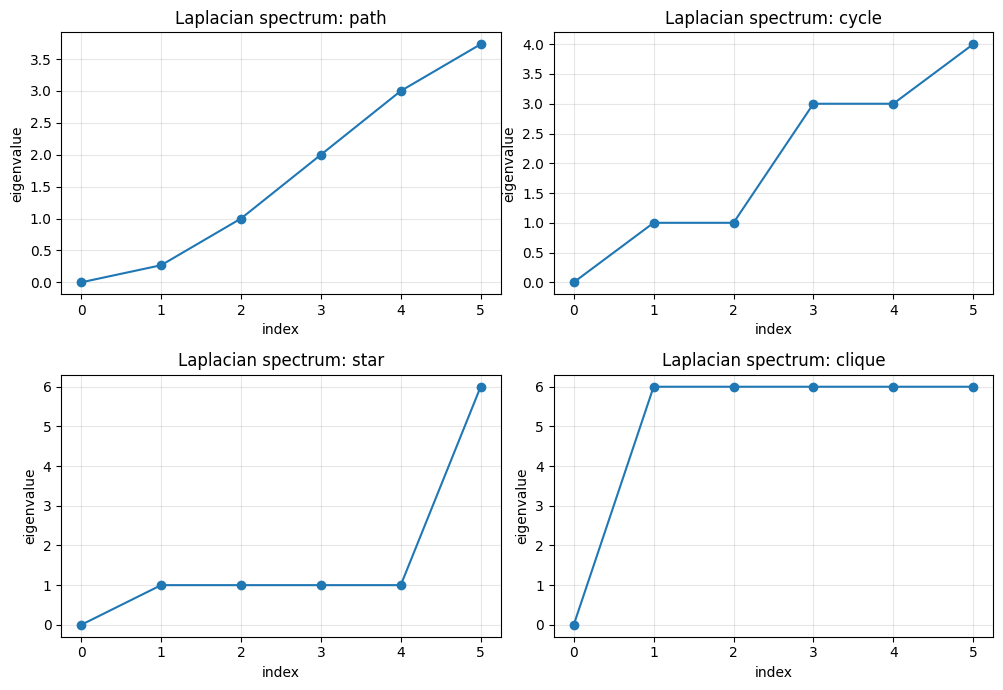

In [38]:
graph_family = {
    "path": G_path6,
    "cycle": G_cycle6,
    "star": G_star6,
    "clique": G_clique6,
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=100)
axes = axes.ravel()

for ax, (name, Gfam) in zip(axes, graph_family.items()):
    A_fam, _ = adjacency_dense(Gfam)
    L_fam = laplacian_from_adjacency(A_fam)
    vals_fam, _ = eigh_sorted(L_fam)
    ax.plot(np.arange(len(vals_fam)), vals_fam, marker="o")
    ax.set_title(f"Laplacian spectrum: {name}")
    ax.set_xlabel("index")
    ax.set_ylabel("eigenvalue")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 4.4 Graph Fourier intuition

On the real line, the eigenfunctions of the second derivative are sines and cosines. On a graph, the eigenvectors of the Laplacian play the analogous role.

Low-eigenvalue Laplacian eigenvectors vary slowly across edges. High-eigenvalue eigenvectors oscillate rapidly. That is why people often call them low-frequency and high-frequency graph modes.

We can see this directly on a path graph. We will expand a signal in Laplacian eigenvectors and then keep only the lowest-frequency modes. The result is a graph analogue of low-pass filtering. This viewpoint is standard in spectral graph theory and graph signal processing; Chung (1997) and Shuman et al. (2013) are especially useful references.

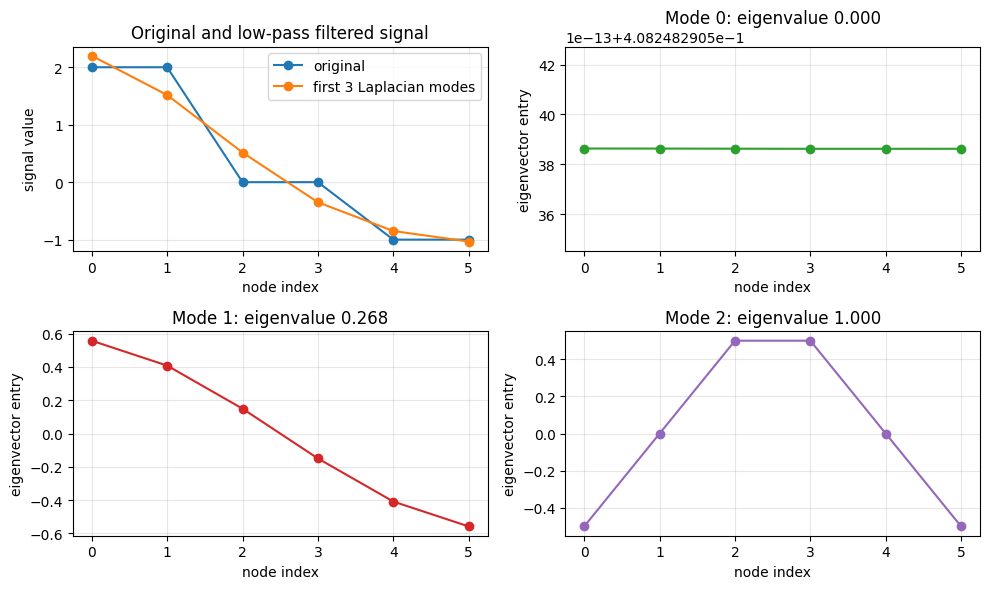

In [39]:
A_path, nodes_path = adjacency_dense(G_path6)
L_path = laplacian_from_adjacency(A_path)
vals_L_path, vecs_L_path = eigh_sorted(L_path)

signal = np.array([2, 2, 0, 0, -1, -1], dtype=float)
coeffs = vecs_L_path.T @ signal

k_keep = 3
filtered = vecs_L_path[:, :k_keep] @ coeffs[:k_keep]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), dpi=100)
axes = axes.ravel()

axes[0].plot(nodes_path, signal, marker="o", color="tab:blue")
axes[0].plot(nodes_path, filtered, marker="o", color="tab:orange")
axes[0].set_xlabel("node index")
axes[0].set_ylabel("signal value")
axes[0].set_title("Original and low-pass filtered signal")
axes[0].legend(["original", f"first {k_keep} Laplacian modes"])
axes[0].grid(alpha=0.3)

mode_colors = ["tab:green", "tab:red", "tab:purple"]
for j in range(3):
    axes[j + 1].plot(nodes_path, vecs_L_path[:, j], marker="o", color=mode_colors[j])
    axes[j + 1].set_xlabel("node index")
    axes[j + 1].set_ylabel("eigenvector entry")
    axes[j + 1].set_title(f"Mode {j}: eigenvalue {vals_L_path[j]:.3f}")
    axes[j + 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Notice how the lowest Laplacian modes on the path look like increasingly oscillatory standing waves. The zeroth mode is flat because a constant signal creates no disagreement across any edge, the first nontrivial mode swings once from one side of the path to the other, and the next mode oscillates twice. Keeping only these low modes removes the sharp edge-to-edge fluctuations carried by higher modes, so the reconstructed signal acts like a smoothing filter on the original graph signal.

### Your turn!

Choose two signals on the same graph: one that is smooth and one that alternates sharply from node to node. Compute $x^\top L x$ for both. Which one should be larger before you run the code?

A quick rule of thumb: if the signal changes sign across many edges, the quadratic form should grow.


In [40]:
# Reference solution
A_cycle, nodes_cycle = adjacency_dense(G_cycle6)
L_cycle = laplacian_from_adjacency(A_cycle)

x_smooth = np.array([0, 1, 2, 2, 1, 0], dtype=float)
x_rough = np.array([1, -1, 1, -1, 1, -1], dtype=float)

q_smooth = laplacian_quadratic_form(L_cycle, x_smooth)
q_rough = laplacian_quadratic_form(L_cycle, x_rough)

print("x_smooth^T L x_smooth =", q_smooth)
print("x_rough^T L x_rough   =", q_rough)

assert q_rough > q_smooth


x_smooth^T L x_smooth = 4.0
x_rough^T L x_rough   = 24.0


## 5. Adjacency spectra, long walks, and centrality

The Laplacian is not the whole story. The adjacency matrix has its own spectral meaning.

Because powers of $A$ count walks, the large eigenvalues of $A$ control the growth of long walks. For a connected, nonnegative, irreducible adjacency matrix, the Perron-Frobenius theorem tells us that there is a dominant real eigenvalue with a nonnegative eigenvector. In network science, that dominant eigenvector leads directly to eigenvector centrality.


### 5.1 Spectral radius and long walks

The spectral radius of a matrix $A$ is

$$
\rho(A) = \max_i |\lambda_i(A)|.
$$

For a connected, undirected, non-bipartite graph, the leading adjacency eigenvalue is positive and strictly larger in magnitude than the others. Repeated multiplication by $A$ then amplifies the corresponding eigenvector direction, which is why the dominant eigenvector summarizes long-run walk amplification.

The practical message is simple: if a node pattern aligns strongly with the dominant adjacency eigenvector, that pattern persists under repeated neighbor aggregation.


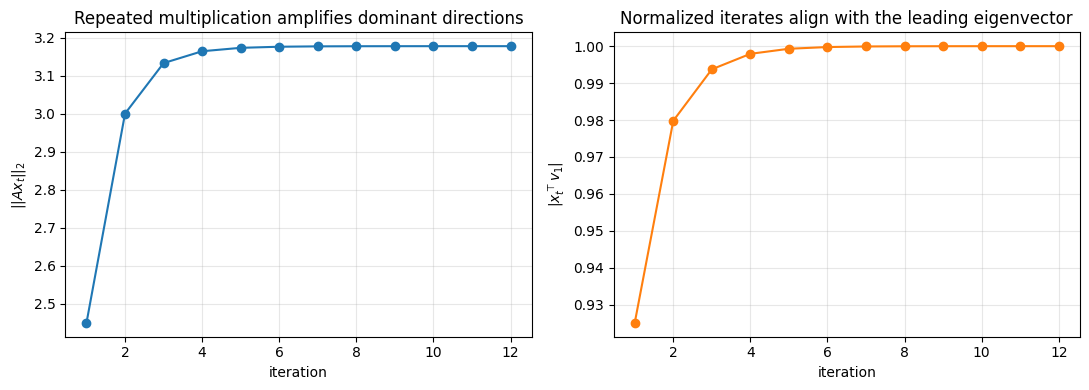

Spectral radius rho(A) = 3.1774096808992853


In [41]:
A_barbell, nodes_barbell = adjacency_dense(G_barbell_small)
vals_barbell, vecs_barbell = eigh_sorted(A_barbell)
rhoA = np.max(np.abs(vals_barbell))
v_dom = normalize_sign(vecs_barbell[:, -1])

x0 = np.array([1, 0, 0, 1, 0, 1, 0, 0, 1], dtype=float)
x = x0 / np.linalg.norm(x0)
aligned = []
norms = []

for _ in range(12):
    x = A_barbell @ x
    norms.append(np.linalg.norm(x))
    x = x / np.linalg.norm(x)
    aligned.append(abs(x @ v_dom))

fig, ax = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

ax[0].plot(np.arange(1, len(norms) + 1), norms, marker="o", color="tab:blue")
ax[0].set_xlabel("iteration")
ax[0].set_ylabel(r"$||A x_t||_2$")
ax[0].set_title("Repeated multiplication amplifies dominant directions")
ax[0].grid(alpha=0.3)

ax[1].plot(np.arange(1, len(aligned) + 1), aligned, marker="o", color="tab:orange")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel(r"$|x_t^\top v_1|$")
ax[1].set_title("Normalized iterates align with the leading eigenvector")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Spectral radius rho(A) =", rhoA)


### 5.2 Eigenvector centrality

Eigenvector centrality assigns a score $c_i$ to each node by requiring that important nodes are connected to other important nodes. In matrix form, the definition is

$$
A c = \lambda_1 c,
$$

where:

- $A$ is the adjacency matrix,
- $c$ is the centrality vector,
- $\lambda_1$ is the largest adjacency eigenvalue.

This is not just a convenient formula. It is the fixed-point version of the idea "my importance depends on the importance of my neighbors."

For connected undirected graphs, the Perron-Frobenius theorem guarantees a positive leading eigenvector. That is why eigenvector centrality makes sense as a ranking. Standard network-science discussions appear in Newman (2018), and the historical lineage connects to Katz (1953) and later centrality work.

It is also worth noticing what this definition is *not* saying. It is not counting only immediate degree, and it is not averaging over all paths with equal weight. It is balancing local reinforcement recursively across the whole network.

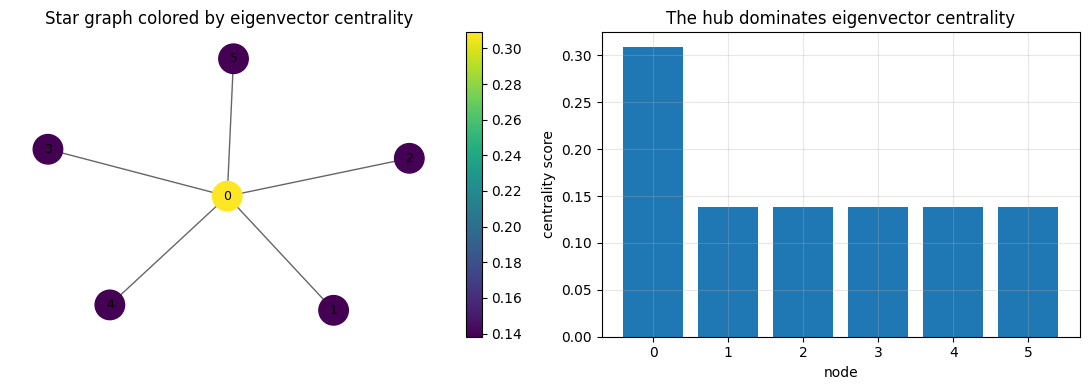

,eigenvector centrality
0,0.309017
1,0.138197
2,0.138197
3,0.138197
4,0.138197
5,0.138197


In [42]:
# A star graph is the cleanest first example.
A_star, nodes_star = adjacency_dense(G_star6)
vals_star, vecs_star = eigh_sorted(A_star)
c_star = normalize_sign(vecs_star[:, -1])
c_star = c_star / c_star.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

pos_star = nx.spring_layout(G_star6, seed=2)
draw_graph(G_star6, axes[0], pos=pos_star, values=c_star, title="Star graph colored by eigenvector centrality")

axes[1].bar(nodes_star, c_star)
axes[1].set_xlabel("node")
axes[1].set_ylabel("centrality score")
axes[1].set_title("The hub dominates eigenvector centrality")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(pd.DataFrame({"eigenvector centrality": c_star}, index=nodes_star))


### 5.3 A localization warning

Eigenvector centrality is elegant, but it can also mislead us. On graphs with strong degree heterogeneity, the leading eigenvector can localize: a small set of high-degree nodes carries most of the mass. Then the ranking is no longer describing the graph broadly; it is mostly describing the hubs.

One quick diagnostic is the inverse participation ratio, or IPR. For a unit-norm vector $v$, it is

$$
\mathrm{IPR}(v) = \sum_{i=1}^n v_i^4.
$$

Large IPR means the vector is concentrated on fewer coordinates. Small IPR means it is more delocalized.

Martin, Zhang, and Newman (2014) study this localization phenomenon in detail and propose non-backtracking centrality as one remedy. We will revisit that idea in Appendix D.

Localization comes with one extra numerical summary statistic. The inverse participation ratio is large when a unit vector concentrates its mass on only a few coordinates.

In [43]:
def inverse_participation_ratio(v):
    """IPR for a vector normalized to unit 2-norm.

    Large IPR means the mass is concentrated on relatively few entries.
    """
    v = np.asarray(v, dtype=float).ravel()
    norm = np.linalg.norm(v)
    if norm == 0:
        return 0.0
    v = v / norm
    return float(np.sum(v**4))

v_check = np.array([1.0, 0.0, 0.0, 0.0])
assert np.isclose(inverse_participation_ratio(v_check), 1.0)


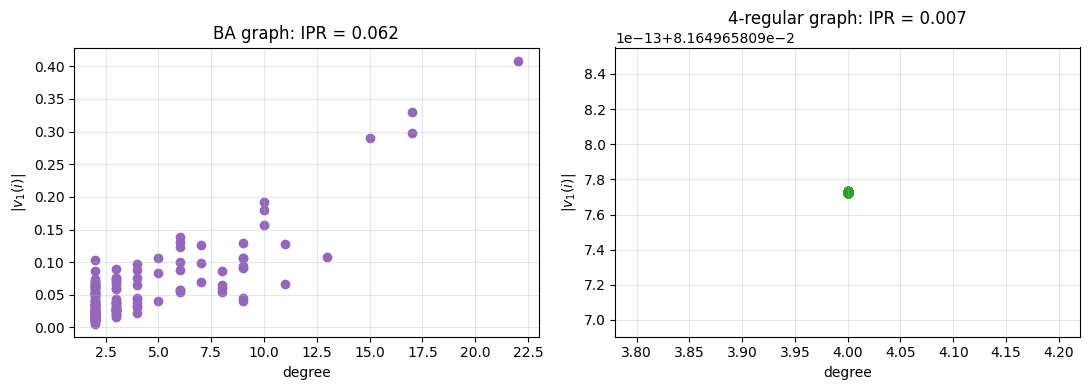

IPR on BA graph: 0.06152092292022845
IPR on 4-regular graph: 0.006666666666666668


In [44]:
G_ba = nx.barabasi_albert_graph(150, 2, seed=7)
G_rr = nx.random_regular_graph(d=4, n=150, seed=7)

A_ba, nodes_ba = adjacency_sparse(G_ba)
A_rr, nodes_rr = adjacency_sparse(G_rr)

vals_ba, vecs_ba = eigsh_sorted(A_ba, k=2, which="LA")
vals_rr, vecs_rr = eigsh_sorted(A_rr, k=2, which="LA")

v_ba = normalize_sign(vecs_ba[:, -1])
v_rr = normalize_sign(vecs_rr[:, -1])

ipr_ba = inverse_participation_ratio(v_ba)
ipr_rr = inverse_participation_ratio(v_rr)

deg_ba = np.array([G_ba.degree(u) for u in nodes_ba], dtype=float)
deg_rr = np.array([G_rr.degree(u) for u in nodes_rr], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

axes[0].scatter(deg_ba, np.abs(v_ba), color="tab:purple")
axes[0].set_xlabel("degree")
axes[0].set_ylabel(r"$|v_1(i)|$")
axes[0].set_title(f"BA graph: IPR = {ipr_ba:.3f}")
axes[0].grid(alpha=0.3)

axes[1].scatter(deg_rr, np.abs(v_rr), color="tab:green")
axes[1].set_xlabel("degree")
axes[1].set_ylabel(r"$|v_1(i)|$")
axes[1].set_title(f"4-regular graph: IPR = {ipr_rr:.3f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("IPR on BA graph:", ipr_ba)
print("IPR on 4-regular graph:", ipr_rr)


## 6. Algebraic connectivity, Fiedler vectors, and cuts

The next major idea is that the second-smallest Laplacian eigenvalue and its eigenvector reveal whether a graph has a bottleneck.

This is one of the most useful moments in all of spectral graph theory. A combinatorial question about graph partitioning is turned into a continuous optimization problem, and the solution of the relaxed problem is an eigenvector.

Fiedler's classic work established the central role of the second Laplacian eigenvalue, now called algebraic connectivity. Modern clustering and cut-based methods build directly on that foundation.

### 6.1 The Fiedler vector on a graph with a visible bottleneck

For the combinatorial Laplacian $L$, the second-smallest eigenvalue $\lambda_2(L)$ is called the algebraic connectivity. The associated eigenvector is often called the Fiedler vector.

Why "second-smallest"? Because the smallest eigenvalue is always $0$ with eigenvector $\mathbf{1}$ on each connected component. The first nontrivial mode is therefore the second one.

We start with a graph made of two cliques joined by a single bridge edge. The graph is connected, but only barely. If the spectral story is working, the Fiedler vector should assign similar values inside each clique and opposite signs across the bridge. That is the signature of a slow, bottleneck-controlled mode.

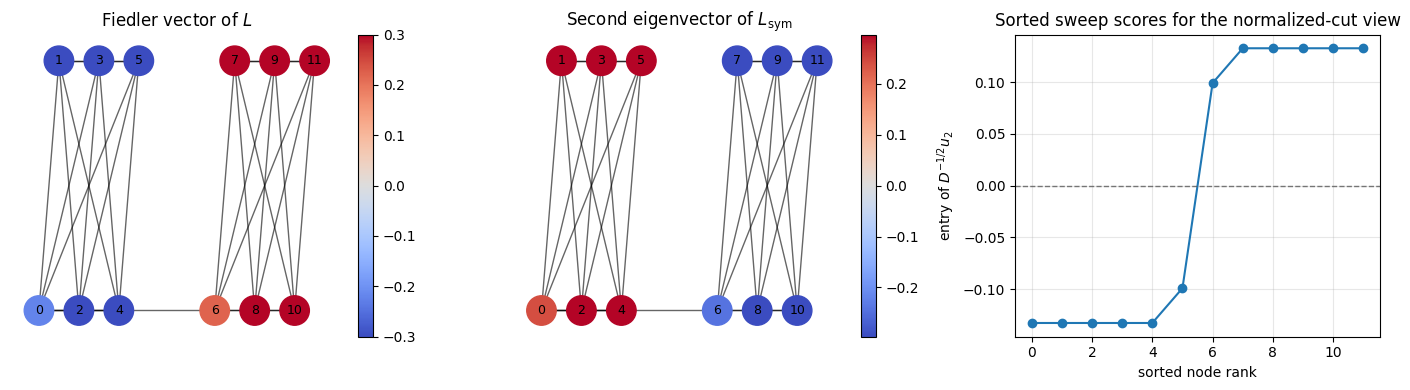

lambda_2(L) = 0.25834261322606134
lambda_2(L_sym) = 0.050658236796589574


,fiedler_L,fiedler_Lsym,$D^{-1/2} u_2$,sign partition
0,-0.222607,0.242924,0.099173,1
1,-0.300149,0.296981,0.132814,1
2,-0.300149,0.296981,0.132814,1
3,-0.300149,0.296981,0.132814,1
4,-0.300149,0.296981,0.132814,1
5,-0.300149,0.296981,0.132814,1
6,0.222607,-0.242924,-0.099173,0
7,0.300149,-0.296981,-0.132814,0
8,0.300149,-0.296981,-0.132814,0
9,0.300149,-0.296981,-0.132814,0


In [45]:
G_bridge = nx.disjoint_union(nx.complete_graph(6), nx.complete_graph(6))
G_bridge.add_edge(0, 6)

A_bridge, nodes_bridge = adjacency_dense(G_bridge)
L_bridge = laplacian_from_adjacency(A_bridge)
Lsym_bridge = normalized_laplacian_sym(A_bridge)

vals_L_bridge, vecs_L_bridge = eigh_sorted(L_bridge)
vals_Lsym_bridge, vecs_Lsym_bridge = eigh_sorted(Lsym_bridge)

fiedler_L = normalize_sign(vecs_L_bridge[:, 1])
fiedler_Lsym = normalize_sign(vecs_Lsym_bridge[:, 1])

degrees_bridge = degree_vector_from_adjacency(A_bridge)
sweep_scores = safe_inv_sqrt(degrees_bridge) * fiedler_Lsym
cluster_sign = (sweep_scores >= 0).astype(int)

pos_bridge = {}
pos_bridge.update({i: (-1.1 + 0.25 * i, 0.1 * (i % 2)) for i in range(6)})
pos_bridge.update({i + 6: (1.1 + 0.25 * i, 0.1 * (i % 2)) for i in range(6)})

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=100)

draw_graph(G_bridge, axes[0], pos=pos_bridge, values=fiedler_L, title=r"Fiedler vector of $L$", with_labels=True, cmap="coolwarm")
draw_graph(G_bridge, axes[1], pos=pos_bridge, values=fiedler_Lsym, title=r"Second eigenvector of $L_{\mathrm{sym}}$", with_labels=True, cmap="coolwarm")
axes[2].plot(np.sort(sweep_scores), marker="o", color="tab:blue")
axes[2].axhline(0, linewidth=1, color="0.35", linestyle="--", alpha=0.8)
axes[2].set_xlabel("sorted node rank")
axes[2].set_ylabel(r"entry of $D^{-1/2} u_2$")
axes[2].set_title("Sorted sweep scores for the normalized-cut view")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("lambda_2(L) =", vals_L_bridge[1])
print("lambda_2(L_sym) =", vals_Lsym_bridge[1])

display(pd.DataFrame({
    "fiedler_L": fiedler_L,
    "fiedler_Lsym": fiedler_Lsym,
    r"$D^{-1/2} u_2$": sweep_scores,
    "sign partition": cluster_sign,
}, index=nodes_bridge))


### 6.2 What changes when the graph disconnects?

If we remove the bridge edge, the graph becomes disconnected. The spectral signature changes immediately.

The multiplicity of the eigenvalue $0$ increases from one to two. The "best" way to keep the quadratic form small is now to be constant on each connected component separately. There is no penalty for assigning different constants to different components because no edge connects them.

This is why disconnected graphs are a special case for clustering: the components are already perfect cuts. Spectrally, the graph is not merely *close* to being separable; it is exactly separable.

In [46]:
G_bridge_removed = G_bridge.copy()
G_bridge_removed.remove_edge(0, 6)

A_removed, nodes_removed = adjacency_dense(G_bridge_removed)
L_removed = laplacian_from_adjacency(A_removed)
vals_removed, vecs_removed = eigh_sorted(L_removed)

zero_mult_removed = np.sum(np.isclose(vals_removed, 0.0, atol=1e-10))

print("Smallest eigenvalues after removing the bridge:", np.round(vals_removed[:5], 6))
print("Multiplicity of 0:", zero_mult_removed)

assert zero_mult_removed == 2


Smallest eigenvalues after removing the bridge: [0. 0. 6. 6. 6.]
Multiplicity of 0: 2


### 6.3 Rayleigh quotient: the optimization view

For a symmetric matrix $M$ and a nonzero vector $x$, the Rayleigh quotient is

$$
R_M(x) = \frac{x^\top M x}{x^\top x}.
$$

For the Laplacian, this becomes

$$
R_L(x) = \frac{x^\top L x}{x^\top x}.
$$

The numerator measures edge disagreement, while the denominator normalizes by signal size. The Courant-Fischer theorem says that the eigenvalues of a symmetric matrix can be characterized as extrema of Rayleigh quotients.

For the combinatorial Laplacian, the key constrained problem is

$$
\lambda_2(L)
=
\min_{x \neq 0,\; x^\top \mathbf{1}=0}
\frac{x^\top L x}{x^\top x}.
$$

The constraint $x^\top \mathbf{1}=0$ removes the trivial constant direction. What remains is the smoothest non-constant signal on the graph. That is the optimization origin of the Fiedler vector, and it is the bridge from combinatorial cuts to continuous linear algebra.

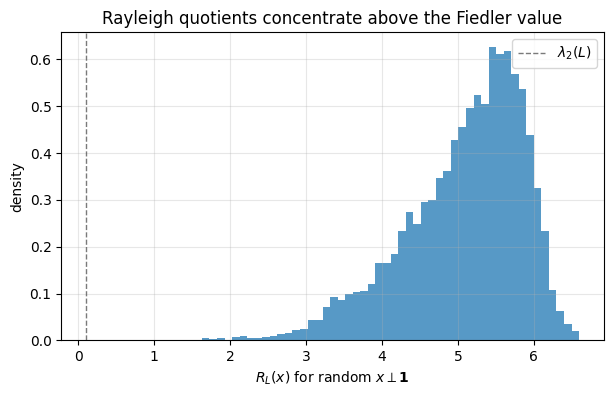

lambda_2(L) = 0.09994745279998951
Minimum sampled Rayleigh quotient = 1.6273955220973684


In [47]:
G_ray = nx.barbell_graph(6, 2)
A_ray, _ = adjacency_dense(G_ray)
L_ray = laplacian_from_adjacency(A_ray)
vals_ray, _ = eigh_sorted(L_ray)

samples = 4000
rq = []
for _ in range(samples):
    z = rng.normal(size=L_ray.shape[0])
    z = z - z.mean()   # enforce orthogonality to the constant vector
    rq.append((z @ (L_ray @ z)) / (z @ z))
rq = np.array(rq)

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=100)
ax.hist(rq, bins=50, density=True, color="tab:blue", alpha=0.75)
ax.axvline(vals_ray[1], linewidth=1, color="0.35", linestyle="--", alpha=0.8, label=r"$\lambda_2(L)$")
ax.set_xlabel(r"$R_L(x)$ for random $x \perp \mathbf{1}$")
ax.set_ylabel("density")
ax.set_title("Rayleigh quotients concentrate above the Fiedler value")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

print("lambda_2(L) =", vals_ray[1])
print("Minimum sampled Rayleigh quotient =", rq.min())


### 6.4 Conductance, sweep cuts, and Cheeger-style intuition

Up to this point we used the combinatorial Laplacian $L$ because it makes the optimization story especially transparent. For conductance and normalized cuts, however, the more natural operator is the symmetric normalized Laplacian $L_{\mathrm{sym}}$. The degree factors matter: without them, high-degree regions can dominate the objective simply because they contain more edges.

A cut is a partition of the nodes into a nonempty set $S$ and its complement $\bar S$. One standard quality measure is the conductance

$$
\phi(S) = \frac{\mathrm{cut}(S,\bar S)}{\min(\mathrm{vol}(S), \mathrm{vol}(\bar S))},
$$

where:

- $\mathrm{cut}(S,\bar S)$ is the number of edges crossing the cut,
- $\mathrm{vol}(S)$ is the sum of degrees of nodes in $S$.

Small conductance means there are relatively few edges crossing compared with the volume on either side. That is exactly the bottleneck notion we want for community-like structure.

For the normalized Laplacian, Cheeger-type results connect $\lambda_2(L_{\mathrm{sym}})$ to the best achievable conductance. A common form is

$$
\frac{\lambda_2(L_{\mathrm{sym}})}{2}
\le
\phi_G
\le
\sqrt{2 \lambda_2(L_{\mathrm{sym}})},
$$

where $\phi_G$ is the minimum conductance over all nontrivial cuts. The theorem is not saying that the eigenvector solves the discrete cut problem exactly. It is saying that a small second normalized eigenvalue certifies the existence of a good bottleneck, and the corresponding eigenvector gives a principled direction from which to search for one.

For the normalized Laplacian, the standard sweep is applied to the degree-rescaled scores $D^{-1/2} u_2$, not directly to the raw entries of $u_2$. That rescaling is what aligns the continuous relaxation with normalized-cut objectives. Chung (1997), Spielman (2019), and von Luxburg (2007) are especially good references for this bridge.

To turn a Fiedler-type score vector into an actual cut, we need one more helper: conductance and the sweep procedure that checks threshold cuts in sorted order.

In [48]:
def conductance(G, S):
    """Conductance of a nontrivial cut S."""
    S = set(S)
    T = set(G.nodes()) - S
    if len(S) == 0 or len(T) == 0:
        return np.inf

    cut = 0
    for u, v in G.edges():
        if (u in S and v in T) or (u in T and v in S):
            cut += 1

    volS = sum(dict(G.degree(S)).values())
    volT = sum(dict(G.degree(T)).values())
    return cut / min(volS, volT)

def fiedler_sweep_cut(G, values, nodelist):
    """Best conductance cut obtained by sweeping thresholds on a node score vector."""
    values = np.asarray(values, dtype=float).ravel()
    order = np.argsort(values)

    best_phi = np.inf
    best_S = None
    for k in range(1, len(order)):
        S = set(np.array(nodelist)[order[:k]])
        phi = conductance(G, S)
        if phi < best_phi:
            best_phi = phi
            best_S = S
    return best_phi, best_S

G_sweep_check = nx.path_graph(4)
phi_check, S_check = fiedler_sweep_cut(G_sweep_check, np.array([-1.0, -0.5, 0.5, 1.0]), [0, 1, 2, 3])
assert np.isfinite(phi_check)
assert len(S_check) in [1, 2, 3]


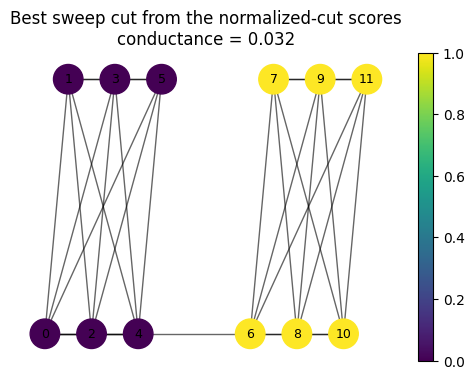

lambda_2(L_sym) = 0.050658236796589574
Cheeger lower bound = 0.025329118398294787
Best sweep-cut conductance = 0.03225806451612903
Cheeger upper bound = 0.3183024875698887


In [49]:
phi_sweep, S_best = fiedler_sweep_cut(G_bridge, sweep_scores, nodes_bridge)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4), dpi=100)
draw_graph(
    G_bridge,
    ax,
    pos=pos_bridge,
    values=np.array([1 if node in S_best else 0 for node in nodes_bridge]),
    title=f"Best sweep cut from the normalized-cut scores\nconductance = {phi_sweep:.3f}",
    with_labels=True,
)
plt.show()

lower = vals_Lsym_bridge[1] / 2
upper = np.sqrt(2 * vals_Lsym_bridge[1])

print("lambda_2(L_sym) =", vals_Lsym_bridge[1])
print("Cheeger lower bound =", lower)
print("Best sweep-cut conductance =", phi_sweep)
print("Cheeger upper bound =", upper)

assert lower <= phi_sweep + 1e-10


The word *sweep* can sound more mysterious than it is. We sort the nodes by the score vector, inspect every prefix of that ordering as a candidate set $S$, and compute the conductance of each resulting cut.

So the spectral vector is giving us an ordering, not the final answer by itself. The best threshold along that ordering is the cut we keep.

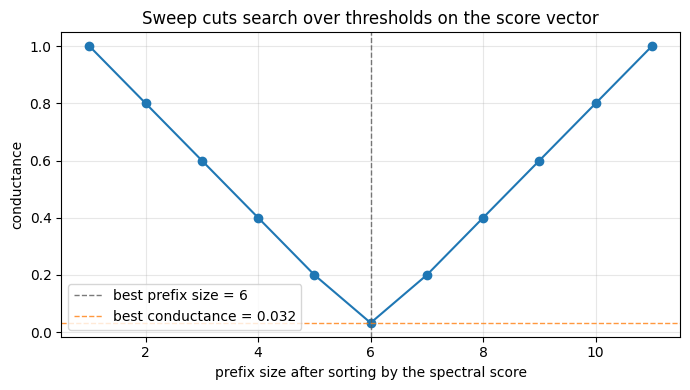

,prefix size,conductance
0,1,1.0000
1,2,0.8000
2,3,0.6000
3,4,0.4000
4,5,0.2000
5,6,0.0323
6,7,0.2000
7,8,0.4000
8,9,0.6000
9,10,0.8000


In [50]:
order_sweep = np.argsort(sweep_scores)
prefix_sizes = np.arange(1, len(order_sweep))
phi_profile = []

for k in prefix_sizes:
    S_k = set(np.array(nodes_bridge)[order_sweep[:k]])
    phi_profile.append(conductance(G_bridge, S_k))

phi_profile = np.array(phi_profile)
k_best = prefix_sizes[np.argmin(phi_profile)]

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=100)
ax.plot(prefix_sizes, phi_profile, marker="o")
ax.axvline(k_best, color="0.35", linestyle="--", linewidth=1, alpha=0.8, label=f"best prefix size = {k_best}")
ax.axhline(phi_sweep, color="tab:orange", linestyle="--", linewidth=1, alpha=0.8, label=f"best conductance = {phi_sweep:.3f}")
ax.set_xlabel("prefix size after sorting by the spectral score")
ax.set_ylabel("conductance")
ax.set_title("Sweep cuts search over thresholds on the score vector")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "prefix size": prefix_sizes,
    "conductance": phi_profile,
}).round(4))

assert np.isclose(phi_profile.min(), phi_sweep)

### 6.5 As the bridge strengthens, the community signal weakens

A single bridge edge makes the two cliques look like extremely clear communities. If we gradually add more cross edges, the conductance should go up, the second normalized Laplacian eigenvalue $\lambda_2(L_{\mathrm{sym}})$ should go up, and the lazy random-walk gap should go up as well. In plain language, once information can cross more easily, the two sides stop behaving like almost-separate communities.

In [51]:
def two_cliques_with_bridges(size=6, n_bridges=1):
    """Two cliques joined by a deterministic set of evenly spread cross edges."""
    if n_bridges < 1 or n_bridges > size * size:
        raise ValueError("n_bridges must be between 1 and size^2")

    G = nx.disjoint_union(nx.complete_graph(size), nx.complete_graph(size))
    left = list(range(size))
    right = list(range(size, 2 * size))

    candidate_pairs = []
    for shift in range(size):
        for u in left:
            v = size + ((u + shift) % size)
            candidate_pairs.append((u, v))

    for u, v in candidate_pairs[:n_bridges]:
        G.add_edge(u, v)

    return G, left, right

G_bridge_strength_check, left_check, right_check = two_cliques_with_bridges(size=4, n_bridges=3)
assert G_bridge_strength_check.number_of_nodes() == 8
assert nx.is_connected(G_bridge_strength_check)

In [52]:
bridge_counts = [1, 2, 4, 6, 9, 12, 18]
bridge_rows = []

for b in bridge_counts:
    G_b, left_b, right_b = two_cliques_with_bridges(size=6, n_bridges=b)
    A_b, _ = adjacency_dense(G_b)

    Lsym_b = normalized_laplacian_sym(A_b)
    lam2_b = np.linalg.eigvalsh(Lsym_b)[1]

    P_lazy_b = 0.5 * np.eye(A_b.shape[0]) + 0.5 * random_walk_matrix(A_b)
    eig_lazy_b = np.sort(np.real_if_close(np.linalg.eigvals(P_lazy_b)))[::-1]
    gap_b = 1.0 - eig_lazy_b[1]

    phi_b = conductance(G_b, left_b)

    bridge_rows.append({
        "cross edges": b,
        "conductance of true cut": phi_b,
        r"$\lambda_2(L_{\mathrm{sym}})$": lam2_b,
        "lazy-walk gap": gap_b,
        r"$\lambda_2(L_{\mathrm{sym}})/2$": lam2_b / 2.0,
    })

bridge_df = pd.DataFrame(bridge_rows)
display(bridge_df.round(4))

assert np.allclose(bridge_df["lazy-walk gap"], bridge_df[r"$\lambda_2(L_{\mathrm{sym}})/2$"], atol=1e-10)

,cross edges,conductance of true cut,$\lambda_2(L_{\mathrm{sym}})$,lazy-walk gap,$\lambda_2(L_{\mathrm{sym}})/2$
0,1,0.0323,0.0507,0.0253,0.0253
1,2,0.0625,0.1028,0.0514,0.0514
2,4,0.1176,0.2127,0.1063,0.1063
3,6,0.1667,0.3333,0.1667,0.1667
4,9,0.2308,0.4437,0.2219,0.2219
5,12,0.2857,0.5714,0.2857,0.2857
6,18,0.3750,0.7500,0.3750,0.3750


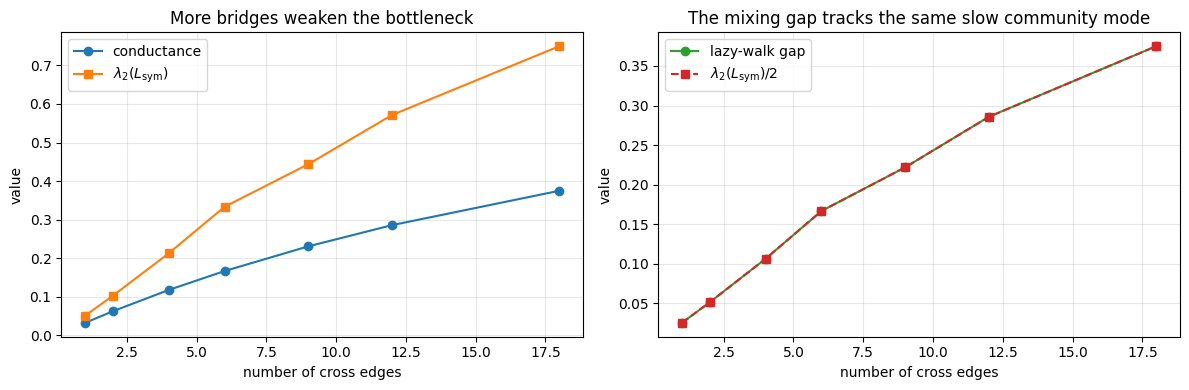

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100)

axes[0].plot(
    bridge_df["cross edges"],
    bridge_df["conductance of true cut"],
    marker="o",
    color="tab:blue",
    label="conductance",
)
axes[0].plot(
    bridge_df["cross edges"],
    bridge_df[r"$\lambda_2(L_{\mathrm{sym}})$"],
    marker="s",
    color="tab:orange",
    label=r"$\lambda_2(L_{\mathrm{sym}})$",
)
axes[0].set_xlabel("number of cross edges")
axes[0].set_ylabel("value")
axes[0].set_title("More bridges weaken the bottleneck")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    bridge_df["cross edges"],
    bridge_df["lazy-walk gap"],
    marker="o",
    color="tab:green",
    label="lazy-walk gap",
)
axes[1].plot(
    bridge_df["cross edges"],
    bridge_df[r"$\lambda_2(L_{\mathrm{sym}})/2$"],
    marker="s",
    linestyle="--",
    color="tab:red",
    label=r"$\lambda_2(L_{\mathrm{sym}})/2$",
)
axes[1].set_xlabel("number of cross edges")
axes[1].set_ylabel("value")
axes[1].set_title("The mixing gap tracks the same slow community mode")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The same story is now visible three ways. More cross edges mean larger conductance, larger $\lambda_2(L_{\mathrm{sym}})$, and a larger lazy-walk gap. The community boundary has not disappeared, but it has become less effective at trapping diffusion or random-walk mass.

### Your turn!

Before you run the next cell, predict what happens to $\lambda_2(L)$ when the bridge between the two cliques is removed. Does it increase, decrease, or hit zero?

Then connect the answer back to the cut picture: what does a zero second eigenvalue mean about the graph?


## 7. Random walks, diffusion, and spectral gap

So far we have treated graph matrices as static operators. Now we turn them into dynamics.

Two closely related pictures matter most.

- Discrete-time random walks use the matrix $P = D^{-1} A$.
- Continuous-time diffusion and consensus use the Laplacian through the differential equation $dx/dt = -Lx$.

These are not separate stories. They are two dialects for talking about how network structure controls the decay of imbalances. The same slow mode can show up as a bottleneck, a slow mixing direction, a diffusion mode, or a low graph frequency depending on which operator is in the foreground.

### 7.1 The random-walk matrix and the stationary distribution

For a graph with adjacency matrix $A$ and degree matrix $D$, the random-walk matrix is

$$
P = D^{-1} A.
$$

The $i$th row of $P$ gives the probabilities of moving from node $i$ to its neighbors in one step. In our notebook we use **row vectors** for distributions, so the evolution equation is

$$
p_{t+1} = p_t P.
$$

Many texts use column vectors instead and write $p_{t+1} = P^\top p_t$. The Markov chain is the same; only the bookkeeping convention changes.

For an undirected connected graph, the stationary distribution is

$$
\pi_i = \frac{d_i}{2m},
$$

where $d_i$ is the degree of node $i$ and $m$ is the number of edges. High-degree nodes hold more stationary mass because the random walk arrives at them more often. Lovász (1993) is a classic reference for this viewpoint.

In [55]:
G_rw = nx.Graph()
G_rw.add_edges_from([(0, 1), (0, 2), (0, 3), (3, 4), (4, 5)])

A_rw, nodes_rw = adjacency_dense(G_rw)
P_rw = random_walk_matrix(A_rw)
degrees_rw = degree_vector_from_adjacency(A_rw)
pi_rw = degrees_rw / degrees_rw.sum()

assert np.allclose(P_rw.sum(axis=1), 1.0)
assert np.allclose(pi_rw @ P_rw, pi_rw)

show_matrix_df(np.round(P_rw, 3), name="Random-walk matrix P", index=nodes_rw, columns=nodes_rw)
display(pd.DataFrame({"degree": degrees_rw, "stationary probability": np.round(pi_rw, 4)}, index=nodes_rw))


Random-walk matrix P


,0,1,2,3,4,5
0,0.0,0.333,0.333,0.333,0.0,0.0
1,1.0,0.000,0.000,0.000,0.0,0.0
2,1.0,0.000,0.000,0.000,0.0,0.0
3,0.5,0.000,0.000,0.000,0.5,0.0
4,0.0,0.000,0.000,0.500,0.0,0.5
5,0.0,0.000,0.000,0.000,1.0,0.0


,degree,stationary probability
0,3.0,0.3
1,1.0,0.1
2,1.0,0.1
3,2.0,0.2
4,2.0,0.2
5,1.0,0.1


A transition matrix becomes much less mysterious once we push an actual probability vector through it. We start at node $0$ with probability $1$ and watch the mass spread.

In [56]:
p0 = np.zeros(len(nodes_rw))
p0[0] = 1.0
p1 = p0 @ P_rw
p2 = p1 @ P_rw
p3 = p2 @ P_rw

walk_df = pd.DataFrame(
    [p0, p1, p2, p3],
    index=["t = 0", "t = 1", "t = 2", "t = 3"],
    columns=nodes_rw,
)

display(walk_df.round(3))

assert np.allclose(walk_df.sum(axis=1).values, 1.0)

,0,1,2,3,4,5
t = 0,1.000,0.000,0.000,0.000,0.000,0.000
t = 1,0.000,0.333,0.333,0.333,0.000,0.000
t = 2,0.833,0.000,0.000,0.000,0.167,0.000
t = 3,0.000,0.278,0.278,0.361,0.000,0.083


The table keeps the probabilities exact, but a picture makes the motion easier to read. Each panel below colors the same graph by the probability mass at one time step.

We are not following one walker. We are following the whole probability distribution as it spreads across the network.

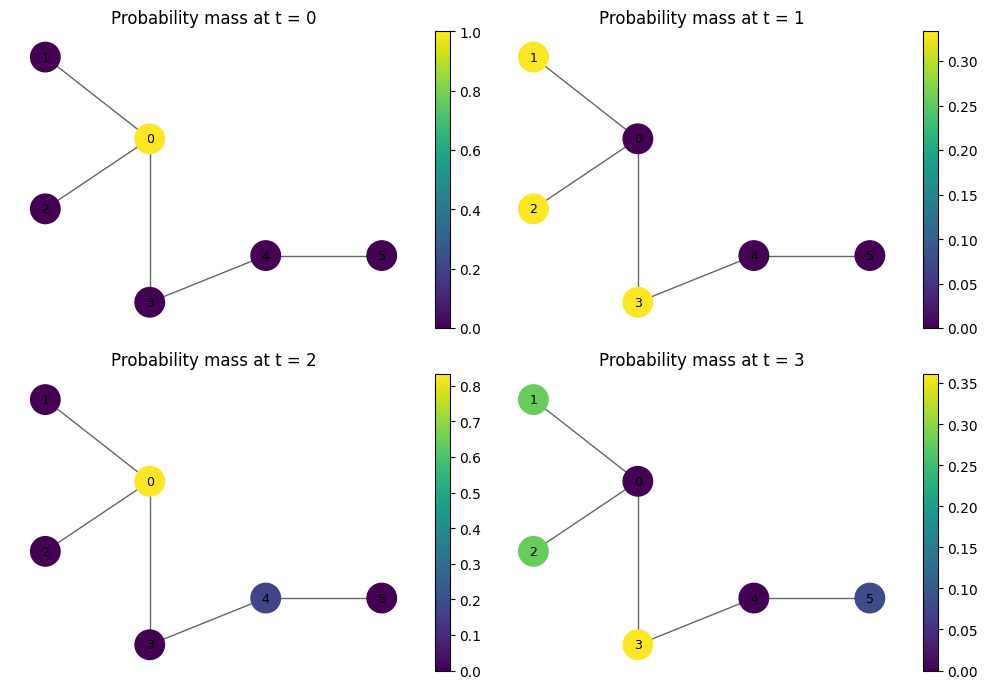

In [57]:
pos_rw = {
    0: (0.0, 0.4),
    1: (-0.9, 1.1),
    2: (-0.9, -0.2),
    3: (0.0, -1.0),
    4: (1.0, -0.6),
    5: (2.0, -0.6),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=100)
for ax, p, label in zip(
    axes.ravel(),
    [p0, p1, p2, p3],
    ["t = 0", "t = 1", "t = 2", "t = 3"],
):
    draw_graph(
        G_rw,
        ax,
        pos=pos_rw,
        values=p,
        title=f"Probability mass at {label}",
        with_labels=True,
        cmap="viridis",
    )

plt.tight_layout()
plt.show()

Each row is a full probability distribution over nodes. A single step does not produce one path; it produces a distribution over all possible next locations. Matrix powers package those repeated updates into the formula $p_t = p_0 P^t$.

There is also a local reason the stationary distribution is degree-proportional. In an undirected graph the walk is reversible:

$$
\pi_i P_{ij} = \pi_j P_{ji}.
$$

Both sides represent the stationary flow across the undirected edge $\{i,j\}$. This detailed-balance identity is the short algebraic expression of the intuitive statement "in equilibrium, the flow across every undirected edge balances in both directions."

In [58]:
node_to_i_rw = {u: i for i, u in enumerate(nodes_rw)}
flow_rows = []
for u, v in G_rw.edges():
    i = node_to_i_rw[u]
    j = node_to_i_rw[v]
    flow_uv = pi_rw[i] * P_rw[i, j]
    flow_vu = pi_rw[j] * P_rw[j, i]
    flow_rows.append({
        "edge": f"{u}-{v}",
        r"$\pi_i P_{ij}$": flow_uv,
        r"$\pi_j P_{ji}$": flow_vu,
    })
    assert np.isclose(flow_uv, flow_vu)

display(pd.DataFrame(flow_rows).round(4))
assert np.allclose(pi_rw @ P_rw, pi_rw)

,edge,$\pi_i P_{ij}$,$\pi_j P_{ji}$
0,0-1,0.1,0.1
1,0-2,0.1,0.1
2,0-3,0.1,0.1
3,3-4,0.1,0.1
4,4-5,0.1,0.1


So the degree formula is not magic. A node with twice as many incident edges receives twice as much stationary flow in the reversible equilibrium picture.

### 7.2 Spectral gap and mixing

The basic intuition is simple. If a graph has a strong bottleneck, a random walk can get stuck on one side for a long time. If the graph is expander-like, the walk forgets its starting point much faster.

To compare graphs fairly, it is common to use a lazy random walk

$$
P_{\mathrm{lazy}} = \frac{1}{2} I + \frac{1}{2} P,
$$

which removes periodicity issues such as the back-and-forth oscillation on bipartite graphs. For a connected undirected graph, $P_{\mathrm{lazy}}$ has largest eigenvalue $1$, and all of its eigenvalues lie in $[0, 1]$.

That is why the random-walk spectral gap is usually defined as

$$
\gamma = 1 - \mu_2(P_{\mathrm{lazy}}),
$$

where $\mu_2(P_{\mathrm{lazy}})$ is the second-largest eigenvalue of the lazy walk. A larger gap means every leftover imbalance decays faster. A smaller gap means there is an almost-conserved large-scale pattern, which is usually a sign of a bottleneck.

Another useful phrase is relaxation time. Very roughly, the slowest mode decays on a time scale of order $1 / \gamma$. So gap up means relaxation time down.

For an undirected graph, $P = D^{-1} A$ is similar to the symmetric matrix $D^{-1/2} A D^{-1/2}$, so it has real eigenvalues even though $P$ itself is usually not symmetric. In that sense, the random-walk picture and the normalized-Laplacian picture are describing the same slow bottleneck mode in two different coordinate systems. Lovász (1993), Doyle and Snell (1984), and Levin, Peres, and Wilmer (2017) are standard references for this viewpoint.

We compare a path graph to a random regular graph. The path has an obvious bottleneck geometry. The random regular graph is much more expansion-like.

A smallest-possible example shows why laziness matters. On a single edge, the ordinary walk never settles down: it flips sides forever.

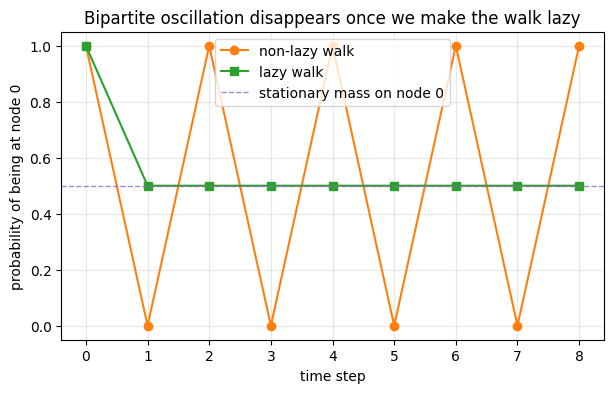

Eigenvalues of the non-lazy walk: [ 1. -1.]
Eigenvalues of the lazy walk:     [1. 0.]


In [59]:
G_edge = nx.path_graph(2)
A_edge, nodes_edge = adjacency_dense(G_edge)
P_edge = random_walk_matrix(A_edge)
P_edge_lazy = 0.5 * np.eye(P_edge.shape[0]) + 0.5 * P_edge

p_non = np.array([1.0, 0.0])
p_lazy = np.array([1.0, 0.0])

prob0_non = [p_non[0]]
prob0_lazy = [p_lazy[0]]

for _ in range(8):
    p_non = p_non @ P_edge
    p_lazy = p_lazy @ P_edge_lazy
    prob0_non.append(p_non[0])
    prob0_lazy.append(p_lazy[0])

eig_non = np.sort(np.real_if_close(np.linalg.eigvals(P_edge)))[::-1]
eig_lazy = np.sort(np.real_if_close(np.linalg.eigvals(P_edge_lazy)))[::-1]

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=100)
ax.plot(range(len(prob0_non)), prob0_non, marker="o", color="tab:orange", label="non-lazy walk")
ax.plot(range(len(prob0_lazy)), prob0_lazy, marker="s", color="tab:green", label="lazy walk")
ax.axhline(0.5, color="tab:purple", linestyle="--", linewidth=1, alpha=0.8, label="stationary mass on node 0")
ax.set_xlabel("time step")
ax.set_ylabel("probability of being at node 0")
ax.set_title("Bipartite oscillation disappears once we make the walk lazy")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

print("Eigenvalues of the non-lazy walk:", np.round(eig_non, 4))
print("Eigenvalues of the lazy walk:    ", np.round(eig_lazy, 4))

assert np.allclose(eig_non, np.array([1.0, -1.0]))
assert np.allclose(eig_lazy, np.array([1.0, 0.0]))

The non-lazy walk never forgets its parity because the second eigenvalue is $-1$. The lazy walk replaces that oscillatory mode by $0$, so the leftover imbalance can actually contract toward stationarity.

The next helper block packages two random-walk routines: the lazy-walk transformation and a total-variation diagnostic for convergence to stationarity.

In [60]:
def make_lazy(P, beta=0.5):
    """Lazy random walk matrix beta I + (1-beta) P."""
    n = P.shape[0]
    if sp.issparse(P):
        return beta * sp.eye(n, format="csr") + (1.0 - beta) * P
    return beta * np.eye(n) + (1.0 - beta) * P

def random_walk_tv_distances(G, start, T=40, lazy=True):
    """Total-variation distance to stationarity over time."""
    A, nodes = adjacency_sparse(G)
    P = random_walk_matrix(A)
    if lazy:
        P = make_lazy(P, beta=0.5)

    d = np.asarray(A.sum(axis=1)).ravel()
    pi = d / d.sum()

    node_to_i = {u: i for i, u in enumerate(nodes)}
    p = np.zeros(len(nodes))
    p[node_to_i[start]] = 1.0

    tv = [0.5 * np.sum(np.abs(p - pi))]
    for _ in range(T):
        p = p @ P
        tv.append(0.5 * np.sum(np.abs(p - pi)))
    return np.array(tv), pi

A_rw_check = sp.csr_matrix(np.array([[0.0, 1.0], [1.0, 0.0]]))
P_rw_check = random_walk_matrix(A_rw_check)
P_lazy_check = make_lazy(P_rw_check)
assert np.allclose(P_lazy_check.toarray().sum(axis=1), 1.0)


In [61]:
G_path80 = nx.path_graph(80)

seed_rr = 11
G_rr80 = nx.random_regular_graph(d=4, n=80, seed=seed_rr)
while not nx.is_connected(G_rr80):
    seed_rr += 1
    G_rr80 = nx.random_regular_graph(d=4, n=80, seed=seed_rr)

tv_path, _ = random_walk_tv_distances(G_path80, start=0, T=50, lazy=True)
tv_rr, _ = random_walk_tv_distances(G_rr80, start=0, T=50, lazy=True)

A_path80, _ = adjacency_sparse(G_path80)
A_rr80, _ = adjacency_sparse(G_rr80)

P_path_lazy = make_lazy(random_walk_matrix(A_path80))
P_rr_lazy = make_lazy(random_walk_matrix(A_rr80))

vals_path_lazy = np.linalg.eigvals(P_path_lazy.toarray())
vals_rr_lazy = np.linalg.eigvals(P_rr_lazy.toarray())

eig_path_lazy = np.sort(np.real_if_close(vals_path_lazy))[::-1]
eig_rr_lazy = np.sort(np.real_if_close(vals_rr_lazy))[::-1]

gap_path = 1.0 - eig_path_lazy[1]
gap_rr = 1.0 - eig_rr_lazy[1]

assert np.isclose(eig_path_lazy[0], 1.0)
assert np.isclose(eig_rr_lazy[0], 1.0)
assert gap_rr > gap_path

gap_summary = pd.DataFrame({
    "graph": ["path", "4-regular random graph"],
    r"$\mu_1(P_{\mathrm{lazy}})$": [eig_path_lazy[0], eig_rr_lazy[0]],
    r"$\mu_2(P_{\mathrm{lazy}})$": [eig_path_lazy[1], eig_rr_lazy[1]],
    r"spectral gap $1 - \mu_2$": [gap_path, gap_rr],
    r"rough time scale $1 / (1 - \mu_2)$": [1.0 / gap_path, 1.0 / gap_rr],
})


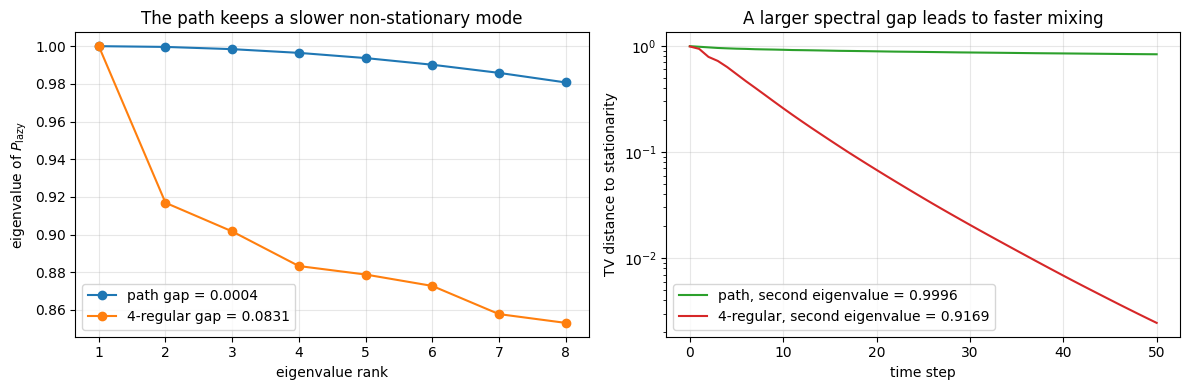

,graph,$\mu_1(P_{\mathrm{lazy}})$,$\mu_2(P_{\mathrm{lazy}})$,spectral gap $1 - \mu_2$,rough time scale $1 / (1 - \mu_2)$
0,path,1.0,0.9996,0.0004,2529.7154
1,4-regular random graph,1.0,0.9169,0.0831,12.0320


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100)

k_show = 8
axes[0].plot(np.arange(1, k_show + 1), eig_path_lazy[:k_show], marker="o", color="tab:blue", label=f"path gap = {gap_path:.4f}")
axes[0].plot(np.arange(1, k_show + 1), eig_rr_lazy[:k_show], marker="o", color="tab:orange", label=f"4-regular gap = {gap_rr:.4f}")
axes[0].set_xlabel("eigenvalue rank")
axes[0].set_ylabel(r"eigenvalue of $P_{\mathrm{lazy}}$")
axes[0].set_title("The path keeps a slower non-stationary mode")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(tv_path, color="tab:green", label=f"path, second eigenvalue = {eig_path_lazy[1]:.4f}")
axes[1].plot(tv_rr, color="tab:red", label=f"4-regular, second eigenvalue = {eig_rr_lazy[1]:.4f}")
axes[1].set_yscale("log")
axes[1].set_xlabel("time step")
axes[1].set_ylabel("TV distance to stationarity")
axes[1].set_title("A larger spectral gap leads to faster mixing")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

display(gap_summary.round(4))


On a graph with two strong communities, the same mechanism is even easier to interpret. The slow non-stationary mode is approximately positive on one community and negative on the other, so the walk spends a long time leaking mass across the sparse boundary between them. In that sense, the spectral gap is not just a mixing number: it is a dynamical measurement of how hard it is for probability mass to cross the community bottleneck.


A terminology note helps here. "Spectral gap" always depends on the operator. In this section it means the gap below eigenvalue $1$ for the lazy random-walk matrix.

For an undirected graph with no isolated nodes, the connection to the normalized Laplacian is exact:

$$
P_{\mathrm{lazy}} \sim I - \frac{1}{2} L_{\mathrm{sym}},
$$

so the eigenvalues satisfy

$$
\mu_i(P_{\mathrm{lazy}}) = 1 - \frac{1}{2}\lambda_i(L_{\mathrm{sym}}).
$$

In particular,

$$
\gamma = 1 - \mu_2(P_{\mathrm{lazy}}) = \frac{1}{2}\lambda_2(L_{\mathrm{sym}}).
$$

That is why the same bottleneck can be described either as a slow mixing mode or as a small second normalized Laplacian eigenvalue.

One terminology point is worth making explicit. For a reversible non-lazy chain, some authors define the absolute spectral gap

$$
\gamma_* = 1 - \max_{i>1} |\mu_i(P)|.
$$

That is the right version when negative eigenvalues matter, as they do on bipartite graphs. On a lazy chain every nontrivial eigenvalue already lies in $[0,1]$, so the absolute gap collapses to the simpler formula $1 - \mu_2(P_{\mathrm{lazy}})$ that we use in the main text.

A tiny comparison across graph families helps calibrate the number.

In [63]:
gap_rows = []
for name, G_gap in [
    ("path P6", nx.path_graph(6)),
    ("cycle C6", nx.cycle_graph(6)),
    ("clique K6", nx.complete_graph(6)),
]:
    A_gap, _ = adjacency_dense(G_gap)
    P_gap_lazy = make_lazy(random_walk_matrix(A_gap))
    eig_gap = np.sort(np.real_if_close(np.linalg.eigvals(P_gap_lazy)))[::-1]
    gamma_gap = 1.0 - eig_gap[1]

    Lsym_gap = normalized_laplacian_sym(A_gap)
    lam2_gap = np.linalg.eigvalsh(Lsym_gap)[1]

    gap_rows.append({
        "graph": name,
        r"$\mu_2(P_{lazy})$": eig_gap[1],
        "lazy-walk gap": gamma_gap,
        r"$\lambda_2(L_{\mathrm{sym}})$": lam2_gap,
        "rough relaxation time": 1.0 / gamma_gap,
    })

gap_df = pd.DataFrame(gap_rows)
display(gap_df.round(4))

assert gap_df.loc[gap_df["graph"] == "clique K6", "lazy-walk gap"].item() > gap_df.loc[gap_df["graph"] == "path P6", "lazy-walk gap"].item()

,graph,$\mu_2(P_{lazy})$,lazy-walk gap,$\lambda_2(L_{\mathrm{sym}})$,rough relaxation time
0,path P6,0.9045,0.0955,0.191,10.4721
1,cycle C6,0.7500,0.2500,0.500,4.0000
2,clique K6,0.4000,0.6000,1.200,1.6667


The clique has the largest gap because every node communicates with every other node immediately. The path and the cycle have much smaller gaps because probability mass must travel through a narrow one-dimensional geometry. This is the sense in which the spectral gap quantifies a bottleneck or slow mode.

### 7.3 Continuous-time diffusion and consensus

A standard linear dynamics on a graph is

$$
\frac{d x(t)}{dt} = -L x(t),
$$

where:

- $x(t) \in \mathbb{R}^n$ is a time-dependent node signal,
- $L$ is the combinatorial Laplacian,
- the minus sign drives the signal toward smoothness.

This equation can model heat diffusion, averaging, consensus among agents, and other linear smoothing processes on networks. Olfati-Saber, Fax, and Murray (2007) give a broad systems perspective on consensus dynamics.

The exact solution is

$$
x(t) = e^{-tL} x(0),
$$

where $x(0)$ is the initial condition and $e^{-tL}$ is the matrix exponential.

Because we are using the combinatorial Laplacian on an undirected connected graph, the long-time limit is the ordinary arithmetic average of the initial signal. If we changed the operator to a normalized Laplacian, the preserved quantity would change as well.

The next cell defines two diffusion solvers: one exact (via the matrix exponential) and one approximate (forward Euler). We will compare them momentarily.

In [64]:
def diffusion_exact(L, x0, t):
    """Exact diffusion x(t) = exp(-tL) x(0) on a small graph."""
    return la.expm(-t * L) @ x0


def diffusion_euler(L, x0, dt, steps):
    """Forward-Euler diffusion trajectory."""
    x = np.asarray(x0, dtype=float).copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - dt * (L @ x)
        traj.append(x.copy())
    return np.array(traj)


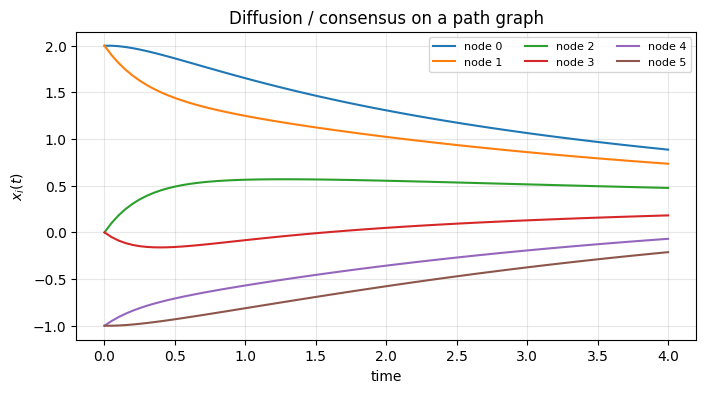

Euler approximation at final time: [ 0.8868  0.7355  0.4764  0.182  -0.0688 -0.2119]
Exact solution at final time:       [ 0.8912  0.7384  0.477   0.1805 -0.0717 -0.2154]
Final discrepancy: 0.007218160675189264


In [65]:
G_diff = G_path6
A_diff, nodes_diff = adjacency_dense(G_diff)
L_diff = laplacian_from_adjacency(A_diff)

x0 = np.array([2, 2, 0, 0, -1, -1], dtype=float)
t_end = 4.0
dt = 0.05
steps = int(t_end / dt)
times = np.linspace(0, t_end, steps + 1)

traj = diffusion_euler(L_diff, x0, dt=dt, steps=steps)
traj_exact = np.array([diffusion_exact(L_diff, x0, t) for t in times])

fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=100)
line_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
for i in range(len(nodes_diff)):
    ax.plot(times, traj[:, i], color=line_colors[i], label=f"node {i}")
ax.set_xlabel("time")
ax.set_ylabel(r"$x_i(t)$")
ax.set_title("Diffusion / consensus on a path graph")
ax.grid(alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.show()

print("Euler approximation at final time:", np.round(traj[-1], 4))
print("Exact solution at final time:      ", np.round(traj_exact[-1], 4))
print("Final discrepancy:", np.linalg.norm(traj[-1] - traj_exact[-1]))


Two first checks make the diffusion equation easier to trust.

The first is conservation of total mass. Because $L\mathbf{1}=0$, the sum of the entries of $x(t)$ should stay constant. The second is the long-time limit: on a connected graph the signal should relax to the constant vector whose value is the initial average.

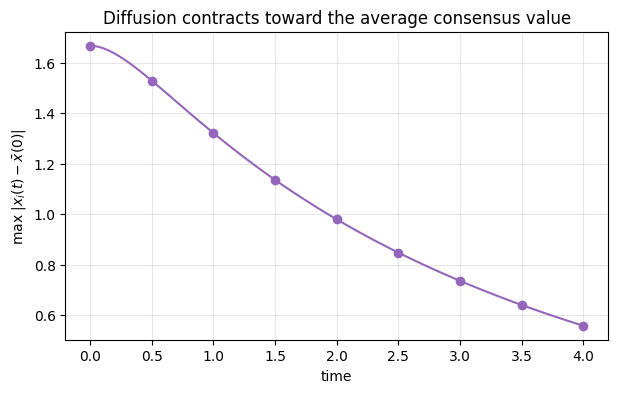

Initial total mass: 2.0
Final total mass from Euler trajectory: 2.0
Average consensus value: 0.333333
State at t = 60: [0.3333 0.3333 0.3333 0.3333 0.3333 0.3333]


In [66]:
ones_diff = np.ones(len(nodes_diff))
mass_over_time = traj.sum(axis=1)
consensus_level = x0.mean()
x_long = diffusion_exact(L_diff, x0, 60.0)

assert np.allclose(L_diff @ ones_diff, 0.0)
assert np.allclose(mass_over_time, x0.sum(), atol=1e-10)
assert np.allclose(x_long, consensus_level * np.ones_like(x0), atol=1e-4)

dev_exact = np.max(np.abs(traj_exact - consensus_level), axis=1)

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=100)
ax.plot(times, dev_exact, color="tab:purple", marker="o", markevery=10)
ax.set_xlabel("time")
ax.set_ylabel(r"max $|x_i(t) - \bar{x}(0)|$")
ax.set_title("Diffusion contracts toward the average consensus value")
ax.grid(alpha=0.3)
plt.show()

print("Initial total mass:", np.round(x0.sum(), 6))
print("Final total mass from Euler trajectory:", np.round(mass_over_time[-1], 6))
print("Average consensus value:", np.round(consensus_level, 6))
print("State at t = 60:", np.round(x_long, 4))

This is why the Laplacian is called a disagreement operator. Anything orthogonal to the constant mode decays away, while the constant mode survives forever.

#### Random walks and diffusion are cousins

The random-walk matrix and the Laplacian are related by

$$
L_{\mathrm{rw}} = I - P.
$$

So one step of neighbor averaging can be written as

$$
x_{t+1} = P x_t = x_t - L_{\mathrm{rw}} x_t.
$$

On a $d$-regular graph this becomes

$$
P = I - \frac{1}{d}L.
$$

That identity is a clean bridge between discrete-time random walks and continuous-time diffusion. The operators are different normalizations of the same edge-disagreement idea.

In [67]:
A_cycle_rw, nodes_cycle_rw = adjacency_dense(G_cycle6)
P_cycle_rw = random_walk_matrix(A_cycle_rw)
L_cycle_rw = laplacian_from_adjacency(A_cycle_rw)
d_cycle_rw = degree_vector_from_adjacency(A_cycle_rw)

assert np.all(d_cycle_rw == d_cycle_rw[0])
assert np.allclose(P_cycle_rw, np.eye(len(nodes_cycle_rw)) - (1.0 / d_cycle_rw[0]) * L_cycle_rw)

x_cycle0 = np.array([2.0, 0.0, 1.0, -1.0, 0.0, -2.0], dtype=float)
x_next_walk = P_cycle_rw @ x_cycle0
x_next_diff = x_cycle0 - (1.0 / d_cycle_rw[0]) * (L_cycle_rw @ x_cycle0)

display(pd.DataFrame({
    "x_t": x_cycle0,
    "P x_t": x_next_walk,
    r"$x_t - \frac{1}{d} L x_t$": x_next_diff,
}, index=nodes_cycle_rw).round(3))

assert np.allclose(x_next_walk, x_next_diff)

,x_t,P x_t,$x_t - \frac{1}{d} L x_t$
0,2.0,-1.0,-1.0
1,0.0,1.5,1.5
2,1.0,-0.5,-0.5
3,-1.0,0.5,0.5
4,0.0,-1.5,-1.5
5,-2.0,1.0,1.0


### 7.4 Eigenmodes explain the dynamics

Because $L$ is symmetric, we can write

$$
L = V \Lambda V^\top,
$$

where $V$ contains orthonormal eigenvectors and $\Lambda$ is diagonal with the eigenvalues on its diagonal. Substituting that decomposition into the diffusion solution gives

$$
x(t) = \sum_{k=1}^n e^{-\lambda_k t} (v_k^\top x(0)) v_k.
$$

This expression is one of the central payoffs of the whole chapter.

- Each eigenvector $v_k$ is a diffusion mode.
- The coefficient $v_k^\top x(0)$ says how much of that mode is present initially.
- The factor $e^{-\lambda_k t}$ says how quickly that mode decays.

Small Laplacian eigenvalues correspond to slow modes. Large eigenvalues correspond to fast-decaying, high-frequency modes. This is exactly the mode decomposition from Section 2.5, now with time-dependent weights attached to each mode.

,lambda_k,initial coefficient,multiplier exp(-lambda_k t),magnitude at t=4
0,2.347670e-16,8.164966e-01,1.000000e+00,8.164966e-01
1,2.679492e-01,2.897777e+00,3.423928e-01,9.921780e-01
2,1.000000e+00,-5.000000e-01,1.831564e-02,9.157819e-03
3,2.000000e+00,-4.996004e-16,3.354626e-04,1.675973e-19
4,3.000000e+00,-2.886751e-01,6.144212e-06,1.773681e-06
5,3.732051e+00,7.764571e-01,3.286728e-07,2.552003e-07


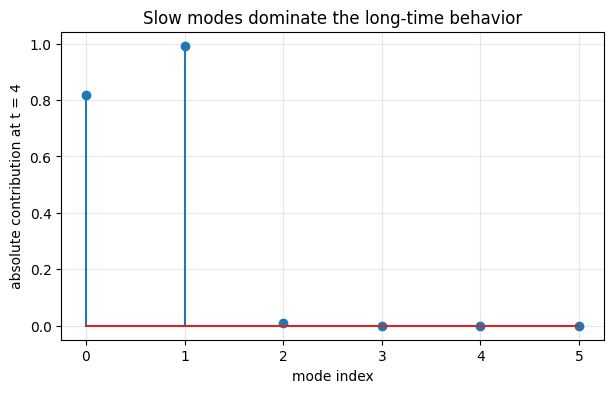

In [68]:
vals_diff, vecs_diff = eigh_sorted(L_diff)
coeff_diff = vecs_diff.T @ x0
decay = np.exp(-vals_diff * 4.0)
x_t_modes = vecs_diff @ (decay * coeff_diff)
x_t_exact = diffusion_exact(L_diff, x0, 4.0)

assert np.allclose(x_t_modes, x_t_exact)

display(pd.DataFrame({
    "lambda_k": vals_diff,
    "initial coefficient": coeff_diff,
    "multiplier exp(-lambda_k t)": decay,
    "magnitude at t=4": np.abs(decay * coeff_diff),
}))

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=100)
ax.stem(np.arange(len(vals_diff)), np.abs(decay * coeff_diff))
ax.set_xlabel("mode index")
ax.set_ylabel("absolute contribution at t = 4")
ax.set_title("Slow modes dominate the long-time behavior")
ax.grid(alpha=0.3)
plt.show()


On a graph with a clear bottleneck, this modal picture becomes especially concrete. Diffusion rapidly smooths the signal *within* each well-connected region, but the contrast *between* the regions decays only on the slower time scale set by the second eigenvalue. That is why the same second mode can be read three ways: as a cut vector, as a slow random-walk imbalance, and as the rate-limiting diffusion pattern.


### Your turn!

Think about the graph from Section 6 with two dense cliques connected by one weak bridge. Should diffusion between the two sides be fast or slow? What should that imply about the second Laplacian eigenvalue?

The right answer is not "because the graph is large" or "because there are many edges." The right answer is about the *bottleneck*.


In [69]:
# Reference solution
vals_bridge, _ = eigh_sorted(L_bridge)
vals_clique, _ = eigh_sorted(laplacian_from_adjacency(adjacency_dense(nx.complete_graph(12))[0]))

print("lambda_2 for two cliques with one bridge:", vals_bridge[1])
print("lambda_2 for a 12-node clique:", vals_clique[1])
print("Interpretation: the bottleneck makes lambda_2 much smaller, so inter-community diffusion is slower.")


lambda_2 for two cliques with one bridge: 0.25834261322606134
lambda_2 for a 12-node clique: 11.999999999999996
Interpretation: the bottleneck makes lambda_2 much smaller, so inter-community diffusion is slower.


## 8. Spectral clustering in practice

We now package the main ideas into an actual algorithm.

Spectral clustering is not magic. It is a disciplined way of using the low-frequency geometry of a graph to turn a network partitioning problem into an ordinary Euclidean clustering problem. The broad recipe is the following.

1. Build a graph and choose a Laplacian, usually $L_{\mathrm{sym}}$ or $L_{\mathrm{rw}}$.
2. Compute a small number of eigenvectors associated with the smallest eigenvalues.
3. Use those eigenvectors as an embedding of the nodes into Euclidean space.
4. Cluster the embedded points.

Shi and Malik (2000), Ng, Jordan, and Weiss (2001), Meilă and Shi (2001), and von Luxburg (2007) are standard references for this viewpoint.

### 8.1 Two-way clustering from the Fiedler vector

For a two-way partition, the simplest classroom version is almost embarrassingly direct: compute the second mode and cut by sign.

For the normalized Laplacian, the score that lines up most cleanly with normalized-cut theory is the degree-rescaled vector $D^{-1/2} u_2$. On a graph with two clear blocks and a weak connection between them, the positive and negative parts of that score often separate the blocks immediately.

This is the simplest case in which the continuous relaxation is easy to see. We get a real-valued score on the nodes first, and only then do we turn that score into a discrete partition.

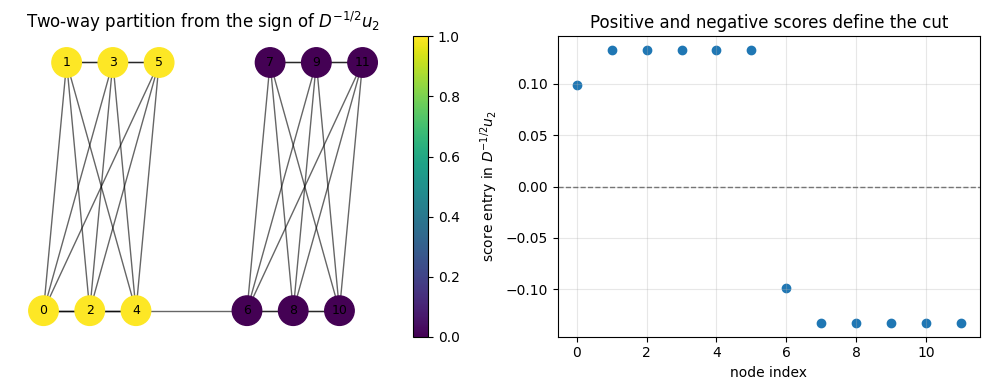

In [70]:
cluster_two_way = (sweep_scores >= 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=100)

draw_graph(
    G_bridge,
    axes[0],
    pos=pos_bridge,
    values=cluster_two_way,
    title="Two-way partition from the sign of $D^{-1/2}u_2$",
    with_labels=True,
)

axes[1].scatter(np.arange(len(nodes_bridge)), sweep_scores, color="tab:blue")
axes[1].axhline(0, linewidth=1, color="0.35", linestyle="--", alpha=0.8)
axes[1].set_xlabel("node index")
axes[1].set_ylabel(r"score entry in $D^{-1/2}u_2$")
axes[1].set_title("Positive and negative scores define the cut")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 8.2 The $k$-way algorithm in code

For more than two groups, the standard normalized-Laplacian recipe is:

1. compute the $k$ smallest eigenvectors of $L_{\mathrm{sym}}$,
2. stack them into a matrix $U \in \mathbb{R}^{n \times k}$,
3. normalize each row of $U$ to unit length,
4. run $k$-means on the rows.

The symbols map directly to the code below.

- $L_{\mathrm{sym}}$ is `Lsym`
- the eigenvector matrix $U$ is `X`
- the predicted labels are `labels_pred`

That row-normalization step is not cosmetic. It is the Ng-Jordan-Weiss move that makes direction in the low-dimensional eigenspace, rather than raw eigenvector magnitude, drive the clustering. We test the method on a three-block stochastic block model because community structure is already familiar from earlier classes.

We will return immediately afterward to the practical question students always ask next: why the first $k$ eigenvectors, and how do we think about choosing $k$ in practice?

The last reusable helper block packages the basic spectral clustering pipeline and a small stochastic block model generator for classroom-scale demos.

In [71]:
def spectral_clustering_lsym(G, k, seed=0, n_init=20):
    """Normalized spectral clustering using the k smallest eigenvectors of L_sym."""
    A, nodes = adjacency_sparse(G)
    Lsym = normalized_laplacian_sym(A)
    vals, vecs = eigsh_sorted(Lsym, k=k, which="SM")

    X = np.asarray(vecs, dtype=float)
    # Row-normalization is the Ng-Jordan-Weiss step: it clusters directions
    # in the low-dimensional eigenspace rather than raw eigenvector magnitudes.
    row_norms = np.linalg.norm(X, axis=1, keepdims=True)
    row_norms[row_norms == 0] = 1.0
    X = X / row_norms

    km = KMeans(n_clusters=k, random_state=seed, n_init=n_init)
    labels = km.fit_predict(X)
    return labels, nodes, vals, X

def sbm_equal_blocks(sizes, p_in, p_out, seed=0):
    """Stochastic block model with equal within-block and across-block probabilities."""
    k = len(sizes)
    probs = np.full((k, k), p_out, dtype=float)
    np.fill_diagonal(probs, p_in)
    G = nx.stochastic_block_model(sizes, probs, seed=seed)
    y = np.concatenate([np.full(size, group, dtype=int) for group, size in enumerate(sizes)])
    return G, y

G_cluster_check, y_cluster_check = sbm_equal_blocks([4, 4], p_in=0.9, p_out=0.1, seed=1)
assert len(y_cluster_check) == G_cluster_check.number_of_nodes()


Why should this help? Nodes that sit in the same graph community tend to have similar patterns of connection, so after the row-normalization step their rows in $U$ land near each other in Euclidean space.

That is why $k$-means becomes a natural second stage. The spectral embedding has already done the hard work of turning graph proximity into geometric proximity; $k$-means is only cleaning up the geometry.

Adjusted Rand index: 1.0


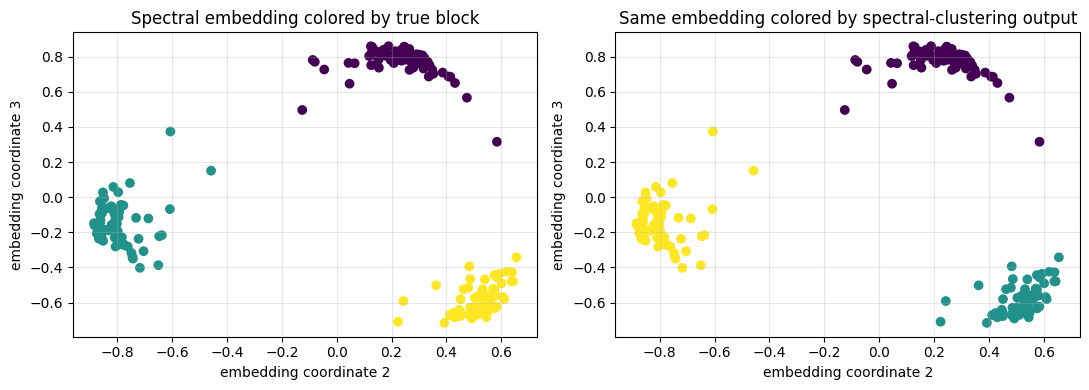

In [72]:
G_sbm3, y_true3 = sbm_equal_blocks([60, 60, 60], p_in=0.18, p_out=0.02, seed=21)
labels_pred3, nodes_sbm3, vals_sbm3, X_sbm3 = spectral_clustering_lsym(G_sbm3, k=3, seed=21, n_init=30)

ari3 = adjusted_rand_score(y_true3, labels_pred3)
print("Adjusted Rand index:", ari3)

assert ari3 > 0.8

# Use the first two nontrivial coordinates for plotting.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

axes[0].scatter(X_sbm3[:, 1], X_sbm3[:, 2], c=y_true3)
axes[0].set_xlabel("embedding coordinate 2")
axes[0].set_ylabel("embedding coordinate 3")
axes[0].set_title("Spectral embedding colored by true block")
axes[0].grid(alpha=0.3)

axes[1].scatter(X_sbm3[:, 1], X_sbm3[:, 2], c=labels_pred3)
axes[1].set_xlabel("embedding coordinate 2")
axes[1].set_ylabel("embedding coordinate 3")
axes[1].set_title("Same embedding colored by spectral-clustering output")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


A natural follow-up question is what happens if we deliberately ask for the wrong number of groups. Because this example comes from a known three-block model, we can check that sensitivity directly.

Treat the next plot as a calibration tool, not as a universal law. On real data there is no ground-truth label vector waiting off to the side, and performance can vary from one draw to the next.

,chosen k,ARI against the planted blocks,largest kept small eigenvalue
0,2,0.5687,0.1935
1,3,1.0000,0.2287
2,4,0.8681,0.5257
3,5,0.7185,0.5285


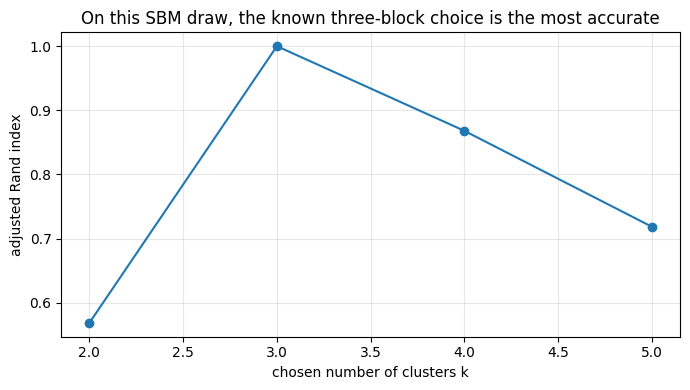

In [73]:
k_rows = []
for k_try in [2, 3, 4, 5]:
    labels_try, _, vals_try, _ = spectral_clustering_lsym(G_sbm3, k=k_try, seed=21, n_init=30)
    ari_try = adjusted_rand_score(y_true3, labels_try)
    k_rows.append({
        "chosen k": k_try,
        "ARI against the planted blocks": ari_try,
        "largest kept small eigenvalue": vals_try[-1],
    })

k_eval_df = pd.DataFrame(k_rows)
display(k_eval_df.round(4))

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=100)
ax.plot(k_eval_df["chosen k"], k_eval_df["ARI against the planted blocks"], marker="o")
ax.set_xlabel("chosen number of clusters k")
ax.set_ylabel("adjusted Rand index")
ax.set_title("On this SBM draw, the known three-block choice is the most accurate")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3 How many groups? Small eigenvalues, eigengaps, and why we keep the first $k$ vectors

One subtle point trips people up the first time through spectral clustering. If we want $k$ groups, why do we keep the first $k$ eigenvectors of $L_{\mathrm{sym}}$ instead of skipping the trivial one and using only $k-1$?

The clean answer comes from the disconnected ideal case. If a graph has exactly $k$ connected components, then $L_{\mathrm{sym}}$ has exactly $k$ zero eigenvalues, and the corresponding eigenspace is spanned by component-indicator directions. A nearly disconnected $k$-community graph is not exact, but it often still shows $k$ small eigenvalues: one global mode plus $k-1$ additional separation modes. That is why the embedding uses the first $k$ eigenvectors.

In practice, a common diagnostic is the eigengap heuristic: if there is a noticeable jump after the $k$th small eigenvalue, that supports using a $k$-dimensional spectral embedding. It is only a heuristic, though. Real networks may have fuzzy, hierarchical, or overlapping structure, and many graphs simply do not offer one clean gap.

,eigenvalue index,small eigenvalue of $L_{\mathrm{sym}}$,gap to next
0,0,-0.0000,0.1935
1,1,0.1935,0.0352
2,2,0.2287,0.2970
3,3,0.5257,0.0028
4,4,0.5285,0.0215
5,5,0.5500,0.0123
6,6,0.5623,0.0039
7,7,0.5662,0.0015
8,8,0.5677,0.0132
9,9,0.5809,NaN


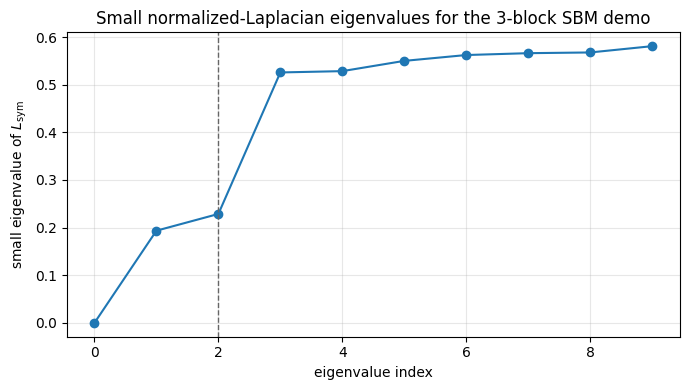

Largest early gap occurs after eigenvalue index: 2


In [74]:
A_sbm3_gap, nodes_sbm3_gap = adjacency_sparse(G_sbm3)
Lsym_sbm3_gap = normalized_laplacian_sym(A_sbm3_gap)
vals_gap3, _ = eigsh_sorted(Lsym_sbm3_gap, k=10, which="SM")
gaps_gap3 = np.diff(vals_gap3)
largest_early_gap = int(np.argmax(gaps_gap3[:6]))

gap_df = pd.DataFrame({
    "eigenvalue index": np.arange(len(vals_gap3)),
    r"small eigenvalue of $L_{\mathrm{sym}}$": np.round(vals_gap3, 4),
    "gap to next": np.round(np.r_[gaps_gap3, np.nan], 4),
})
display(gap_df)

fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=100)
ax.plot(np.arange(len(vals_gap3)), vals_gap3, marker="o")
ax.axvline(largest_early_gap, linestyle="--", linewidth=1, color="0.4")
ax.set_xlabel("eigenvalue index")
ax.set_ylabel(r"small eigenvalue of $L_{\mathrm{sym}}$")
ax.set_title("Small normalized-Laplacian eigenvalues for the 3-block SBM demo")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Largest early gap occurs after eigenvalue index:", largest_early_gap)

On this draw, the most visible early jump appears after the third small eigenvalue, which is consistent with the known three-block construction. That is encouraging, not definitive.

In real work, we usually pair eigengaps with stability checks, direct inspection of the embedding, and domain knowledge. The eigengap is a useful diagnostic, not an automatic proof of the "correct" number of communities.

### 8.4 Sparse matrices and eigensolvers matter in real network work

Everything so far has used tiny graphs to build intuition. Real network analysis is different. Dense $n \times n$ matrices cost $O(n^2)$ memory, which becomes impossible quickly.

Most large networks are sparse, and their graph matrices are sparse too. That is why we use sparse matrix formats and iterative eigensolvers such as `scipy.sparse.linalg.eigsh`. In practice, the goal is rarely to compute the full spectrum. The goal is to compute only the handful of eigenpairs that the application actually needs.

One practical reason the symmetric normalized Laplacian is such a workhorse is numerical as well as conceptual: `eigsh` is designed for real symmetric or Hermitian matrices. Once we move to directed operators, we often need different solvers or a different viewpoint entirely.

This is also where today's notebook connects back to the computational concerns from the big-data part of the course.

In [75]:
import time

rows = []
for n in [400, 800, 1600]:
    G_large = nx.erdos_renyi_graph(n, 6 / n, seed=9)
    A_large, _ = adjacency_sparse(G_large)
    Lsym_large = normalized_laplacian_sym(A_large)

    t0 = time.perf_counter()
    vals_large, _ = eigsh_sorted(Lsym_large, k=3, which="SM")
    dt = time.perf_counter() - t0

    rows.append({
        "n": n,
        "edges": G_large.number_of_edges(),
        "A.nnz": int(A_large.nnz),
        "time for 3 smallest eigenpairs (s)": round(dt, 4),
        "small eigenvalues": np.round(vals_large, 4),
    })

display(pd.DataFrame(rows))


,n,edges,A.nnz,time for 3 smallest eigenpairs (s),small eigenvalues
0,400,1265,2530,0.0557,"[-0.0, 0.284, 0.292]"
1,800,2510,5020,0.0122,"[-0.0, 0.2688, 0.2763]"
2,1600,4784,9568,0.0223,"[0.0, 0.2081, 0.2517]"


## 9. Pitfalls and numerical habits

Spectral methods are powerful, but they are also easy to misuse. A short checklist helps.

1. **Disconnected graphs are special.** If the graph has multiple components, there are multiple zero Laplacian eigenvalues.
2. **Eigenvector sign is arbitrary.** If your eigenvector comes back multiplied by $-1$, nothing is wrong.
3. **Repeated eigenvalues mean non-unique eigenvectors.** In that case the eigenspace is meaningful, not any single basis vector.
4. **Degree heterogeneity can localize adjacency-based methods.** A leading adjacency eigenvector can over-focus on hubs even when the global community signal is weak.
5. **Normalization choices matter.** $A$, $L$, $L_{\mathrm{sym}}$, and $L_{\mathrm{rw}}$ answer different questions.
6. **Standard Laplacian smoothness theory assumes nonnegative weights.** Signed or negative weights change the geometry and can break positive semidefiniteness.
7. **Sparse methods are essential at scale.** Large-network work is usually about a few extreme eigenpairs, not a dense full-spectrum computation.
8. **Directed graphs need extra care.** Eigenvalues can be complex, left and right eigenvectors are different objects, and centrality conventions depend on whether influence flows along incoming or outgoing edges.
9. **Choosing $k$ in spectral clustering is a modeling decision, not an oracle call.** Eigengaps can help, but they are hints, not certificates.
10. **Eigenvalues alone are not a complete graph fingerprint.** Distinct graphs can be cospectral, so matching spectra does not prove two graphs are the same.
11. **Never compare floating-point quantities by exact equality when a tolerance is the right idea.**

In [76]:
# A tiny numerical sanity check on sign ambiguity
A_cycle, _ = adjacency_dense(G_cycle6)
vals_cycle, vecs_cycle = eigh_sorted(A_cycle)

v = vecs_cycle[:, -1]
v_flip = -v

print("Residual of v:", np.linalg.norm(A_cycle @ v - vals_cycle[-1] * v))
print("Residual of -v:", np.linalg.norm(A_cycle @ v_flip - vals_cycle[-1] * v_flip))
print("Exact vectors equal?", np.allclose(v, v_flip))
print("Same subspace up to sign?", np.allclose(v, -v_flip))


Residual of v: 6.280369834735101e-16
Residual of -v: 6.280369834735101e-16
Exact vectors equal? False
Same subspace up to sign? True


## 10. Summary

The main point of the chapter is that graph matrices are not just containers for edge data. They are operators on node signals, and their eigenvectors reveal the natural modes of structure and dynamics on the graph.

Once that operator viewpoint is in place, several important network-science ideas line up with each other. Adjacency multiplication becomes neighborhood aggregation. The Laplacian becomes a disagreement operator. The quadratic form $x^\top L x$ becomes a smoothness measure. The zero-eigenvalue structure of $L$ becomes a connected-components test. The second Laplacian mode becomes a bottleneck detector. Random walks and diffusion become two dynamic faces of the same spectral picture.

The normalized operators tighten that picture even further. The matrices $A_{\mathrm{norm}}$, $P$, $L_{\mathrm{sym}}$, and $L_{\mathrm{rw}}$ are different coordinate versions of the same slow modes. That is why the same quantity can be described as a community-separation signal, a diffusion relaxation mode, a random-walk mixing mode, or a graph-Fourier low frequency, depending on which operator is in the foreground.

That same picture also explains why spectral clustering works. In the disconnected ideal case, $k$ components give $k$ zero modes; in the nearly disconnected case, those become the small eigenvalues that define the embedding. The embedding step converts graph proximity into Euclidean proximity, and then an ordinary geometric method such as $k$-means can do the final partitioning.

At large scale, the practical lesson is just as important as the theoretical one: sparse matrices and iterative eigensolvers are part of the method, not an implementation detail. The appendices push the same operator viewpoint outward toward incidence matrices, ranking, effective resistance, non-backtracking operators, spanning trees, spectral embeddings, and modularity. Together they show that the spectral toolkit is not one isolated trick. It is one of the main languages of modern network science.

## Appendix A. Incidence matrices and the factorization of the Laplacian

This appendix makes one more linear-algebra bridge explicit. Instead of thinking of a graph as a node-node matrix, we can think of it as a node-edge matrix.

Choose an arbitrary orientation for each undirected edge and build the oriented incidence matrix $B \in \mathbb{R}^{n \times m}$ by putting a $-1$ at the tail, a $+1$ at the head, and zeros elsewhere.

For an unweighted undirected graph, the key identity is

$$
L = B B^\top.
$$

The chosen edge orientations do not matter for this identity. Flipping the orientation of one edge only changes the sign of one column of $B$, and that sign disappears in the product $B B^\top$.


In [77]:
def oriented_incidence_matrix(G, nodelist=None, edgelist=None):
    """Oriented incidence matrix for an undirected graph."""
    nodes = stable_nodelist(G, nodelist)
    if edgelist is None:
        edgelist = list(G.edges())

    node_to_i = {u: i for i, u in enumerate(nodes)}
    B = np.zeros((len(nodes), len(edgelist)))

    for j, (u, v) in enumerate(edgelist):
        B[node_to_i[u], j] = -1.0
        B[node_to_i[v], j] = 1.0
    return B, nodes, edgelist


G_inc = nx.path_graph(6)
B_path, nodes_B, edges_B = oriented_incidence_matrix(G_inc)
A_path_inc, _ = adjacency_dense(G_inc)
L_path_inc = laplacian_from_adjacency(A_path_inc)
L_from_B = B_path @ B_path.T

show_matrix_df(B_path, name="Oriented incidence matrix B for the path graph", index=nodes_B, columns=[f"e{j}" for j in range(len(edges_B))])
show_matrix_df(L_from_B, name="B B^T", index=nodes_B, columns=nodes_B)

print("Does B B^T equal the Laplacian?", np.allclose(L_from_B, L_path_inc))
assert np.allclose(L_from_B, L_path_inc)


Oriented incidence matrix B for the path graph


,e0,e1,e2,e3,e4
0,-1.0,0.0,0.0,0.0,0.0
1,1.0,-1.0,0.0,0.0,0.0
2,0.0,1.0,-1.0,0.0,0.0
3,0.0,0.0,1.0,-1.0,0.0
4,0.0,0.0,0.0,1.0,-1.0
5,0.0,0.0,0.0,0.0,1.0


B B^T


,0,1,2,3,4,5
0,1.0,-1.0,0.0,0.0,0.0,0.0
1,-1.0,2.0,-1.0,0.0,0.0,0.0
2,0.0,-1.0,2.0,-1.0,0.0,0.0
3,0.0,0.0,-1.0,2.0,-1.0,0.0
4,0.0,0.0,0.0,-1.0,2.0,-1.0
5,0.0,0.0,0.0,0.0,-1.0,1.0


Does B B^T equal the Laplacian? True


## Appendix B. Katz centrality and PageRank as linear algebra problems

Eigenvector centrality is not the only walk-based centrality. Two classic alternatives are Katz centrality and PageRank.

For a directed graph, let $A_{ij} = 1$ when there is an edge from node $i$ to node $j$. If we want centrality to flow along incoming links, the Katz equation is

$$
x = \alpha A^\top x + \beta \mathbf{1},
$$

where:

- $A$ is the adjacency matrix,
- $\alpha$ is an attenuation factor with $\alpha < 1 / \rho(A)$,
- $\beta$ is an exogenous baseline term.

PageRank does something similar for directed graphs, but with a random-surfer interpretation and teleportation. In one common **column-stochastic** formulation,

$$
r = \alpha M r + (1-\alpha) v,
$$

where:

- $M$ is a column-stochastic link-following matrix,
- $r$ is the PageRank vector,
- $\alpha$ is the damping factor,
- $v$ is a teleportation distribution.

This appendix is a good place to notice the directed-graph bookkeeping issue explicitly. The core notebook used row-stochastic random walks for clarity, but PageRank is usually written in a column-stochastic form because importance is propagated through incoming links. Katz goes back to Katz (1953). PageRank is associated with Brin and Page (1998), and Langville and Meyer (2006) is a very readable linear-algebra treatment.

In [78]:
def pagerank_matrix(G, nodelist=None):
    """Column-stochastic matrix for PageRank with a dangling-node fix."""
    nodes = stable_nodelist(G, nodelist)
    index = {u: i for i, u in enumerate(nodes)}
    n = len(nodes)
    M = np.zeros((n, n), dtype=float)

    for j, u in enumerate(nodes):
        if G.is_directed():
            out_neighbors = list(G.successors(u))
        else:
            out_neighbors = list(G.neighbors(u))

        if len(out_neighbors) == 0:
            M[:, j] = 1.0 / n
        else:
            p = 1.0 / len(out_neighbors)
            for v in out_neighbors:
                i = index[v]
                M[i, j] += p

    assert np.allclose(M.sum(axis=0), 1.0)
    return M, nodes


def pagerank_solve(G, alpha=0.85, v=None, nodelist=None):
    """Solve the PageRank linear system exactly on a small graph."""
    M, nodes = pagerank_matrix(G, nodelist=nodelist)
    n = M.shape[0]
    if v is None:
        v = np.ones(n) / n
    r = np.linalg.solve(np.eye(n) - alpha * M, (1.0 - alpha) * v)
    r = r / r.sum()
    return r, nodes


G_dir = nx.DiGraph()
G_dir.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
    ("C", "A"),
    ("C", "D"),
    ("D", "C"),
])

A_dir, nodes_dir = adjacency_dense(G_dir, nodelist=["A", "B", "C", "D"])
rho_dir = np.max(np.abs(np.linalg.eigvals(A_dir)))
alpha_katz = 0.2
beta_katz = 1.0

assert alpha_katz < 1.0 / rho_dir

x_katz = np.linalg.solve(
    np.eye(A_dir.shape[0]) - alpha_katz * A_dir.T,
    beta_katz * np.ones(A_dir.shape[0]),
)

r_pr, nodes_pr = pagerank_solve(G_dir, alpha=0.85)
assert np.isclose(r_pr.sum(), 1.0)

display(pd.DataFrame({
    "incoming Katz centrality": x_katz / x_katz.sum(),
    "PageRank": r_pr,
}, index=nodes_dir))


,incoming Katz centrality,PageRank
A,0.234848,0.219914
B,0.219697,0.130963
C,0.310606,0.429209
D,0.234848,0.219914


## Appendix C. Effective resistance and the Laplacian pseudoinverse

One of the deepest and most beautiful facts in network science is that graph Laplacians connect random walks, electrical networks, and geometry.

For a connected undirected graph, let $L^+$ denote the Moore-Penrose pseudoinverse of the Laplacian. Then the effective resistance between nodes $u$ and $v$ is

$$
R_{uv} = (e_u - e_v)^\top L^+ (e_u - e_v),
$$

where $e_u$ and $e_v$ are standard basis vectors.

This quantity behaves like a distance, but one that is sensitive to the number of parallel routes between nodes. Doyle and Snell (1984) is the classic reference for the random-walk and electrical-network connection.


In [79]:
def laplacian_pseudoinverse(L, tol=1e-10):
    """Moore-Penrose pseudoinverse of a small Laplacian."""
    Ld = L.toarray() if sp.issparse(L) else np.asarray(L)
    vals, vecs = np.linalg.eigh(Ld)
    inv_vals = np.zeros_like(vals)
    mask = vals > tol
    inv_vals[mask] = 1.0 / vals[mask]
    return (vecs * inv_vals) @ vecs.T


def effective_resistance_matrix(G):
    """All-pairs effective resistance matrix for a small connected graph."""
    A, nodes = adjacency_dense(G)
    L = laplacian_from_adjacency(A)
    Lplus = laplacian_pseudoinverse(L)

    n = len(nodes)
    R = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            e = np.zeros(n)
            e[i] = 1.0
            e[j] -= 1.0
            R[i, j] = e @ Lplus @ e
    return R, nodes


R_path, nodes_R = effective_resistance_matrix(nx.path_graph(5))
R_cycle, _ = effective_resistance_matrix(nx.cycle_graph(5))

show_matrix_df(np.round(R_path, 3), name="Effective resistances on a 5-node path", index=nodes_R, columns=nodes_R)
show_matrix_df(np.round(R_cycle, 3), name="Effective resistances on a 5-node cycle", index=nodes_R, columns=nodes_R)


Effective resistances on a 5-node path


,0,1,2,3,4
0,0.0,1.0,2.0,3.0,4.0
1,1.0,0.0,1.0,2.0,3.0
2,2.0,1.0,0.0,1.0,2.0
3,3.0,2.0,1.0,0.0,1.0
4,4.0,3.0,2.0,1.0,0.0


Effective resistances on a 5-node cycle


,0,1,2,3,4
0,0.0,0.8,1.2,1.2,0.8
1,0.8,0.0,0.8,1.2,1.2
2,1.2,0.8,0.0,0.8,1.2
3,1.2,1.2,0.8,0.0,0.8
4,0.8,1.2,1.2,0.8,0.0


## Appendix D. The non-backtracking matrix and sparse graph structure

The non-backtracking matrix is an advanced but very important operator in modern network science. It appears when ordinary adjacency spectra become unreliable on sparse graphs.

Historically, the operator goes back to Hashimoto's zeta-function viewpoint and Bass's determinant formula. In modern network science it reappears in sparse community detection, localization, and Bethe-Hessian methods; Krzakala et al. (2013), Saade, Krzakala, and Zdeborová (2014), and Martin, Zhang, and Newman (2014) are especially useful entry points.

For an undirected graph, first replace every undirected edge $\{u,v\}$ by two directed edges $(u \to v)$ and $(v \to u)$. The non-backtracking matrix $B$ is indexed by those directed edges and is defined by

$$
B_{(u \to v),(x \to y)} =
\begin{cases}
1 & \text{if } v = x \text{ and } y \neq u, \\
0 & \text{otherwise.}
\end{cases}
$$

The condition $y \neq u$ forbids immediately reversing the previous step. That small change has large consequences in sparse graphs.

In [80]:
def directed_edges(G):
    """List both orientations of every undirected edge."""
    dedges = []
    for u, v in G.edges():
        dedges.append((u, v))
        dedges.append((v, u))
    return dedges


def nonbacktracking_matrix(G):
    """Sparse non-backtracking matrix B."""
    dedges = directed_edges(G)
    idx = {e: i for i, e in enumerate(dedges)}

    rows = []
    cols = []
    data = []

    for (u, v), i in idx.items():
        for w in G.neighbors(v):
            if w == u:
                continue
            j = idx[(v, w)]
            rows.append(i)
            cols.append(j)
            data.append(1.0)

    B = sp.csr_matrix((data, (rows, cols)), shape=(len(dedges), len(dedges)))
    return B, dedges, idx


def count_nb_walks_length2(G, e, f):
    """Brute-force count of non-backtracking edge walks of length 2."""
    u, v = e
    count = 0
    for w in G.neighbors(v):
        if w == u:
            continue
        for z in G.neighbors(w):
            if z == v:
                continue
            if (w, z) == f:
                count += 1
    return count


G_nb_small = nx.cycle_graph(5)
B_nb_small, dedges_nb, idx_nb = nonbacktracking_matrix(G_nb_small)

e = (0, 1)
f = (2, 3)
B2 = (B_nb_small @ B_nb_small).toarray()

print("Shape of B:", B_nb_small.shape)
print("B^2[(0->1),(2->3)] =", B2[idx_nb[e], idx_nb[f]])
print("Brute-force count:", count_nb_walks_length2(G_nb_small, e, f))

assert B2[idx_nb[e], idx_nb[f]] == count_nb_walks_length2(G_nb_small, e, f)


Shape of B: (10, 10)
B^2[(0->1),(2->3)] = 1.0
Brute-force count: 1


### D.1 Two quick structural facts

Two classroom-scale facts are especially helpful.

1. On a tree, the non-backtracking matrix is nilpotent. Eventually every non-backtracking walk runs out of room, because there are no cycles to keep it alive.
2. On a simple undirected graph, the trace $\mathrm{tr}(B^3)$ counts triangles, up to the factor $6$ coming from orientation and starting-edge choices.

These facts make the operator feel less mysterious: it is still counting walks, just a more selective kind of walk.


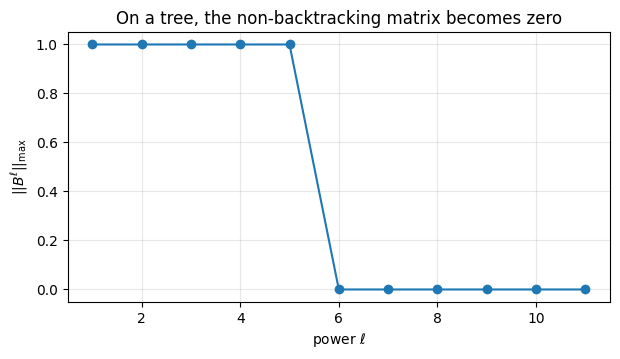

Triangles in K3: 1
tr(B^3): 6.0


In [81]:
G_tree = nx.balanced_tree(r=2, h=3)
B_tree, _, _ = nonbacktracking_matrix(G_tree)
B_tree_dense = B_tree.toarray()

power_norms = []
for ell in range(1, 12):
    Bpow = np.linalg.matrix_power(B_tree_dense, ell)
    power_norms.append(np.max(np.abs(Bpow)))

G_tri = nx.complete_graph(3)
B_tri, _, _ = nonbacktracking_matrix(G_tri)
triangles = sum(nx.triangles(G_tri).values()) // 3
trB3 = (B_tri @ B_tri @ B_tri).diagonal().sum()

fig, ax = plt.subplots(1, 1, figsize=(7, 3.5), dpi=100)
ax.plot(np.arange(1, 12), power_norms, marker="o")
ax.set_xlabel(r"power $\ell$")
ax.set_ylabel(r"$||B^\ell||_{\max}$")
ax.set_title("On a tree, the non-backtracking matrix becomes zero")
ax.grid(alpha=0.3)
plt.show()

print("Triangles in K3:", triangles)
print("tr(B^3):", trB3)
assert np.isclose(trB3, 6 * triangles)


### D.2 Bethe Hessian versus ordinary spectral clustering on a sparse SBM

One reason the non-backtracking viewpoint matters is that ordinary adjacency and Laplacian spectra can become noisy and localized in sparse stochastic block models. The Bethe Hessian is a node-space symmetric operator that often captures the same sparse-graph signal much more cleanly.

The goal of the next demo is not to settle the theory in one plot. It is to show, on a single reproducible example, why sparse community detection pushed researchers beyond the classical adjacency and Laplacian matrices.

In [82]:
def labels_from_vector_sign(v):
    """Binary labels from the sign or median split of a score vector."""
    v = np.asarray(v, dtype=float).ravel()
    thresh = np.median(v)
    return (v > thresh).astype(int)

def best_binary_alignment(y_true, y_pred):
    """Best label alignment for a binary clustering."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    acc1 = np.mean(y_true == y_pred)
    acc2 = np.mean(y_true == 1 - y_pred)
    return max(acc1, acc2)

def sbm_two_groups(n, cin, cout, seed=0):
    """Sparse two-block SBM with p_in = cin/n and p_out = cout/n."""
    sizes = [n // 2, n - n // 2]
    probs = [[cin / n, cout / n], [cout / n, cin / n]]
    G = nx.stochastic_block_model(sizes, probs, seed=seed)
    y = np.array([0] * sizes[0] + [1] * sizes[1])
    return G, y

def nonbacktracking_reduced_matrix(G):
    """2n x 2n reduction associated with the non-backtracking operator."""
    A, nodes = adjacency_sparse(G)
    d = degree_vector_from_adjacency(A)
    n = A.shape[0]

    top_left = sp.csr_matrix((n, n))
    top_right = diag_sparse(d) - sp.eye(n, format="csr")
    bottom_left = -sp.eye(n, format="csr")
    bottom_right = A

    B0 = sp.bmat([[top_left, top_right], [bottom_left, bottom_right]], format="csr")
    return B0, A, d, nodes

def bethe_hessian_from_adjacency(A, d, r):
    """Bethe Hessian H(r) = (r^2 - 1) I - r A + D."""
    n = A.shape[0]
    return (r**2 - 1) * sp.eye(n, format="csr") - r * A + diag_sparse(d)

G_binary_check, y_binary_check = sbm_two_groups(n=20, cin=6.0, cout=1.0, seed=2)
assert len(y_binary_check) == G_binary_check.number_of_nodes()


Binary clustering accuracy on one sparse SBM instance
Adjacency second eigenvector:    0.6
Normalized Laplacian:           0.55
Bethe Hessian:                  0.618
Estimated bulk radius sqrt(c):  1.708


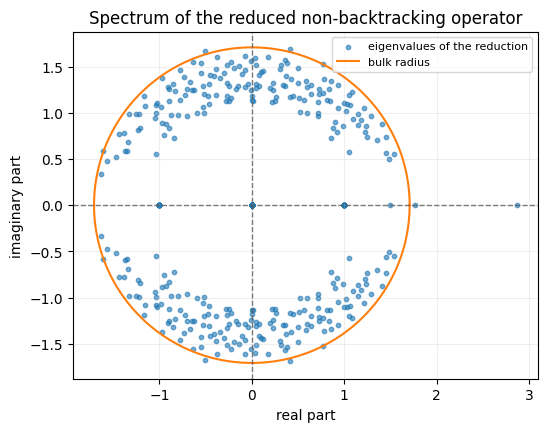

In [83]:
G_sparse_sbm, y_sparse = sbm_two_groups(n=220, cin=5.0, cout=1.0, seed=31)

# Ordinary normalized-Laplacian clustering
labels_L, nodes_L, _, _ = spectral_clustering_lsym(G_sparse_sbm, k=2, seed=31, n_init=20)
acc_L = best_binary_alignment(y_sparse, labels_L)

# Adjacency second eigenvector
A_sparse_sbm, nodes_sparse_sbm = adjacency_sparse(G_sparse_sbm)
vals_A_sparse, vecs_A_sparse = eigsh_sorted(A_sparse_sbm, k=2, which="LA")
labels_A = labels_from_vector_sign(vecs_A_sparse[:, 0])
acc_A = best_binary_alignment(y_sparse, labels_A)

# Bethe Hessian
d_sparse = degree_vector_from_adjacency(A_sparse_sbm)
r_est = np.sqrt(np.sum(d_sparse * (d_sparse - 1)) / np.sum(d_sparse))
H_sparse = bethe_hessian_from_adjacency(A_sparse_sbm, d_sparse, r_est)
vals_H_sparse, vecs_H_sparse = eigsh_sorted(H_sparse, k=2, which="SA")
labels_H = labels_from_vector_sign(vecs_H_sparse[:, 0])
acc_H = best_binary_alignment(y_sparse, labels_H)

# Spectrum of the 2n x 2n reduction
B0_sparse, _, _, _ = nonbacktracking_reduced_matrix(G_sparse_sbm)
mu = np.linalg.eigvals(B0_sparse.toarray())
c_avg = np.mean(d_sparse)
radius = np.sqrt(c_avg)

print("Binary clustering accuracy on one sparse SBM instance")
print("Adjacency second eigenvector:   ", round(acc_A, 3))
print("Normalized Laplacian:          ", round(acc_L, 3))
print("Bethe Hessian:                 ", round(acc_H, 3))
print("Estimated bulk radius sqrt(c): ", round(radius, 3))

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
ax.scatter(mu.real, mu.imag, s=10, alpha=0.6, color="tab:blue", label="eigenvalues of the reduction")
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(radius * np.cos(theta), radius * np.sin(theta), linewidth=1.5, color="tab:orange", label="bulk radius")
ax.axhline(0, linewidth=1, color="0.35", linestyle="--", alpha=0.8)
ax.axvline(0, linewidth=1, color="0.35", linestyle="--", alpha=0.8)
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Spectrum of the reduced non-backtracking operator")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
ax.legend(loc="upper right", fontsize=8)
plt.show()


### D.3 A concrete check of the $2n \times 2n$ reduction

The $2n \times 2n$ reduced operator is useful because the full non-backtracking matrix lives on directed edges, while the reduction lives on nodes. On a small regular graph, the comparison is especially transparent: for a cycle, the full and reduced spectra coincide exactly.

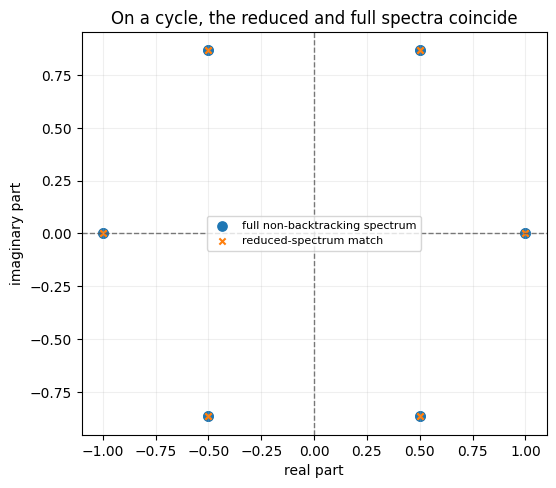

In [84]:
def sort_complex_lex(vals, digits=12):
    """Sort complex numbers by rounded real part, then rounded imaginary part."""
    vals = np.asarray(vals)
    order = np.lexsort((np.round(vals.imag, digits), np.round(vals.real, digits)))
    return vals[order]


G_nb_compare = nx.cycle_graph(6)
B_full, _, _ = nonbacktracking_matrix(G_nb_compare)
B_reduced, A_compare, d_compare, nodes_compare = nonbacktracking_reduced_matrix(G_nb_compare)

full_eigs = np.linalg.eigvals(B_full.toarray())
reduced_eigs = np.linalg.eigvals(B_reduced.toarray())

full_sorted = sort_complex_lex(full_eigs)
reduced_sorted = sort_complex_lex(reduced_eigs)

assert len(full_sorted) == len(reduced_sorted)
assert np.allclose(full_sorted, reduced_sorted)

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
ax.scatter(full_eigs.real, full_eigs.imag, color="tab:blue", s=45, label="full non-backtracking spectrum")
ax.scatter(reduced_eigs.real, reduced_eigs.imag, color="tab:orange", s=20, marker="x", label="reduced-spectrum match")
ax.axhline(0, linewidth=1, color="0.35", linestyle="--", alpha=0.8)
ax.axvline(0, linewidth=1, color="0.35", linestyle="--", alpha=0.8)
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("On a cycle, the reduced and full spectra coincide")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()


## Appendix E. Kirchhoff's matrix-tree theorem and spanning trees

Another beautiful payoff of Laplacian spectral theory is that it counts combinatorial objects.

For a connected graph on $n$ nodes with Laplacian eigenvalues

$$
0 = \lambda_1 < \lambda_2 \le \cdots \le \lambda_n,
$$

Kirchhoff's matrix-tree theorem implies

$$
\tau(G) = \frac{1}{n} \prod_{k=2}^n \lambda_k,
$$

where $\tau(G)$ is the number of spanning trees of $G$.

This identity is striking because it says a purely combinatorial count can be recovered from the nonzero Laplacian spectrum. Standard references include Chung (1997), Newman (2018), and Spielman (2019).

In [85]:
def spanning_tree_count_spectral(G, tol=1e-10):
    """Count spanning trees from the nonzero Laplacian eigenvalues."""
    A, nodes = adjacency_dense(G)
    L = laplacian_from_adjacency(A)
    vals, _ = eigh_sorted(L)
    nonzero = vals[vals > tol]
    tau = np.prod(nonzero) / len(nodes)
    return int(round(float(np.real_if_close(tau))))


rows = []
for name, G_example in [
    ("path on 5 nodes", nx.path_graph(5)),
    ("cycle on 5 nodes", nx.cycle_graph(5)),
    ("complete graph K5", nx.complete_graph(5)),
]:
    tau_spectral = spanning_tree_count_spectral(G_example)
    tau_nx = int(round(float(nx.number_of_spanning_trees(G_example))))
    rows.append({
        "graph": name,
        "spectral count": tau_spectral,
        "networkx count": tau_nx,
    })
    assert tau_spectral == tau_nx

display(pd.DataFrame(rows))


,graph,spectral count,networkx count
0,path on 5 nodes,1,1
1,cycle on 5 nodes,5,5
2,complete graph K5,125,125


## Appendix F. Spectral embeddings, diffusion maps, and where this goes next

The same eigenvectors we used for cuts and clustering can also be read as coordinates. Instead of thinking of an eigenvector as a single node signal, think of several eigenvectors together as a map from nodes into Euclidean space.

That viewpoint sits behind spectral embedding, Laplacian eigenmaps, diffusion maps, manifold learning, and a great deal of modern graph machine learning. The point is not that the graph literally lives in a low-dimensional Euclidean space. The point is that the slow graph modes often supply coordinates that respect connectivity, diffusion, or community structure much better than the raw node labels do.

Belkin and Niyogi (2003) and Coifman and Lafon (2006) are canonical references for this broader geometric viewpoint.

<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2653/2077005124.py:30: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_xlabel("second $L_{\mathrm{sym}}$ eigenvector")
/tmp/ipykernel_2653/2077005124.py:31: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_ylabel("third $L_{\mathrm{sym}}$ eigenvector")


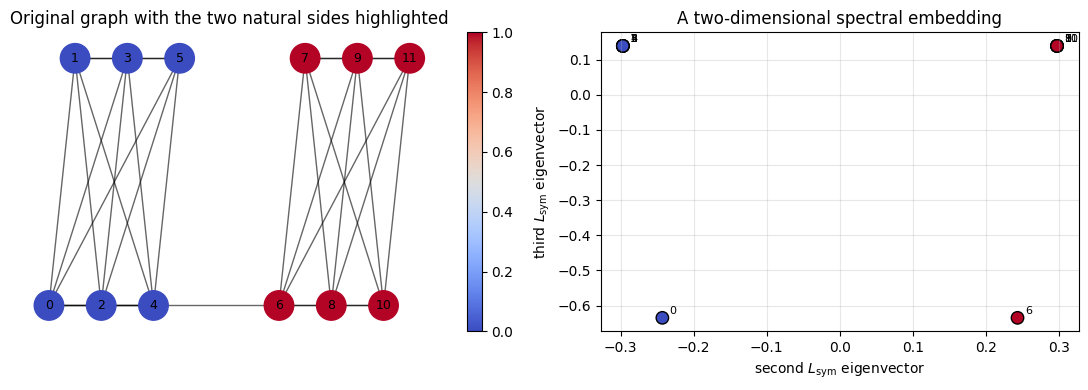

In [86]:
G_embed = nx.disjoint_union(nx.complete_graph(6), nx.complete_graph(6))
G_embed.add_edge(0, 6)

A_embed, nodes_embed = adjacency_dense(G_embed)
Lsym_embed = normalized_laplacian_sym(A_embed)
vals_embed, vecs_embed = eigh_sorted(Lsym_embed)

coords = vecs_embed[:, 1:3]
community_embed = np.array([0 if node < 6 else 1 for node in nodes_embed])

pos_embed = {}
pos_embed.update({i: (-1.1 + 0.25 * i, 0.1 * (i % 2)) for i in range(6)})
pos_embed.update({i + 6: (1.1 + 0.25 * i, 0.1 * (i % 2)) for i in range(6)})

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

draw_graph(
    G_embed,
    axes[0],
    pos=pos_embed,
    values=community_embed,
    title="Original graph with the two natural sides highlighted",
    with_labels=True,
    cmap="coolwarm",
)

axes[1].scatter(coords[:, 0], coords[:, 1], c=community_embed, cmap="coolwarm", edgecolor="k", s=80)
for i, node in enumerate(nodes_embed):
    axes[1].text(coords[i, 0] + 0.01, coords[i, 1] + 0.01, str(node), fontsize=8)
axes[1].set_xlabel("second $L_{\mathrm{sym}}$ eigenvector")
axes[1].set_ylabel("third $L_{\mathrm{sym}}$ eigenvector")
axes[1].set_title("A two-dimensional spectral embedding")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In the right-hand panel, nodes that share the same side of the bottleneck land near one another even though we never fed Euclidean coordinates into the construction. That is the geometric payoff of spectral thinking: the matrix has turned connectivity patterns into coordinates.

Laplacian eigenmaps use this idea directly. Diffusion maps refine it by weighting coordinates with powers of random-walk eigenvalues so that distances in the embedding reflect diffusion over multiple time steps. In modern graph learning, closely related constructions reappear in graph filters, spectral convolution ideas, and Laplacian-based regularization.

## Appendix G. Modularity as another spectral route to communities

The main notebook used Laplacians and cuts to get at community structure. Another classical route is modularity. Newman (2013) is the main spectral reference for this viewpoint, while Fortunato (2010) is a broad review of the community-detection landscape.

For a partition of the nodes into groups $g_i$, the modularity score is

$$
Q = \frac{1}{2m} \sum_{i,j} \left(A_{ij} - \frac{k_i k_j}{2m}\right) \delta_{g_i,g_j},
$$

where $A_{ij}$ is the adjacency entry, $k_i$ and $k_j$ are node degrees, $m$ is the number of edges, and $\delta_{g_i,g_j}$ equals $1$ when nodes $i$ and $j$ are placed in the same group and $0$ otherwise.

The matrix

$$
B = A - \frac{k k^\top}{2m}
$$

is called the modularity matrix. For a two-way split encoded by a sign vector $s_i \in \{-1,+1\}$, the objective becomes

$$
Q = \frac{1}{4m} s^\top B s.
$$

If we relax the sign constraint and allow a real vector instead, the leading eigenvector of $B$ becomes the natural continuous direction. This is not the same objective as normalized cuts, but on many graphs with two clear communities both methods point to similar partitions. Modularity also brings its own caveats, especially resolution issues on multiscale graphs; Fortunato (2010) is the right broad reference there.

,modularity eigenvector,sign partition
0,0.2523,1
1,0.2954,1
2,0.2954,1
3,0.2954,1
4,0.2954,1
5,0.2954,1
6,-0.2523,0
7,-0.2954,0
8,-0.2954,0
9,-0.2954,0


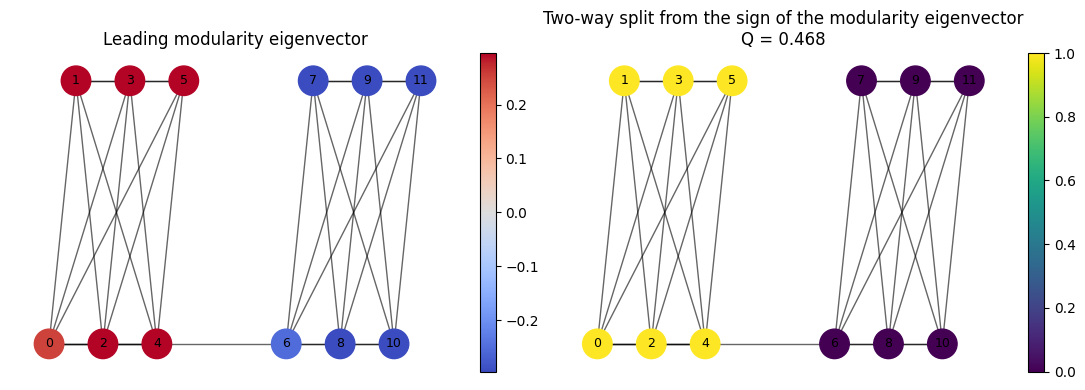

Agreement with the Fiedler-based split (up to label flip): 1.0


In [87]:
def modularity_matrix_from_adjacency(A):
    """Modularity matrix B = A - k k^T / (2m) for an undirected graph."""
    A = np.asarray(A, dtype=float)
    k = A.sum(axis=1)
    m = k.sum() / 2.0
    if m == 0:
        raise ValueError("modularity matrix is undefined for an edgeless graph")
    return A - np.outer(k, k) / (2.0 * m)

A_mod, nodes_mod = adjacency_dense(G_bridge)
B_mod = modularity_matrix_from_adjacency(A_mod)
vals_mod, vecs_mod = eigh_sorted(B_mod)
v_mod = normalize_sign(vecs_mod[:, -1])
labels_mod = (v_mod >= 0).astype(int)

communities_mod = [
    set(np.array(nodes_mod)[labels_mod == 0]),
    set(np.array(nodes_mod)[labels_mod == 1]),
]
Q_mod = nx.algorithms.community.quality.modularity(G_bridge, communities_mod)

agreement_mod = max(
    np.mean(labels_mod == cluster_two_way),
    np.mean(labels_mod == 1 - cluster_two_way),
)

display(pd.DataFrame({
    "modularity eigenvector": v_mod,
    "sign partition": labels_mod,
}, index=nodes_mod).round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

draw_graph(
    G_bridge,
    axes[0],
    pos=pos_bridge,
    values=v_mod,
    title="Leading modularity eigenvector",
    with_labels=True,
    cmap="coolwarm",
)

draw_graph(
    G_bridge,
    axes[1],
    pos=pos_bridge,
    values=labels_mod,
    title=f"Two-way split from the sign of the modularity eigenvector\nQ = {Q_mod:.3f}",
    with_labels=True,
)

plt.tight_layout()
plt.show()

print("Agreement with the Fiedler-based split (up to label flip):", round(agreement_mod, 3))
assert 0.0 <= Q_mod <= 1.0
assert agreement_mod > 0.9

On this graph the modularity and Fiedler routes agree almost perfectly because the network really does look like two dense blocks joined by a weak bridge. On more degree-heterogeneous or multiscale graphs the two objectives can diverge, which is a useful reminder that community structure is not a single mathematically unique concept.

## Appendix H. Why normalized cuts lead to a generalized eigenproblem

One important theoretical bridge is worth making fully explicit.

Suppose we want a two-way partition that is cheap in the normalized-cut sense. After relaxing the discrete partition indicator to a real-valued score vector, the core optimization becomes

$$
\min_{x \neq 0, \; x^\top D \mathbf{1} = 0}
\frac{x^\top L x}{x^\top D x}.
$$

Here:

- $x$ is now a real score assigned to nodes,
- $L = D - A$ is the combinatorial Laplacian,
- $D$ weights nodes by degree,
- the constraint $x^\top D \mathbf{1} = 0$ removes the trivial constant direction.

This is a degree-weighted Rayleigh quotient. Its stationary points satisfy the generalized eigenproblem

$$
L x = \lambda D x.
$$

That is the normalized-cut version of the Fiedler problem. If we define

$$
z = D^{1/2} x,
$$

then multiplying the generalized eigenproblem by $D^{-1/2}$ shows that

$$
L_{\mathrm{sym}} z = \lambda z.
$$

So the smallest nontrivial eigenvectors of $L_{\mathrm{sym}}$ are not appearing by magic. They are the orthonormalized coordinates of the relaxed normalized-cut problem. This is one reason many implementations compute ordinary eigenvectors of $L_{\mathrm{sym}}$ even when the derivation begins with a degree-weighted cut objective.

In [88]:

A_ncut, nodes_ncut = adjacency_dense(G_bridge)
L_ncut = laplacian_from_adjacency(A_ncut)
D_ncut = degree_matrix_from_adjacency(A_ncut)
d_ncut = degree_vector_from_adjacency(A_ncut)

# Generalized eigenproblem L x = lambda D x
vals_gen, vecs_gen = la.eigh(L_ncut, D_ncut)
x2_gen = normalize_sign(vecs_gen[:, 1])

# Symmetric normalized problem L_sym z = lambda z
Lsym_ncut = normalized_laplacian_sym(A_ncut)
vals_sym, vecs_sym = eigh_sorted(Lsym_ncut)
z2_sym = normalize_sign(vecs_sym[:, 1])

# Convert between the two coordinate systems
x2_from_sym = safe_inv_sqrt(d_ncut) * z2_sym
z2_from_gen = np.sqrt(d_ncut) * x2_gen

res_gen = np.linalg.norm(L_ncut @ x2_gen - vals_gen[1] * (D_ncut @ x2_gen))
res_sym = np.linalg.norm(Lsym_ncut @ z2_sym - vals_sym[1] * z2_sym)
corr_x = abs(np.corrcoef(x2_gen, x2_from_sym)[0, 1])
corr_z = abs(np.corrcoef(z2_sym, z2_from_gen)[0, 1])

display(pd.DataFrame({
    "generalized mode x_2": x2_gen,
    "D^{-1/2} u_2 from L_sym": x2_from_sym,
    "u_2 from L_sym": z2_sym,
    "D^{1/2} x_2": z2_from_gen,
}, index=nodes_ncut).round(4))

print("lambda_2 from L x = lambda D x:", vals_gen[1])
print("lambda_2 from L_sym z = lambda z:", vals_sym[1])
print("generalized residual:", res_gen)
print("symmetric residual:", res_sym)
print("correlation between x_2 and D^{-1/2} u_2:", corr_x)
print("correlation between u_2 and D^{1/2} x_2:", corr_z)

assert np.isclose(vals_gen[1], vals_sym[1])
assert res_gen < 1e-10
assert res_sym < 1e-10
assert corr_x > 0.999
assert corr_z > 0.999


,generalized mode x_2,D^{-1/2} u_2 from L_sym,u_2 from L_sym,D^{1/2} x_2
0,-0.0992,0.0992,0.2429,-0.2429
1,-0.1328,0.1328,0.2970,-0.2970
2,-0.1328,0.1328,0.2970,-0.2970
3,-0.1328,0.1328,0.2970,-0.2970
4,-0.1328,0.1328,0.2970,-0.2970
5,-0.1328,0.1328,0.2970,-0.2970
6,0.0992,-0.0992,-0.2429,0.2429
7,0.1328,-0.1328,-0.2970,0.2970
8,0.1328,-0.1328,-0.2970,0.2970
9,0.1328,-0.1328,-0.2970,0.2970


lambda_2 from L x = lambda D x: 0.05065823679658972
lambda_2 from L_sym z = lambda z: 0.050658236796589574
generalized residual: 1.0316632554177495e-15
symmetric residual: 5.079749022948204e-16
correlation between x_2 and D^{-1/2} u_2: 1.0
correlation between u_2 and D^{1/2} x_2: 1.0


This appendix is the algebraic reason spectral clustering has two seemingly different but equivalent formulations. One starts from a cut objective and arrives at $L x = \lambda D x$. The other starts from a symmetric matrix and computes ordinary eigenvectors of $L_{\mathrm{sym}}$. They are the same relaxed problem written in two coordinate systems.

## References

The list below is intentionally broad enough to support both the main lecture path and the appendices. It is organized by theme so it can also serve as a reading map.

A strong first reading path after class is: Fiedler (1973) for algebraic connectivity, Chung (1997) for spectral graph theory, Lovász (1993) or Masuda, Porter, and Lambiotte (2017) for random walks and diffusion, and von Luxburg (2007) for spectral clustering.

### Foundational spectral graph theory, random walks, and mixing

- Chung, Fan R. K. *Spectral Graph Theory*. CBMS Regional Conference Series in Mathematics, no. 92. American Mathematical Society, 1997.
- Mohar, Bojan. "The Laplacian Spectrum of Graphs." In *Graph Theory, Combinatorics, and Applications*, edited by Y. Alavi, G. Chartrand, O. R. Oellermann, and A. J. Schwenk, 871-898. Wiley, 1991.
- Newman, Mark. *Networks*. 2nd ed. Oxford University Press, 2018.
- Spielman, Daniel A. *Spectral and Algebraic Graph Theory*. Lecture notes, 2019.
- Lovász, László. "Random Walks on Graphs: A Survey." In *Combinatorics, Paul Erdős Is Eighty*, vol. 2, 1-46, 1993.
- Doyle, Peter G., and J. Laurie Snell. *Random Walks and Electric Networks*. Mathematical Association of America, 1984.
- Chung, Fan. "Random Walks and Local Cuts in Graphs." *Linear Algebra and its Applications* 423, no. 1 (2007): 22-32. doi: 10.1016/j.laa.2006.07.018.
- Levin, David A., Yuval Peres, and Elizabeth L. Wilmer. *Markov Chains and Mixing Times*. 2nd ed. American Mathematical Society, 2017.
- Masuda, Naoki, Mason A. Porter, and Renaud Lambiotte. "Random Walks and Diffusion on Networks." *Physics Reports* 716-717 (2017): 1-58. doi: 10.1016/j.physrep.2017.07.007.

### Cuts, clustering, graph Fourier ideas, and embeddings

- Fiedler, Miroslav. "Algebraic Connectivity of Graphs." *Czechoslovak Mathematical Journal* 23, no. 2 (1973): 298-305. doi: 10.21136/CMJ.1973.101168.
- Shi, Jianbo, and Jitendra Malik. "Normalized Cuts and Image Segmentation." *IEEE Transactions on Pattern Analysis and Machine Intelligence* 22, no. 8 (2000): 888-905. doi: 10.1109/34.868688.
- Meilă, Marina, and Jianbo Shi. "A Random Walks View of Spectral Segmentation." In *Proceedings of the International Workshop on Artificial Intelligence and Statistics*, 2001.
- Ng, Andrew Y., Michael I. Jordan, and Yair Weiss. "On Spectral Clustering: Analysis and an Algorithm." In *Advances in Neural Information Processing Systems 14*, 849-856, 2001.
- von Luxburg, Ulrike. "A Tutorial on Spectral Clustering." *Statistics and Computing* 17, no. 4 (2007): 395-416. doi: 10.1007/s11222-007-9033-z.
- Belkin, Mikhail, and Partha Niyogi. "Laplacian Eigenmaps for Dimensionality Reduction and Data Representation." *Neural Computation* 15, no. 6 (2003): 1373-1396. doi: 10.1162/089976603321780317.
- Coifman, Ronald R., and Stéphane Lafon. "Diffusion Maps." *Applied and Computational Harmonic Analysis* 21, no. 1 (2006): 5-30. doi: 10.1016/j.acha.2006.04.006.

### Community structure, modularity, and multiscale viewpoints

- Newman, M. E. J. "Spectral Methods for Community Detection and Graph Partitioning." *Physical Review E* 88, no. 4 (2013): 042822. doi: 10.1103/PhysRevE.88.042822.
- Lambiotte, Renaud, Jean-Charles Delvenne, and Mauricio Barahona. "Random Walks, Markov Processes and the Multiscale Modular Organization of Complex Networks." *IEEE Transactions on Network Science and Engineering* 1, no. 2 (2014): 76-90. doi: 10.1109/TNSE.2015.2391998.
- Fortunato, Santo. "Community Detection in Graphs." *Physics Reports* 486, no. 3-5 (2010): 75-174. doi: 10.1016/j.physrep.2009.11.002.

### Centrality, ranking, and network dynamics

- Katz, Leo. "A New Status Index Derived from Sociometric Analysis." *Psychometrika* 18, no. 1 (1953): 39-43. doi: 10.1007/BF02289026.
- Brin, Sergey, and Lawrence Page. "The Anatomy of a Large-Scale Hypertextual Web Search Engine." *Computer Networks and ISDN Systems* 30, no. 1-7 (1998): 107-117.
- Langville, Amy N., and Carl D. Meyer. *Google's PageRank and Beyond: The Science of Search Engine Rankings*. Princeton University Press, 2006.
- Olfati-Saber, Reza, J. Alex Fax, and Richard M. Murray. "Consensus and Cooperation in Networked Multi-Agent Systems." *Proceedings of the IEEE* 95, no. 1 (2007): 215-233. doi: 10.1109/JPROC.2006.887293.
- Martin, Travis, Xiao Zhang, and M. E. J. Newman. "Localization and Centrality in Networks." *Physical Review E* 90, no. 5 (2014): 052808. doi: 10.1103/PhysRevE.90.052808.

### Graph signals, sparse graphs, and non-backtracking operators

- Shuman, David I., Sunil K. Narang, Pascal Frossard, Antonio Ortega, and Pierre Vandergheynst. "The Emerging Field of Signal Processing on Graphs: Extending High-Dimensional Data Analysis to Networks and Other Irregular Domains." *IEEE Signal Processing Magazine* 30, no. 3 (2013): 83-98. doi: 10.1109/MSP.2012.2235192.
- Hashimoto, Ki-ichiro. "Zeta Functions of Finite Graphs and Representations of $p$-Adic Groups." In *Advances in Studies in Pure Mathematics* 15 (1989): 211-280.
- Bass, Hyman. "The Ihara-Selberg Zeta Function of a Tree Lattice." *International Journal of Mathematics* 3, no. 6 (1992): 717-797. doi: 10.1142/S0129167X92000357.
- Krzakala, Florent, Cristopher Moore, Elchanan Mossel, Joe Neeman, Allan Sly, Lenka Zdeborová, and Pan Zhang. "Spectral Redemption in Clustering Sparse Networks." *Proceedings of the National Academy of Sciences* 110, no. 52 (2013): 20935-20940. doi: 10.1073/pnas.1312486110.
- Saade, Alaa, Florent Krzakala, and Lenka Zdeborová. "Spectral Clustering of Graphs with the Bethe Hessian." In *Advances in Neural Information Processing Systems 27*, 406-414, 2014.
- Bruna, Joan, Wojciech Zaremba, Arthur Szlam, and Yann LeCun. "Spectral Networks and Locally Connected Networks on Graphs." arXiv:1312.6203, 2013.
- Kipf, Thomas N., and Max Welling. "Semi-Supervised Classification with Graph Convolutional Networks." arXiv:1609.02907, 2017.

### Software references

- NetworkX Developers. Stable documentation for graph construction, matrix conversion, community-quality utilities, and spanning-tree tools.
- SciPy Developers. Stable documentation for `scipy.linalg.expm`, sparse matrices, and `scipy.sparse.linalg.eigsh`.
- scikit-learn Developers. Stable documentation for `KMeans` and clustering diagnostics such as the adjusted Rand index.

Several of the review sources above are especially useful as second-pass readings after class. Lovász (1993), von Luxburg (2007), Masuda, Porter, and Lambiotte (2017), and Olfati-Saber, Fax, and Murray (2007) together give a strong bridge from spectral theory to network-science applications.